# Trajectory-Level Uncertainty Quantification in LLMs

## Context: Extending Semantic Entropy to Reasoning Trajectories

This work **complements existing research on uncertainty quantification** that focuses on **final-outcome semantic entropy**—measuring uncertainty by clustering semantically equivalent final answers. While final-outcome methods are effective for detecting when a model is uncertain about *what* answer to give, they provide no visibility into *why* the model is uncertain or *where* in the reasoning process uncertainty arises.

**This section introduces a new framework** that extends uncertainty quantification to the **trajectory level**, enabling analysis of:
- **When** uncertainty emerges during multi-step reasoning
- **Where** different reasoning paths diverge
- **How** intermediate steps contribute to final answer uncertainty

---

## Two-Dimensional Analysis Framework

We analyze uncertainty along **two orthogonal dimensions**:

### Dimension 1: Granularity (Trajectory vs. Step)

| Level | What it Captures | Key Question |
|-------|------------------|--------------|
| **Trajectory-Level** | Overall divergence between complete reasoning paths | "Do different samples solve the problem the same way?" |
| **Step-Level** | Local divergence at each reasoning stage | "At which step do the approaches diverge?" |

### Dimension 2: Method (Embedding vs. LLM)

| Method | Approach | Strengths |
|--------|----------|-----------|
| **Embedding-Based (Semantic)** | Sentence embeddings + cosine distance | Fast, deterministic, captures surface-level semantic similarity |
| **LLM-Based (Metacognitive)** | LLM-as-judge evaluates reasoning quality | Captures logical validity, coherence, and correctness that embeddings miss |

---

## The Two Pipelines

This results in **two independent pipelines** that can be run separately or compared:

### Pipeline 1: Embedding-Based (Semantic Uncertainty)
- **Trajectory-level**: Pairwise cosine distances between full trajectory embeddings
- **Step-level**: DTW-aligned step clustering with entropy computation
- **Output**: Numerical uncertainty metrics based on semantic similarity

### Pipeline 2: LLM-Based (Metacognitive Uncertainty)  
- **Stage alignment**: LLM identifies logical stages across all trajectories
- **Divergence scoring**: LLM assesses how much approaches differ at each stage
- **Quality evaluation**: LLM rates each trajectory's validity, consistency, and correctness
- **Output**: Structured assessments with explanations

---

## Key Differences from Final-Outcome Semantic Entropy

| Aspect | Final-Outcome SE | This Work (Trajectory-Level) |
|--------|------------------|------------------------------|
| **Input** | Final answers only | Complete reasoning trajectories |
| **Alignment** | Semantic equivalence of answers | DTW alignment of reasoning steps |
| **Granularity** | Single uncertainty score | Per-step uncertainty profile |
| **Interpretability** | "Model is uncertain" | "Model diverges at step 3 when choosing calculation method" |
| **Error Detection** | Detects wrong answers | Can detect *where* reasoning went wrong |

---

## Experimental Setup

For each math problem from GSM8K:
1. Generate **K=5 parallel reasoning trajectories** using temperature sampling
2. Run **Pipeline 1** (embedding-based) to compute semantic distances and DTW-aligned step entropy
3. Run **Pipeline 2** (LLM-based) to get stage alignment, divergence scores, and quality assessments
4. Compare pipeline outputs and correlate with ground truth correctness

In [1]:
# Install required packages
# !pip install -q datasets openai sentence-transformers scikit-learn numpy pandas matplotlib seaborn plotly dtaidistance

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple
from dataclasses import dataclass
from collections import Counter

# ML/NLP libraries
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
# DBSCAN removed - using distribution-based metrics instead
from sklearn.metrics.pairwise import cosine_similarity
from openai import OpenAI

# Visualization
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from dotenv import load_dotenv
load_dotenv('.env')

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ==============================================================================
# FIGURE STYLING CONFIGURATION
# ==============================================================================

# Set font with fallbacks
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Google Sans', 'Arial', 'DejaVu Sans']

# High-quality figure defaults
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#34495E'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['axes.grid'] = False  # We'll add grids manually where needed
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ==============================================================================
# IBM DESIGN COLORBLIND-SAFE PALETTE
# ==============================================================================
# Source: https://davidmathlogic.com/colorblind/
# These colors are distinguishable by people with all types of color blindness

COLORS = {
    # IBM Design Language - Colorblind Safe
    'blue': '#648FFF',       # Primary - distinguishable blue
    'purple': '#785EF0',     # Secondary - violet/purple
    'magenta': '#DC267F',    # Accent - magenta/pink
    'orange': '#FE6100',     # Warning/highlight - orange
    'yellow': '#FFB000',     # Caution - amber/yellow

    # Semantic colors (mapped to colorblind-safe equivalents)
    'correct': '#648FFF',    # Blue for correct (instead of green)
    'incorrect': '#DC267F',  # Magenta for incorrect (instead of red)
    'highlight': '#FE6100',  # Orange for highlights

    # For sequential data / trajectories
    'traj_colors': ['#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000'],

    # Neutrals
    'light_gray': '#E8E8E8',
    'medium_gray': '#7F7F7F',
    'dark_gray': '#2D2D2D',
    'black': '#1A1A1A',
}

# Backward compatibility aliases
COLORS['teal'] = COLORS['blue']
COLORS['coral'] = COLORS['magenta']
COLORS['emerald'] = COLORS['blue']
COLORS['deep_blue'] = COLORS['purple']
COLORS['amber'] = COLORS['yellow']
COLORS['royal_blue'] = COLORS['blue']
COLORS['sky_blue'] = COLORS['blue']

# Sequential colormap for heatmaps (colorblind-safe)
HEATMAP_CMAP = 'YlOrRd'  # Yellow-Orange-Red works well for most color vision

## 1. Setup and Configuration

Configure the OpenAI API client and embedding model for the two pipelines:
- **OpenAI GPT-4o**: For trajectory generation and LLM-based pipeline (Pipeline 2)
- **Sentence Transformers**: For embedding-based pipeline (Pipeline 1)

In [3]:
# Initialize OpenAI client
# Note: Set your API key via environment variable OPENAI_API_KEY
client = OpenAI()

# Initialize embedding model for semantic clustering
print("Loading sentence transformer model...")
embedding_model = SentenceTransformer('all-mpnet-base-v2')
print("Model loaded successfully!")

# Configuration
CONFIG = {
    'model': 'gpt-4o-mini',
    'num_samples': 5,  # K parallel trajectories
    'temperature': 0.7,
    'max_tokens': 2000,
    'num_examples': 100,  # Number of GSM8K examples to analyze
    
    # Rate limiting and retry settings
    'max_concurrent_problems': 3,      # Max problems to process in parallel (reduced to avoid rate limits)
    'max_concurrent_api_calls': 5,     # Max concurrent API calls per problem
    'retry_max_attempts': 10,           # Max retry attempts for failed API calls
    'retry_base_delay': 1.0,           # Base delay in seconds for exponential backoff
    'retry_max_delay': 60.0,           # Maximum delay between retries
    'delay_between_problems': 0.2,     # Delay between starting new problems (seconds)
}

print(f"Config loaded: model={CONFIG['model']}, num_samples={CONFIG['num_samples']}")



Loading sentence transformer model...
Model loaded successfully!
Config loaded: model=gpt-4o-mini, num_samples=5


## 2. Load GSM8K Dataset

**GSM8K** (Grade School Math 8K) contains ~8,000 grade school math word problems with step-by-step solutions.

**Why GSM8K?**
- Problems require multi-step reasoning (good for trajectory analysis)
- Ground truth answers available for correctness verification
- Widely used benchmark for LLM reasoning evaluation

**Note**: For easy problems, we expect low uncertainty (all trajectories correct and similar). Harder problems or higher temperatures would show more interesting uncertainty patterns.

In [4]:
# Load GSM8K dataset
print("Loading GSM8K dataset...")
dataset = load_dataset("gsm8k", "main", split="test")

# Take first N examples
examples = dataset.select(range(CONFIG['num_examples']))

print(f"Loaded {len(examples)} examples")
print("\nExample problem:")
print(f"Question: {examples[0]['question']}")
print(f"Answer: {examples[0]['answer']}")

Loading GSM8K dataset...
Loaded 100 examples

Example problem:
Question: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
Answer: Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.
She makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.
#### 18


## 3. Data Structures

Define Pydantic models and dataclasses for structured data handling:

### Pipeline 1 (Embedding-Based)
- `EmbeddingPipelineResults`: Trajectory distances + DTW-aligned step metrics

### Pipeline 2 (LLM-Based)  
- `TrajectoryAlignment`: LLM-identified logical stages and divergence assessments
- `AllTrajectoriesEvaluation`: Quality scores for ALL trajectories (not just one)
- `StepQualityScore`: Per-step validity, consistency, alignment, progress

### Key Design Decision
All LLM outputs use **Pydantic structured outputs** via `client.responses.parse()` for reliable parsing.

In [5]:
from pydantic import BaseModel, Field, model_validator
from typing import List, Optional

# =============================================================================
# BASIC DATA STRUCTURES
# =============================================================================

@dataclass
class ReasoningStep:
    """Single step in a reasoning trajectory"""
    step_num: int
    content: str
    trajectory_id: int



# =============================================================================
# TRAJECTORY GENERATION MODEL (for structured output)
# =============================================================================

class ReasoningStepOutput(BaseModel):
    """A single reasoning step in a trajectory"""
    step_number: int = Field(description="The step number (1, 2, 3, ...)")
    content: str = Field(description="The reasoning content for this step, including any calculations")

class ReasoningTrajectory(BaseModel):
    """A complete reasoning trajectory with multiple steps"""
    steps: List[ReasoningStepOutput] = Field(
        description="List of reasoning steps, must have at least 3 steps",
        min_length=3
    )
    final_answer: str = Field(description="The final numerical answer to the problem")

# =============================================================================
# PIPELINE 1: EMBEDDING-BASED DATA STRUCTURES
# =============================================================================

@dataclass
class StepDistributionMetrics:
    """Distribution-based uncertainty metrics at a DTW-aligned step.
    
    Instead of DBSCAN clustering (which is unreliable with K=5 trajectories),
    we compute direct pairwise distance statistics between step embeddings.
    """
    mean_distance: float      # Mean pairwise cosine distance between steps
    std_distance: float       # Std of pairwise distances (spread)
    max_distance: float       # Max pairwise distance (worst disagreement)
    dispersion: float         # Mean distance from centroid

@dataclass
class EmbeddingPipelineResults:
    """Results from embedding-based pipeline (Pipeline 1).
    
    Uses distribution-based metrics instead of clustering.
    More interpretable and statistically sound with small K.
    """
    # Trajectory-level (full trajectory pairwise distances)
    traj_mean_distance: float
    traj_std_distance: float
    traj_max_distance: float
    
    # Step-level (DTW-aligned, distribution-based)
    step_mean_distances: List[float]   # Mean pairwise dist at each step
    step_std_distances: List[float]    # Std of distances (consistency)
    step_max_distances: List[float]    # Max distance (worst case)
    step_dispersions: List[float]      # Dispersion from centroid
    num_aligned_steps: int
    
    # Raw data for visualization
    aligned_step_groups: List[List[str]]
    aligned_step_metadata: List[List[Tuple[int, int]]]  # [(traj_id, step_idx), ...] per position
    pairwise_distance_matrix: Optional[np.ndarray] = None
    
    # Final Answer Semantic Entropy (baseline for comparison)
    final_answer_mean_distance: float = 0.0
    final_answer_std_distance: float = 0.0
    final_answer_max_distance: float = 0.0

# =============================================================================
# PIPELINE 2: LLM-BASED PYDANTIC MODELS (for structured outputs)
# =============================================================================

class LogicalStage(BaseModel):
    """A logical stage identified by the LLM across trajectories"""
    stage_name: str = Field(description="Name of the logical stage, e.g., 'Problem Setup', 'Core Calculation'")
    stage_description: str = Field(description="Brief description of what happens in this stage")
    trajectory_ids_present: List[int] = Field(description="Which trajectory IDs (0-indexed) have content at this stage")

class StageDivergenceAssessment(BaseModel):
    """LLM's assessment of divergence at a single stage"""
    stage_name: str = Field(description="Name of the stage being assessed")
    divergence_score: float = Field(ge=1.0, le=5.0, description="1=identical approaches, 5=completely different approaches")
    divergence_explanation: str = Field(description="Explanation of why trajectories diverge (or not) at this stage")
    is_critical_divergence: bool = Field(description="True if this divergence could affect correctness of the final answer")

class TrajectoryAlignment(BaseModel):
    """LLM's full alignment of all trajectories into logical stages"""
    num_stages_identified: int = Field(description="Total number of logical stages identified")
    stages: List[LogicalStage] = Field(description="List of all logical stages")
    divergence_assessments: List[StageDivergenceAssessment] = Field(description="Divergence assessment for each stage")
    overall_alignment_quality: float = Field(ge=1.0, le=5.0, description="1=trajectories very misaligned, 5=perfectly aligned")
    summary: str = Field(description="Overall summary of how well trajectories align and where they diverge")

class StepQualityScore(BaseModel):
    """Quality assessment for a single step"""
    step_number: int = Field(description="Which step this is (1-indexed)")
    validity: float = Field(ge=1.0, le=5.0, description="1=logical errors, 5=perfectly sound logic")
    consistency: float = Field(ge=1.0, le=5.0, description="1=contradicts previous, 5=follows naturally")
    alignment: float = Field(ge=1.0, le=5.0, description="1=off-track, 5=directly toward solution")
    progress: float = Field(ge=1.0, le=5.0, description="1=no progress, 5=significant advancement")

class TrajectoryEvaluation(BaseModel):
    """Complete evaluation of a single trajectory"""
    trajectory_id: int = Field(description="Which trajectory this is (0-indexed)")
    step_scores: List[StepQualityScore] = Field(description="Quality scores for each step")
    overall_quality: float = Field(ge=1.0, le=5.0, description="Overall quality of this trajectory")
    critical_issues: List[str] = Field(description="List of critical issues found (empty if none)")
    reaches_correct_answer: bool = Field(description="Whether this trajectory appears to reach the correct answer")

class AllTrajectoriesEvaluation(BaseModel):
    """LLM's evaluation of ALL trajectories"""
    evaluations: List[TrajectoryEvaluation] = Field(description="Evaluation for each trajectory")
    best_trajectory_id: int = Field(description="ID of the best trajectory (0-indexed)")
    worst_trajectory_id: int = Field(description="ID of the worst trajectory (0-indexed)")
    confidence_in_best: float = Field(ge=1.0, le=5.0, description="How confident the best is BETTER than others (1=all equal, 5=clearly best)")
    agreement_summary: str = Field(description="Summary of how much trajectories agree on the final answer")
    
    @model_validator(mode='after')
    def ensure_different_best_worst(self):
        """Ensure best and worst trajectory IDs are different when possible"""
        if len(self.evaluations) > 1 and self.best_trajectory_id == self.worst_trajectory_id:
            # Find trajectories with different qualities
            qualities = [(e.trajectory_id, e.overall_quality) for e in self.evaluations]
            qualities_sorted = sorted(qualities, key=lambda x: x[1], reverse=True)
            
            # Best is highest quality, worst is lowest
            self.best_trajectory_id = qualities_sorted[0][0]
            self.worst_trajectory_id = qualities_sorted[-1][0]
            
            # If still same (all equal quality), use first and last trajectory IDs
            if self.best_trajectory_id == self.worst_trajectory_id:
                self.best_trajectory_id = self.evaluations[0].trajectory_id
                self.worst_trajectory_id = self.evaluations[-1].trajectory_id
        return self

# =============================================================================
# PIPELINE 2: LLM-BASED DATA STRUCTURES
# =============================================================================

@dataclass
class LLMPipelineResults:
    """Results from LLM-based pipeline (Pipeline 2)"""
    # Alignment results
    alignment: TrajectoryAlignment
    
    # Aggregate divergence metrics
    avg_divergence: float
    max_divergence: float
    num_critical_divergences: int
    
    # Per-trajectory evaluation (ALL trajectories)
    trajectory_evaluations: AllTrajectoriesEvaluation
    
    # Aggregate quality metrics
    best_trajectory_id: int
    worst_trajectory_id: int
    quality_variance: float  # Variance in overall trajectory quality scores
    avg_quality: float

# =============================================================================
# LEGACY STRUCTURES (kept for backward compatibility during transition)
# =============================================================================

# @dataclass
# class TrajectoryUncertainty:
#     """Trajectory-level uncertainty metrics (LEGACY - use EmbeddingPipelineResults)"""
#     entropy: float
#     num_clusters: int
#     dispersion: float
#     max_cluster_prob: float
#     cluster_labels: List[int]
    
# class MetacognitiveScores(BaseModel):
#     """LLM-as-judge evaluation scores (LEGACY - single trajectory only)"""
#     validity: float = Field(ge=1.0, le=5.0)
#     consistency: float = Field(ge=1.0, le=5.0)
#     alignment: float = Field(ge=1.0, le=5.0)
#     progress: float = Field(ge=1.0, le=5.0)
    
#     @property
#     def average(self) -> float:
#         return np.mean([self.validity, self.consistency, self.alignment, self.progress])
    
#     @property
#     def uncertainty(self) -> float:
#         """Convert score to uncertainty (inverted)"""
#         return 5 - self.average

# @dataclass
# class StepUncertainty:
#     """Complete uncertainty profile for a reasoning step (LEGACY)"""
#     step_num: int
#     semantic: SemanticUncertainty
#     metacognitive: MetacognitiveScores
    
#     @property
#     def aggregate_uncertainty(self) -> float:
#         """Weighted combination of uncertainty signals"""
#         # Normalize semantic entropy to 0-5 scale (assuming max entropy ~2.0)
#         norm_semantic = min(self.semantic.entropy / 2.0 * 5, 5.0)
        
#         # Weight: 60% semantic, 40% metacognitive
#         return 0.6 * norm_semantic + 0.4 * self.metacognitive.uncertainty

## 4. Trajectory Generation

Generate **K parallel reasoning trajectories** for each problem using temperature sampling and **Pydantic structured outputs**.

### Why Structured Outputs?
Instead of generating free-form text and parsing it with regex (fragile, error-prone), we use OpenAI's structured output feature with a Pydantic model:

```python
class ReasoningTrajectory(BaseModel):
    steps: List[ReasoningStepOutput]  # Guaranteed list of steps
    final_answer: str
```

**Benefits**:
- **Guaranteed structure**: Always get a list of steps, never malformed output
- **Minimum steps enforced**: Pydantic validates `min_length=3`
- **Consistent with Pipeline 2**: Same structured output pattern throughout
- **No string parsing**: Eliminates regex/splitting hacks

### Parameters
- **K = 5**: Number of parallel trajectories per problem
- **Temperature = 0.7**: Moderate diversity in reasoning approaches

In [6]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import time
import random
from functools import wraps

# =============================================================================
# RETRY DECORATOR WITH EXPONENTIAL BACKOFF
# =============================================================================

def retry_with_backoff(max_retries=5, base_delay=1.0, max_delay=60.0, exponential_base=2):
    """
    Decorator for retrying API calls with exponential backoff.
    
    Handles rate limits (429) and transient errors gracefully.
    Prints clear error messages so failures are NOT silent.
    """
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            last_exception = None
            
            for attempt in range(max_retries):
                try:
                    return func(*args, **kwargs)
                    
                except Exception as e:
                    last_exception = e
                    error_str = str(e).lower()
                    
                    # Check if it's a rate limit error
                    is_rate_limit = (
                        'rate' in error_str or 
                        '429' in error_str or 
                        'too many requests' in error_str or
                        'quota' in error_str
                    )
                    
                    # Check if it's a transient error worth retrying
                    is_transient = (
                        is_rate_limit or
                        'timeout' in error_str or
                        'connection' in error_str or
                        'temporary' in error_str or
                        '500' in error_str or
                        '502' in error_str or
                        '503' in error_str
                    )
                    
                    if not is_transient and attempt > 0:
                        # Non-transient error, don't retry
                        print(f"  ✗ NON-RETRYABLE ERROR in {func.__name__}: {type(e).__name__}: {e}")
                        raise
                    
                    # Calculate delay with jitter
                    delay = min(base_delay * (exponential_base ** attempt), max_delay)
                    jitter = random.uniform(0, delay * 0.1)  # 10% jitter
                    total_delay = delay + jitter
                    
                    # Print clear message
                    retry_msg = f"rate limited" if is_rate_limit else f"{type(e).__name__}"
                    print(f"  ⚠ {func.__name__} attempt {attempt + 1}/{max_retries} failed ({retry_msg})")
                    print(f"    Waiting {total_delay:.1f}s before retry...")
                    
                    if attempt < max_retries - 1:
                        time.sleep(total_delay)
            
            # All retries exhausted
            print(f"  ✗ FAILED after {max_retries} attempts: {func.__name__}")
            print(f"    Last error: {type(last_exception).__name__}: {last_exception}")
            raise last_exception
            
        return wrapper
    return decorator


# =============================================================================
# TRAJECTORY GENERATION WITH RETRY
# =============================================================================

@retry_with_backoff(max_retries=5, base_delay=2.0, max_delay=60.0)
def generate_reasoning_trajectory(question: str, temperature: float = 0.7) -> List[str]:
    """
    Generate a single reasoning trajectory using Pydantic structured output.
    
    Returns a list of step strings (guaranteed to have at least 3 steps).
    Now with automatic retry and exponential backoff for rate limits.
    """
    prompt = f"""Solve this math problem step by step.

Problem: {question}

Provide your solution as a series of clear reasoning steps. Each step should:
- Contain exactly one logical operation or calculation
- Build upon previous steps
- Be self-contained and understandable

You must provide at least 3 distinct reasoning steps."""

    response = client.responses.parse(
        model=CONFIG['model'],
        input=[{"role": "user", "content": prompt}],
        temperature=temperature,
        text_format=ReasoningTrajectory,
    )
    
    trajectory = response.output_parsed
    steps = [f"Step {s.step_number}: {s.content}" for s in trajectory.steps]
    
    return steps


def _generate_single_trajectory(args):
    """Helper function for parallel trajectory generation."""
    idx, question, temperature = args
    try:
        steps = generate_reasoning_trajectory(question, temperature)
        return idx, steps, None
    except Exception as e:
        # Error already logged by retry decorator
        return idx, None, f"{type(e).__name__}: {str(e)[:100]}"


def generate_parallel_trajectories(question: str, num_samples: int = 5) -> List[List[str]]:
    """
    Generate K parallel reasoning trajectories using structured output.
    
    Uses ThreadPoolExecutor to generate all trajectories in parallel,
    significantly reducing total generation time.
    
    Returns: List of trajectories, where each trajectory is a list of step strings.
    """
    print(f"  Generating {num_samples} trajectories in parallel...")
    
    # Prepare arguments for each trajectory
    args_list = [(i, question, CONFIG['temperature']) for i in range(num_samples)]
    
    # Generate trajectories in parallel
    trajectories = [None] * num_samples
    errors = []
    
    # Limit concurrent requests to avoid rate limits
    max_concurrent = min(num_samples, CONFIG.get('max_concurrent_api_calls', 3))
    
    with ThreadPoolExecutor(max_workers=max_concurrent) as executor:
        # Submit all tasks
        futures = {executor.submit(_generate_single_trajectory, args): args[0] 
                   for args in args_list}
        
        # Collect results as they complete
        completed = 0
        for future in as_completed(futures):
            completed += 1
            idx, steps, error = future.result()
            
            if error:
                errors.append(f"T{idx}: {error}")
                print(f"  ✗ Trajectory {idx} failed: {error}")
            else:
                trajectories[idx] = steps
                print(f"  ✓ Trajectory {idx} complete ({len(steps)} steps)")
    
    # Filter out failed trajectories
    valid_trajectories = [t for t in trajectories if t is not None]
    
    if len(valid_trajectories) < num_samples:
        print(f"  ⚠ Warning: Only {len(valid_trajectories)}/{num_samples} trajectories succeeded")
        if errors:
            print(f"  Errors: {'; '.join(errors[:3])}")  # Show first 3 errors
    
    if len(valid_trajectories) == 0:
        raise RuntimeError(f"All {num_samples} trajectory generations failed! Errors: {errors}")
    
    return valid_trajectories



## 5. Pipeline 1: Embedding-Based Semantic Uncertainty

### Distribution-Based Approach (No Clustering)

Instead of using DBSCAN clustering (which is unreliable with K=5 trajectories), we compute **distribution-based metrics** from pairwise distances:

**Trajectory-Level Metrics:**
- **Mean Distance**: Average pairwise cosine distance between full trajectories
- **Std Distance**: Consistency of distances (low = uniform spread, high = some pairs very different)
- **Max Distance**: Worst-case divergence between any two trajectories

**Step-Level Metrics (after DTW alignment):**
- **Mean Distance**: Average pairwise distance between steps at this position
- **Max Distance**: Maximum divergence at this step (identifies outliers)
- **Dispersion**: Mean distance from centroid (how spread out are the steps?)

### Why Distribution > Clustering?

| Approach | Pros | Cons |
|----------|------|------|
| **DBSCAN** | Gives discrete "cluster count" | Requires arbitrary `eps` parameter; unreliable with K<20 |
| **Distribution** | No hyperparameters; interpretable statistics | No discrete grouping |

With K=5 trajectories, the distribution approach is **more statistically sound** and **easier to interpret**.


In [7]:
# =============================================================================
# PIPELINE 1: EMBEDDING-BASED UNCERTAINTY COMPUTATION
# =============================================================================
# Uses DISTRIBUTION-BASED metrics instead of DBSCAN clustering.
# With K=5 trajectories, clustering is statistically unreliable.
# Pairwise distances provide cleaner, more interpretable uncertainty signals.

def compute_step_distribution_metrics(steps_at_position: List[str]) -> StepDistributionMetrics:
    """
    Compute distribution-based uncertainty for steps at a DTW-aligned position.
    
    Instead of DBSCAN clustering, we compute:
    1. Pairwise cosine distances between all step embeddings
    2. Statistics of the distance distribution (mean, std, max)
    3. Dispersion from centroid
    """
    if len(steps_at_position) == 0:
        return StepDistributionMetrics(0.0, 0.0, 0.0, 0.0)
    
    if len(steps_at_position) == 1:
        return StepDistributionMetrics(0.0, 0.0, 0.0, 0.0)
    
    embeddings = embedding_model.encode(steps_at_position)
    n = len(steps_at_position)
    
    pairwise_distances = []
    for i in range(n):
        for j in range(i + 1, n):
            sim = cosine_similarity([embeddings[i]], [embeddings[j]])[0][0]
            distance = 1 - sim
            pairwise_distances.append(distance)
    
    pairwise_distances = np.array(pairwise_distances)
    
    mean_dist = float(np.mean(pairwise_distances))
    std_dist = float(np.std(pairwise_distances))
    max_dist = float(np.max(pairwise_distances))
    
    centroid = np.mean(embeddings, axis=0)
    centroid_distances = [1 - cosine_similarity([emb], [centroid])[0][0] for emb in embeddings]
    dispersion = float(np.mean(centroid_distances))
    
    return StepDistributionMetrics(
        mean_distance=mean_dist,
        std_distance=std_dist,
        max_distance=max_dist,
        dispersion=dispersion
    )


def compute_trajectory_pairwise_distances(trajectories: List[List[str]]) -> Tuple[float, float, float, np.ndarray]:
    """Compute trajectory-level uncertainty using pairwise cosine distances."""
    trajectory_texts = [" ".join(traj) for traj in trajectories]
    embeddings = embedding_model.encode(trajectory_texts)
    n = len(trajectories)
    
    if n == 1:
        return 0.0, 0.0, 0.0, np.array([[0.0]])
    
    distance_matrix = np.zeros((n, n))
    pairwise_distances = []
    
    for i in range(n):
        for j in range(i + 1, n):
            sim = cosine_similarity([embeddings[i]], [embeddings[j]])[0][0]
            distance = 1 - sim
            distance_matrix[i, j] = distance
            distance_matrix[j, i] = distance
            pairwise_distances.append(distance)
    
    pairwise_distances = np.array(pairwise_distances)
    
    return (
        float(np.mean(pairwise_distances)),
        float(np.std(pairwise_distances)),
        float(np.max(pairwise_distances)),
        distance_matrix
    )


def align_trajectories_dtw(trajectories: List[List[str]]) -> Tuple[List[List[str]], List[List[Tuple[int, int]]], int]:
    """
    Align trajectories using Dynamic Time Warping based on semantic similarity.
    
    Uses the MEDIAN-LENGTH trajectory as reference (robust to outliers).
    
    Returns:
        Tuple of (aligned_step_groups, aligned_step_metadata, reference_idx)
        - aligned_step_groups: List of step text groups
        - aligned_step_metadata: List of [(traj_id, step_idx), ...] per position
        - reference_idx: Index of the trajectory used as reference
    """
    from dtaidistance import dtw_ndim
    
    if len(trajectories) < 2:
        raise ValueError("Need at least 2 trajectories for DTW alignment")
    
    for i, traj in enumerate(trajectories):
        if len(traj) < 3:
            raise ValueError(f"Trajectory {i} has only {len(traj)} steps (need >= 3)")
    
    # 1. Embed all steps
    all_steps = []
    traj_boundaries = [0]
    for traj in trajectories:
        all_steps.extend(traj)
        traj_boundaries.append(len(all_steps))
    
    all_embeddings = embedding_model.encode(all_steps)
    
    # 2. Split embeddings by trajectory
    traj_embeddings = []
    for i in range(len(traj_boundaries) - 1):
        start, end = traj_boundaries[i], traj_boundaries[i+1]
        emb_array = np.array(all_embeddings[start:end], dtype=np.double)
        traj_embeddings.append(emb_array)
    
    # 3. Use MEDIAN-LENGTH trajectory as reference
    trajectory_lengths = [len(t) for t in trajectories]
    median_length = int(np.median(trajectory_lengths))
    length_diffs = [abs(len(t) - median_length) for t in trajectories]
    reference_idx = int(np.argmin(length_diffs))
    reference_traj = trajectories[reference_idx]
    reference_emb = traj_embeddings[reference_idx]
    
    print(f"    DTW reference: T{reference_idx} ({len(reference_traj)} steps, median={median_length})")
    
    # Initialize aligned groups with reference trajectory
    aligned_groups = [[step] for step in reference_traj]
    # Track metadata: (trajectory_id, step_index) for each step in each group
    aligned_metadata = [[(reference_idx, i)] for i in range(len(reference_traj))]
    
    # 4. Align each other trajectory to the reference
    for traj_idx in range(len(trajectories)):
        if traj_idx == reference_idx:
            continue
            
        curr_traj = trajectories[traj_idx]
        curr_emb = traj_embeddings[traj_idx]
        
        path = dtw_ndim.warping_path(reference_emb, curr_emb)
        
        added_steps = set()
        for ref_idx, curr_idx in path:
            if ref_idx < len(aligned_groups) and curr_idx not in added_steps:
                aligned_groups[ref_idx].append(curr_traj[curr_idx])
                aligned_metadata[ref_idx].append((traj_idx, curr_idx))
                added_steps.add(curr_idx)
    
    return aligned_groups, aligned_metadata, reference_idx




def compute_final_answer_uncertainty(trajectories: List[List[str]]) -> dict:
    """
    Compute semantic uncertainty on ONLY the final answers/steps.
    
    This is the BASELINE approach (traditional semantic entropy):
    - Just look at the final step from each trajectory
    - Compute pairwise semantic similarity
    - Report uncertainty metrics
    
    This allows us to compare:
    - Traditional approach: uncertainty on final answers only
    - Our approach: trajectory-level AND step-level uncertainty
    
    The hypothesis: Step-level analysis reveals uncertainty that 
    final-answer-only analysis misses (e.g., trajectories that arrive 
    at the same answer through different reasoning paths).
    """
    # Extract final step from each trajectory
    final_steps = [traj[-1] for traj in trajectories]
    
    # Compute embeddings of final steps
    embeddings = embedding_model.encode(final_steps)
    
    # Compute pairwise cosine distances
    n = len(final_steps)
    pairwise_distances = []
    for i in range(n):
        for j in range(i + 1, n):
            sim = cosine_similarity([embeddings[i]], [embeddings[j]])[0][0]
            pairwise_distances.append(1 - sim)  # Convert similarity to distance
    
    if len(pairwise_distances) == 0:
        return {'mean': 0.0, 'std': 0.0, 'max': 0.0}
    
    return {
        'mean': float(np.mean(pairwise_distances)),
        'std': float(np.std(pairwise_distances)),
        'max': float(np.max(pairwise_distances))
    }



def run_embedding_pipeline(trajectories: List[List[str]]) -> EmbeddingPipelineResults:
    """
    Run the complete embedding-based uncertainty pipeline.
    
    Pipeline 1: Distribution-based semantic analysis (no clustering).
    """
    # Step 1: Trajectory-level pairwise distances
    mean_dist, std_dist, max_dist, dist_matrix = compute_trajectory_pairwise_distances(trajectories)
    
    # Step 2: DTW alignment (now returns metadata too)
    try:
        aligned_groups, aligned_metadata, reference_idx = align_trajectories_dtw(trajectories)
    except Exception as e:
        print(f"  Warning: DTW alignment failed: {e}")
        aligned_groups = [[step] for step in trajectories[0]]
        aligned_metadata = [[(0, i)] for i in range(len(trajectories[0]))]
        reference_idx = 0
    
    # Step 4: Compute final-answer semantic entropy (BASELINE)
    final_answer_metrics = compute_final_answer_uncertainty(trajectories)
    
    # Step 3: Compute step-level distribution metrics
    step_mean_distances = []
    step_std_distances = []
    step_max_distances = []
    step_dispersions = []
    
    for group in aligned_groups:
        metrics = compute_step_distribution_metrics(group)
        step_mean_distances.append(metrics.mean_distance)
        step_std_distances.append(metrics.std_distance)
        step_max_distances.append(metrics.max_distance)
        step_dispersions.append(metrics.dispersion)
    
    return EmbeddingPipelineResults(
        traj_mean_distance=mean_dist,
        traj_std_distance=std_dist,
        traj_max_distance=max_dist,
        step_mean_distances=step_mean_distances,
        step_std_distances=step_std_distances,
        step_max_distances=step_max_distances,
        step_dispersions=step_dispersions,
        num_aligned_steps=len(aligned_groups),
        aligned_step_groups=aligned_groups,
        aligned_step_metadata=aligned_metadata,
        pairwise_distance_matrix=dist_matrix,
        final_answer_mean_distance=final_answer_metrics['mean'],
        final_answer_std_distance=final_answer_metrics['std'],
        final_answer_max_distance=final_answer_metrics['max']
    )


## 6. Pipeline 2: LLM-Based Metacognitive Uncertainty

This is **Pipeline 2**—the LLM-based uncertainty pipeline that uses GPT-4o to perform text-based analysis.

Unlike Pipeline 1, this pipeline uses **no embeddings**. The LLM reads and reasons about the trajectories directly.

### Why "Metacognitive"?
Embeddings capture surface-level semantic similarity, but miss:
- **Logical validity**: Is the reasoning sound?
- **Consistency**: Does each step follow from the previous?
- **Correctness**: Does the trajectory reach the right answer?

The LLM acts as a "metacognitive judge" that can assess these deeper properties.

### LLM Alignment Analysis
- LLM reads **ALL K trajectories** as text (not just the first)
- Identifies **logical stages** common across solutions (e.g., "Problem Setup", "Core Calculation", "Final Answer")
- Assesses **divergence** at each stage (1-5 scale)
- Flags **critical divergences** that could affect correctness

### LLM Quality Evaluation
For **EACH trajectory** (not just one), the LLM evaluates:
- **Step-by-step quality**: validity, consistency, alignment, progress (1-5 each)
- **Overall quality**: holistic trajectory assessment
- **Correctness**: Does it reach the ground truth answer?
- **Best/Worst identification**: Which trajectory is most/least reliable?

### Ground Truth Integration
The LLM receives the **correct answer from the dataset**, enabling it to:
- Verify which trajectories are actually correct
- Lower quality scores for trajectories with wrong answers
- Provide meaningful confidence assessments

In [8]:
# =============================================================================
# PIPELINE 2: LLM-BASED UNCERTAINTY ASSESSMENT
# =============================================================================

def format_trajectories_for_llm(trajectories: List[List[str]]) -> str:
    """Format all trajectories as a single string for LLM input."""
    output = []
    for i, traj in enumerate(trajectories):
        output.append(f"=== TRAJECTORY {i} ===")
        for j, step in enumerate(traj):
            output.append(f"  {step}")
        output.append("")
    return "\n".join(output)


@retry_with_backoff(max_retries=5, base_delay=2.0, max_delay=60.0)
def llm_align_trajectories(question: str, trajectories: List[List[str]], 
                           ground_truth: str) -> TrajectoryAlignment:
    """
    Use LLM to identify logical stages across all trajectories and assess divergence.
    
    The LLM performs its own text-based alignment (no embeddings).
    
    Args:
        question: The original problem
        trajectories: List of reasoning trajectories
        ground_truth: The correct answer from the dataset
    
    Returns:
        TrajectoryAlignment with stages and divergence assessments
    """
    trajectories_text = format_trajectories_for_llm(trajectories)
    
    prompt = f"""You are analyzing {len(trajectories)} different solution attempts for a math problem.

**Problem:** {question}

**CORRECT ANSWER (for reference):**
{ground_truth}

**Trajectories:**
{trajectories_text}

Your task is to:
1. Identify the logical STAGES that appear across these trajectories (e.g., "Problem Setup", "Core Calculation", "Final Answer")
2. Determine which trajectories have content at each stage
3. Assess how much the trajectories DIVERGE at each stage (1-5 scale)

DIVERGENCE SCORING GUIDELINES:
- 1.0 = Trajectories are nearly identical in approach and wording
- 2.0 = Minor wording differences but same logical approach
- 3.0 = Same general approach but different intermediate steps or calculations
- 4.0 = Different approaches that could lead to different answers
- 5.0 = Completely different strategies or one trajectory has errors

A divergence is CRITICAL if it could lead to different final answers.

Focus on the substance of the reasoning. Look for real differences in:
- Mathematical operations used
- Order of calculations  
- Intermediate values computed
- Final answers reached

Compare trajectories to the CORRECT ANSWER to identify which ones are on the right track."""

    response = client.responses.parse(
        model=CONFIG['model'],
        input=[{"role": "user", "content": prompt}],
        text_format=TrajectoryAlignment,
    )
    
    return response.output_parsed


@retry_with_backoff(max_retries=5, base_delay=2.0, max_delay=60.0)
def llm_evaluate_all_trajectories(question: str, trajectories: List[List[str]],
                                   ground_truth: str) -> AllTrajectoriesEvaluation:
    """
    Use LLM to evaluate the quality of ALL trajectories (not just the first one).
    
    For each trajectory, evaluates:
    - Each step's validity, consistency, alignment, and progress
    - Overall trajectory quality
    - Whether it reaches the correct answer
    
    Args:
        question: The original problem
        trajectories: List of reasoning trajectories
        ground_truth: The correct answer from the dataset
    
    Returns:
        AllTrajectoriesEvaluation with evaluations for every trajectory
    """
    trajectories_text = format_trajectories_for_llm(trajectories)
    
    prompt = f"""You are evaluating {len(trajectories)} solution attempts for a math problem.

**Problem:** {question}

**CORRECT ANSWER (for reference):**
{ground_truth}

**Trajectories:**
{trajectories_text}

EVALUATION INSTRUCTIONS:

For EACH trajectory (0 to {len(trajectories)-1}), evaluate:

1. Each step on these dimensions (1-5 scale):
   - validity: Is the logic/math sound? (1=errors, 5=perfect)
   - consistency: Does it follow from previous steps? (1=contradicts, 5=natural)
   - alignment: Does it move toward the solution? (1=off-track, 5=direct)
   - progress: Does it advance meaningfully? (1=none, 5=significant)

2. Overall trajectory quality (1-5)
3. Any critical issues found (list them)
4. Whether it reaches the CORRECT answer (compare to reference above)

SCORING GUIDELINES:
- Compare each trajectory's final answer to the CORRECT ANSWER above
- If a trajectory gets the WRONG answer, overall quality should be <= 3.0
- If a trajectory gets the RIGHT answer but has unclear steps, score 3.5-4.5
- Reserve 5.0 for trajectories that are clear, efficient, AND correct
- Look for differences in:
  * Clarity of explanation
  * Efficiency (unnecessary steps lower the score)
  * Mathematical notation and formatting
  * Logical flow

DIFFERENTIATION REQUIREMENT:
- If trajectories differ in ANY way, reflect this in the scores
- Even small differences in clarity or efficiency should affect scores by 0.1-0.5 points
- best_trajectory_id and worst_trajectory_id MUST be different unless all trajectories are truly identical

Then determine:
1. best_trajectory_id: Which trajectory is BEST (highest quality)
2. worst_trajectory_id: Which trajectory is WORST (lowest quality) - MUST BE DIFFERENT from best
3. confidence_in_best: How confident are you that the BEST trajectory is BETTER than others?
   - 1.0 = All trajectories are essentially equal in quality (no clear winner)
   - 3.0 = The best is somewhat better than others
   - 5.0 = The best is clearly superior to all others

IMPORTANT: best_trajectory_id and worst_trajectory_id MUST be different IDs.
If all trajectories have equal quality, still pick the first (0) as best and last as worst."""

    response = client.responses.parse(
        model=CONFIG['model'],
        input=[{"role": "user", "content": prompt}],
        text_format=AllTrajectoriesEvaluation,
    )
    
    return response.output_parsed


def run_llm_pipeline(question: str, trajectories: List[List[str]], 
                     ground_truth: str) -> LLMPipelineResults:
    """
    Run the complete LLM-based uncertainty pipeline.
    
    This is Pipeline 2 - uses LLM for text-based analysis (no embeddings).
    
    Args:
        question: The original problem
        trajectories: List of reasoning trajectories
        ground_truth: The correct answer from the dataset
    
    Returns:
        LLMPipelineResults with all metrics
    """
    print("  Running LLM alignment analysis...")
    alignment = llm_align_trajectories(question, trajectories, ground_truth)
    
    print("  Running LLM trajectory evaluation...")
    evaluations = llm_evaluate_all_trajectories(question, trajectories, ground_truth)
    
    # Compute aggregate metrics
    divergence_scores = [d.divergence_score for d in alignment.divergence_assessments]
    avg_divergence = float(np.mean(divergence_scores)) if divergence_scores else 0.0
    max_divergence = float(np.max(divergence_scores)) if divergence_scores else 0.0
    num_critical = sum(1 for d in alignment.divergence_assessments if d.is_critical_divergence)
    
    quality_scores = [e.overall_quality for e in evaluations.evaluations]
    quality_variance = float(np.var(quality_scores)) if quality_scores else 0.0
    avg_quality = float(np.mean(quality_scores)) if quality_scores else 0.0
    
    return LLMPipelineResults(
        alignment=alignment,
        avg_divergence=avg_divergence,
        max_divergence=max_divergence,
        num_critical_divergences=num_critical,
        trajectory_evaluations=evaluations,
        best_trajectory_id=evaluations.best_trajectory_id,
        worst_trajectory_id=evaluations.worst_trajectory_id,
        quality_variance=quality_variance,
        avg_quality=avg_quality
    )


# =============================================================================
# LEGACY FUNCTIONS (kept for backward compatibility)
# =============================================================================

# def llm_judge_step(
#     question: str,
#     previous_steps: List[str],
#     current_step: str
# ) -> MetacognitiveScores:
#     """
#     LEGACY: Use LLM-as-judge to evaluate a single step.
#     Use run_llm_pipeline() instead for new code.
#     """
#     previous_context = "\n".join(previous_steps) if previous_steps else "[This is the first step]"
    
#     prompt = f"""You are evaluating the quality of a reasoning step in a math problem solution.

# **Problem:** {question}

# **Previous steps:**
# {previous_context}

# **Current step to evaluate:**
# {current_step}

# Rate this step on a scale of 1-5 for each dimension:

# 1. **Logical Validity** (1=contains errors, 5=perfectly sound logic)
# 2. **Local Consistency** (1=contradicts previous steps, 5=follows naturally)
# 3. **Global Alignment** (1=off-track, 5=directly moves toward solution)
# 4. **Progress** (1=no progress or backtracking, 5=significant advancement)"""
    
#     response = client.responses.parse(
#         model=CONFIG['model'],
#         input=[{"role": "user", "content": prompt}],
#         text_format=MetacognitiveScores,
#     )
    
#     return response.output_parsed

## 7. Main Analysis Pipeline

Orchestrate the complete uncertainty analysis for a single problem:

1. **Generate Trajectories**: K=5 parallel reasoning paths via temperature sampling
2. **Run Pipeline 1**: Compute embedding-based distances and DTW-aligned entropy
3. **Run Pipeline 2**: Get LLM alignment analysis and trajectory evaluations
4. **Compare**: Display metrics from both pipelines side-by-side

### Ground Truth Integration
The main pipeline passes the **correct answer from GSM8K** to Pipeline 2, enabling the LLM to verify trajectory correctness and provide meaningful quality assessments.

In [9]:
def analyze_problem_uncertainty(question: str, ground_truth: str, problem_idx: int) -> Dict:
    """
    Complete uncertainty analysis for a single problem using BOTH pipelines.
    
    Pipeline 1 (Embedding-based):
    - Trajectory-level pairwise distances
    - DTW-aligned step-level semantic uncertainty
    
    Pipeline 2 (LLM-based):
    - LLM-identified logical stages and divergence
    - LLM evaluation of ALL trajectories (with ground truth reference)
    
    Args:
        question: The problem text
        ground_truth: The correct answer from the dataset
        problem_idx: Index of the problem (for display)
    
    Returns a dictionary with results from both pipelines.
    """
    print(f"\n{'='*80}")
    print(f"Problem {problem_idx + 1}: {question}")
    print('='*80)
    
    # Step 1: Generate parallel trajectories (with >= 3 steps each)
    print("\n[1/3] Generating parallel trajectories...")
    trajectories = generate_parallel_trajectories(question, CONFIG['num_samples'])
    print(f"Generated {len(trajectories)} trajectories with lengths: {[len(t) for t in trajectories]}")
    
    # Step 2: Run Pipeline 1 (Embedding-based)
    print("\n[2/3] Running Pipeline 1: Embedding-based analysis...")
    embedding_results = run_embedding_pipeline(trajectories)
    
    print(f"  TRAJECTORY-LEVEL (pairwise distances):")
    print(f"    Mean distance: {embedding_results.traj_mean_distance:.3f}")
    print(f"    Std distance: {embedding_results.traj_std_distance:.3f}")
    print(f"    Max distance: {embedding_results.traj_max_distance:.3f}")
    
    print(f"  STEP-LEVEL (DTW-aligned):")
    print(f"    Num aligned steps: {embedding_results.num_aligned_steps}")
    print(f"    Avg step distance: {np.mean(embedding_results.step_mean_distances):.3f}")
    print(f"    Max step distance: {np.max(embedding_results.step_mean_distances):.3f}")
    print(f"    Step std: {np.mean(embedding_results.step_std_distances):.1f}/{len(trajectories)}")
    
    # Step 3: Run Pipeline 2 (LLM-based) - NOW WITH GROUND TRUTH
    print("\n[3/3] Running Pipeline 2: LLM-based analysis...")
    llm_results = run_llm_pipeline(question, trajectories, ground_truth)
    
    print(f"  ALIGNMENT ANALYSIS:")
    print(f"    Stages identified: {llm_results.alignment.num_stages_identified}")
    print(f"    Overall alignment quality: {llm_results.alignment.overall_alignment_quality:.1f}/5")
    print(f"    Avg divergence: {llm_results.avg_divergence:.2f}/5")
    print(f"    Max divergence: {llm_results.max_divergence:.2f}/5")
    print(f"    Critical divergences: {llm_results.num_critical_divergences}")
    
    print(f"  TRAJECTORY EVALUATION:")
    print(f"    Best trajectory: {llm_results.best_trajectory_id}")
    print(f"    Worst trajectory: {llm_results.worst_trajectory_id}")
    print(f"    Avg quality: {llm_results.avg_quality:.2f}/5")
    print(f"    Quality variance: {llm_results.quality_variance:.3f}")
    print(f"    Confidence in best: {llm_results.trajectory_evaluations.confidence_in_best:.1f}/5")
    
    # Check how many trajectories reached correct answer
    correct_count = sum(1 for e in llm_results.trajectory_evaluations.evaluations if e.reaches_correct_answer)
    print(f"    Correct answers: {correct_count}/{len(trajectories)}")
    
    # Summary comparison
    print(f"\n{'─'*80}")
    print(f"PIPELINE COMPARISON:")
    print(f"  Embedding uncertainty (traj-level): {embedding_results.traj_mean_distance:.3f} (mean dist)")
    print(f"  LLM uncertainty (divergence): {llm_results.avg_divergence:.2f}/5")
    print(f"  Embedding step distance (avg): {np.mean(embedding_results.step_mean_distances):.3f}")
    print(f"  LLM quality variance: {llm_results.quality_variance:.3f}")
    
    return {
        'question': question,
        'ground_truth': ground_truth,
        'trajectories': trajectories,
        
        # Pipeline 1: Embedding results
        'embedding_results': embedding_results,
        
        # Pipeline 2: LLM results  
        'llm_results': llm_results,
    }

## 8. Run Analysis on GSM8K Examples

Process the first 10 examples and collect results.

In [10]:
# Run analysis on selected examples - PARALLELIZED with ROBUST ERROR HANDLING
from concurrent.futures import ThreadPoolExecutor, as_completed
from threading import Semaphore
import time
import traceback

# ============================================================================
# SELECT WHICH PROBLEMS TO ANALYZE
# ============================================================================
# Option 1: Analyze specific indices
# PROBLEM_INDICES = [3, 4, 5]  # Set to None to analyze all

# Option 2: Analyze a range
PROBLEM_INDICES = list(range(0, 20))  # First 20 problems

# Option 3: Analyze all
# PROBLEM_INDICES = None
# ============================================================================

# Prepare examples with their ORIGINAL dataset indices
if PROBLEM_INDICES is not None:
    examples_with_idx = [(idx, examples[idx]) for idx in PROBLEM_INDICES]
    print(f"Selected problems: {PROBLEM_INDICES}")
else:
    examples_with_idx = [(idx, ex) for idx, ex in enumerate(examples)]
    print(f"Analyzing all {len(examples_with_idx)} problems")

# Semaphore to limit concurrent problems (prevents rate limiting)
max_concurrent = CONFIG.get('max_concurrent_problems', 2)
problem_semaphore = Semaphore(max_concurrent)
delay_between = CONFIG.get('delay_between_problems', 1.0)

def analyze_single_problem(args):
    """Process a single problem with robust error handling."""
    original_idx, example = args
    start = time.time()
    
    with problem_semaphore:
        # Add delay between problems to avoid rate limits
        time.sleep(delay_between)
        
        try:
            print(f"\n{'='*60}")
            print(f"  Starting Problem {original_idx + 1}...")
            print(f"{'='*60}")
            
            result = analyze_problem_uncertainty(
                question=example['question'],
                ground_truth=example['answer'],
                problem_idx=original_idx
            )
            
            elapsed = time.time() - start
            print(f"  ✓ Problem {original_idx + 1} completed in {elapsed:.1f}s")
            
            return original_idx, result, None
            
        except Exception as e:
            elapsed = time.time() - start
            error_msg = f"{type(e).__name__}: {str(e)}"
            full_trace = traceback.format_exc()
            
            print(f"\n{'!'*60}")
            print(f"  ✗ PROBLEM {original_idx + 1} FAILED after {elapsed:.1f}s")
            print(f"  Error: {error_msg}")
            print(f"{'!'*60}")
            print(f"  Traceback:\n{full_trace}")
            
            return original_idx, None, error_msg


print(f"\n{'='*60}")
print(f"  STARTING ANALYSIS")
print(f"  Problems: {len(examples_with_idx)}")
print(f"  Max concurrent: {max_concurrent}")
print(f"  Delay between problems: {delay_between}s")
print(f"{'='*60}\n")

start_time = time.time()

# Process problems in parallel (but with semaphore limiting concurrency)
results_dict = {}
errors = []

with ThreadPoolExecutor(max_workers=max_concurrent) as executor:
    futures = {
        executor.submit(analyze_single_problem, args): args[0] 
        for args in examples_with_idx
    }
    
    completed = 0
    for future in as_completed(futures):
        original_idx = futures[future]
        completed += 1
        
        try:
            orig_idx, result, error = future.result(timeout=300)  # 5 min timeout per problem
            
            if error:
                errors.append((orig_idx, error))
            elif result:
                results_dict[orig_idx] = result
                
        except TimeoutError:
            errors.append((original_idx, "TIMEOUT: Problem took longer than 5 minutes"))
            print(f"  ✗ Problem {original_idx + 1} TIMED OUT")
        except Exception as e:
            errors.append((original_idx, f"UNEXPECTED: {type(e).__name__}: {e}"))
            print(f"  ✗ Problem {original_idx + 1} unexpected error: {e}")
        
        # Progress update
        success_count = len(results_dict)
        fail_count = len(errors)
        print(f"\n  Progress: {completed}/{len(examples_with_idx)} | Success: {success_count} | Failed: {fail_count}")

elapsed = time.time() - start_time

# Convert to list maintaining order
all_results = []
for orig_idx in sorted(results_dict.keys()):
    result = results_dict[orig_idx]
    result['dataset_idx'] = orig_idx
    all_results.append(result)

# Print summary
print(f"\n{'='*60}")
print(f"  ANALYSIS COMPLETE")
print(f"{'='*60}")
print(f"  Total time: {elapsed:.1f}s")
print(f"  Successful: {len(all_results)}/{len(examples_with_idx)}")

if errors:
    print(f"\n  ⚠ FAILED PROBLEMS ({len(errors)}):")
    for idx, err in errors:
        print(f"    Problem {idx + 1}: {err[:80]}...")
        
print(f"{'='*60}\n")

if len(all_results) == 0:
    raise RuntimeError("All problems failed! Check the errors above.")

Selected problems: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

  STARTING ANALYSIS
  Problems: 20
  Max concurrent: 3
  Delay between problems: 0.2s


  Starting Problem 3...

Problem 3: Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?

[1/3] Generating parallel trajectories...
  Generating 5 trajectories in parallel...

  Starting Problem 2...

Problem 2: A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?

[1/3] Generating parallel trajectories...
  Generating 5 trajectories in parallel...

  Starting Problem 1...

Problem 1: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make ever

## 9. Results Summary

Aggregate metrics from both pipelines across all analyzed problems:

### Pipeline 1 (Embedding) Metrics
- **Mean Dist**: Average pairwise cosine distance between trajectories
- **Avg Entropy**: Mean semantic entropy across DTW-aligned steps

### Pipeline 2 (LLM) Metrics
- **Stages**: Number of logical stages identified by LLM
- **Avg Div**: Average divergence score across stages (1-5)
- **Avg Qual**: Average trajectory quality score (1-5)
- **Variance**: Variance in quality scores (0 = all equal)
- **Correct**: How many trajectories reached the correct answer

### Pipeline Correlation
We compute Pearson correlation between embedding distances and LLM divergence to see if the pipelines agree on which problems have higher uncertainty.

In [11]:
# Create summary dataframe with metrics from BOTH pipelines
summary_data = []

for idx, result in enumerate(all_results):
    emb = result.get('embedding_results')
    llm = result.get('llm_results')
    
    if emb is None or llm is None:
        continue
    
    # Count correct answers
    correct_count = sum(1 for e in llm.trajectory_evaluations.evaluations 
                       if e.reaches_correct_answer)
    total_traj = len(llm.trajectory_evaluations.evaluations)
    
    summary_data.append({
        'Problem': result.get('dataset_idx', idx) + 1,
        'Num Traj': len(result['trajectories']),
        # Embedding Pipeline metrics
        'Emb: Mean Dist': f"{emb.traj_mean_distance:.4f}",
        'Emb: Avg Entropy': f"{np.mean(emb.step_mean_distances):.3f}",
        'Emb: Steps': emb.num_aligned_steps,
        'Emb: Final Ans': f"{emb.final_answer_mean_distance:.4f}",  # Baseline comparison
        # LLM Pipeline metrics
        'LLM: Stages': llm.alignment.num_stages_identified,
        'LLM: Avg Div': f"{llm.avg_divergence:.2f}",
        'LLM: Avg Qual': f"{llm.avg_quality:.2f}",
        'LLM: Variance': f"{llm.quality_variance:.3f}",
        'LLM: Correct': f"{correct_count}/{total_traj}",
        'LLM: Best': llm.best_trajectory_id,
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*120)
print("SUMMARY: Two-Pipeline Uncertainty Analysis")
print("="*120)
print("\nPipeline 1 (Embedding-based): Uses sentence embeddings + DTW alignment")
print("Pipeline 2 (LLM-based): Uses GPT-4o for text analysis (with ground truth reference)")
display(summary_df)

# Print correlation between pipelines (with NaN handling and CORRECT interpretation)
if len(summary_data) >= 2:
    emb_dists = [float(d['Emb: Mean Dist']) for d in summary_data]
    llm_divs = [float(d['LLM: Avg Div']) for d in summary_data]
    
    emb_std = np.std(emb_dists)
    llm_std = np.std(llm_divs)
    
    print(f"\nPIPELINE CORRELATION ANALYSIS:")
    print(f"  Embedding distances: {emb_dists} (std={emb_std:.4f})")
    print(f"  LLM divergences: {llm_divs} (std={llm_std:.4f})")
    
    # Check for constant values (would cause NaN correlation)
    if emb_std < 1e-10:
        print(f"\n  Cannot compute correlation: Embedding distances are constant")
        print(f"  (This happens when all trajectories are very similar for all problems)")
    elif llm_std < 1e-10:
        print(f"\n  Cannot compute correlation: LLM divergences are constant")
        print(f"  (This happens when LLM rates all problems the same)")
    else:
        correlation = np.corrcoef(emb_dists, llm_divs)[0, 1]
        print(f"\n  Pearson correlation: r = {correlation:.3f}")
        
        # CORRECTED interpretation - check sign AND magnitude
        if correlation > 0.7:
            print("  Interpretation: Strong POSITIVE correlation - pipelines agree (high emb dist = high LLM div)")
        elif correlation > 0.4:
            print("  Interpretation: Moderate POSITIVE correlation - pipelines somewhat agree")
        elif correlation > -0.4:
            print("  Interpretation: Weak correlation - pipelines capture different aspects of uncertainty")
        elif correlation > -0.7:
            print("  Interpretation: Moderate NEGATIVE correlation - pipelines inversely related")
        else:
            print("  Interpretation: Strong NEGATIVE correlation - pipelines DISAGREE (high emb dist = low LLM div)")
            print("  Note: This may indicate the pipelines measure different uncertainty dimensions")


SUMMARY: Two-Pipeline Uncertainty Analysis

Pipeline 1 (Embedding-based): Uses sentence embeddings + DTW alignment
Pipeline 2 (LLM-based): Uses GPT-4o for text analysis (with ground truth reference)


,Problem,Num Traj,Emb: Mean Dist,Emb: Avg Entropy,Emb: Steps,Emb: Final Ans,LLM: Stages,LLM: Avg Div,LLM: Avg Qual,LLM: Variance,LLM: Correct,LLM: Best
0,1,5,0.0389,0.145,4,0.0627,4,1.00,4.90,0.040,5/5,0
1,2,5,0.0107,0.073,3,0.0844,3,1.00,5.00,0.000,5/5,0
2,3,5,0.0575,0.120,3,0.1915,3,1.33,4.60,0.640,4/5,0
3,4,5,0.0198,0.096,3,0.0223,3,1.00,5.00,0.000,5/5,0
4,5,5,0.0231,0.066,3,0.1086,3,1.00,5.00,0.000,5/5,0
5,6,5,0.0299,0.097,4,0.2327,4,1.00,4.50,0.100,5/5,0
6,7,5,0.0356,0.098,4,0.2436,4,1.00,4.84,0.010,5/5,0
7,8,5,0.0717,0.193,3,0.2092,5,1.40,4.70,0.160,2/5,1
8,9,5,0.0398,0.144,5,0.1686,5,1.00,5.00,0.000,5/5,0
9,10,5,0.0316,0.084,5,0.1489,5,1.00,4.90,0.040,5/5,0



PIPELINE CORRELATION ANALYSIS:
  Embedding distances: [0.0389, 0.0107, 0.0575, 0.0198, 0.0231, 0.0299, 0.0356, 0.0717, 0.0398, 0.0316, 0.0424, 0.0152, 0.0543, 0.0143, 0.0087, 0.1077, 0.0185, 0.018, 0.0326, 0.0247] (std=0.0232)
  LLM divergences: [1.0, 1.0, 1.33, 1.0, 1.0, 1.0, 1.0, 1.4, 1.0, 1.0, 1.0, 1.2, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0] (std=0.1153)

  Pearson correlation: r = 0.343
  Interpretation: Weak correlation - pipelines capture different aspects of uncertainty


## 10. Detailed Example Inspection

Look at the first problem in detail to understand uncertainty evolution.

In [12]:
# Inspect first problem in detail
if len(all_results) > 0:
    first_result = all_results[0]
    
    print("\n" + "="*80)
    print("DETAILED ANALYSIS: Problem 1")
    print("="*80)
    print(f"\nQuestion: {first_result['question']}")
    print(f"\nGround Truth: {first_result.get('ground_truth', 'N/A')}")
    
    print("\n" + "-" * 80)
    print("REFERENCE TRAJECTORY (Trajectory 0):")
    print("-" * 80)
    for i, step in enumerate(first_result['trajectories'][0]):
        print(f"\n{step}")
    
    # =========================================================================
    # PIPELINE 1: EMBEDDING-BASED ANALYSIS
    # =========================================================================
    emb = first_result['embedding_results']
    
    print("\n" + "=" * 80)
    print("PIPELINE 1: EMBEDDING-BASED ANALYSIS")
    print("=" * 80)
    
    print(f"\n🌐 TRAJECTORY-LEVEL (Pairwise Distances):")
    print(f"   Mean distance: {emb.traj_mean_distance:.4f}")
    print(f"   Std distance:  {emb.traj_std_distance:.4f}")
    print(f"   Max distance:  {emb.traj_max_distance:.4f}")
    
    print(f"\n📊 STEP-LEVEL (DTW-Aligned):")
    print(f"   Number of aligned steps: {emb.num_aligned_steps}")
    print(f"   Average entropy: {np.mean(emb.step_mean_distances):.4f}")
    print(f"   Max entropy: {np.max(emb.step_mean_distances):.4f}")
    
    print(f"\n   Step-by-Step Breakdown:")
    for i, (entropy, dispersion, clusters) in enumerate(zip(
        emb.step_mean_distances, emb.step_dispersions, emb.step_max_distances
    )):
        print(f"   Step {i+1}: Entropy={entropy:.3f}, Dispersion={dispersion:.3f}, Clusters={clusters}/{len(first_result['trajectories'])}")
    
    # Show aligned step groups
    print(f"\n   Aligned Step Groups (showing first trajectory's step per group):")
    for i, group in enumerate(emb.aligned_step_groups):
        # step_preview = group[0][:80] + "..." if len(group[0]) > 80 else group[0]
        step_preview = group[0]
        print(f"   Group {i+1} ({len(group)} steps aligned): {step_preview}")
    
    # =========================================================================
    # PIPELINE 2: LLM-BASED ANALYSIS
    # =========================================================================
    llm = first_result['llm_results']
    
    print("\n" + "=" * 80)
    print("PIPELINE 2: LLM-BASED ANALYSIS")
    print("=" * 80)
    
    print(f"\n🔍 ALIGNMENT ANALYSIS:")
    print(f"   Stages identified: {llm.alignment.num_stages_identified}")
    print(f"   Overall alignment quality: {llm.alignment.overall_alignment_quality:.1f}/5")
    print(f"   Summary: {llm.alignment.summary}")
    
    print(f"\n   Stage Details:")
    for stage in llm.alignment.stages:
        print(f"   • {stage.stage_name}: {stage.stage_description}")
        print(f"     Trajectories present: {stage.trajectory_ids_present}")
    
    print(f"\n   Divergence at Each Stage:")
    for div in llm.alignment.divergence_assessments:
        critical_marker = "⚠️ CRITICAL" if div.is_critical_divergence else ""
        print(f"   • {div.stage_name}: {div.divergence_score:.1f}/5 {critical_marker}")
        print(f"     {div.divergence_explanation}")
    
    print(f"\n📈 TRAJECTORY EVALUATION:")
    print(f"   Best trajectory: T{llm.best_trajectory_id}")
    print(f"   Worst trajectory: T{llm.worst_trajectory_id}")
    print(f"   Confidence in best: {llm.trajectory_evaluations.confidence_in_best:.1f}/5")
    print(f"   Average quality: {llm.avg_quality:.2f}/5")
    print(f"   Quality variance: {llm.quality_variance:.4f}")
    
    print(f"\n   Per-Trajectory Quality:")
    for eval in llm.trajectory_evaluations.evaluations:
        correct_marker = "✓" if eval.reaches_correct_answer else "✗"
        issues = f" Issues: {eval.critical_issues}" if eval.critical_issues else ""
        print(f"   T{eval.trajectory_id}: {eval.overall_quality:.1f}/5 {correct_marker}{issues}")
        
        # Show step-by-step scores if available
        if eval.step_scores:
            for step_score in eval.step_scores:
                avg = (step_score.validity + step_score.consistency + 
                       step_score.alignment + step_score.progress) / 4
                print(f"      Step {step_score.step_number}: V={step_score.validity:.1f} C={step_score.consistency:.1f} A={step_score.alignment:.1f} P={step_score.progress:.1f} (avg={avg:.2f})")
    
    print(f"\n   Agreement Summary: {llm.trajectory_evaluations.agreement_summary}")
    
    print("\n" + "="*80)


DETAILED ANALYSIS: Problem 1

Question: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?

Ground Truth: Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.
She makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.
#### 18

--------------------------------------------------------------------------------
REFERENCE TRAJECTORY (Trajectory 0):
--------------------------------------------------------------------------------

Step 1: Calculate the total number of eggs Janet has after her ducks lay eggs: 16 eggs per day.

Step 2: Determine how many eggs Janet consumes for breakfast and in muffins: 3 eggs for breakfast + 4 eggs for muffins = 7 eggs consumed daily.

Step 3: Find out how many eggs are left for sale at the farmers' market: 16 eggs - 7 eggs 

## 11. Visualizations

### Two-Pipeline Visualization Suite

Visualizations organized by pipeline and granularity:

**Pipeline 1 (Embedding-Based)**:
1. **Trajectory Distance Heatmap**: Pairwise cosine distances between all K trajectories
2. **Step-Level Metrics**: DTW-aligned entropy, dispersion, and cluster counts per step

**Pipeline 2 (LLM-Based)**:
3. **Stage Divergence**: Bar chart of divergence scores at each LLM-identified stage
4. **Trajectory Quality**: Overall quality comparison + step-by-step evolution

**Cross-Pipeline**:
5. **Pipeline Comparison**: Side-by-side summary of both pipelines' outputs

### Color Coding
- **Green**: Correct answers, non-critical divergence
- **Red**: Incorrect answers, critical divergence
- **Yellow/Orange**: Warnings, moderate issues


  Problem 1 Visualizations



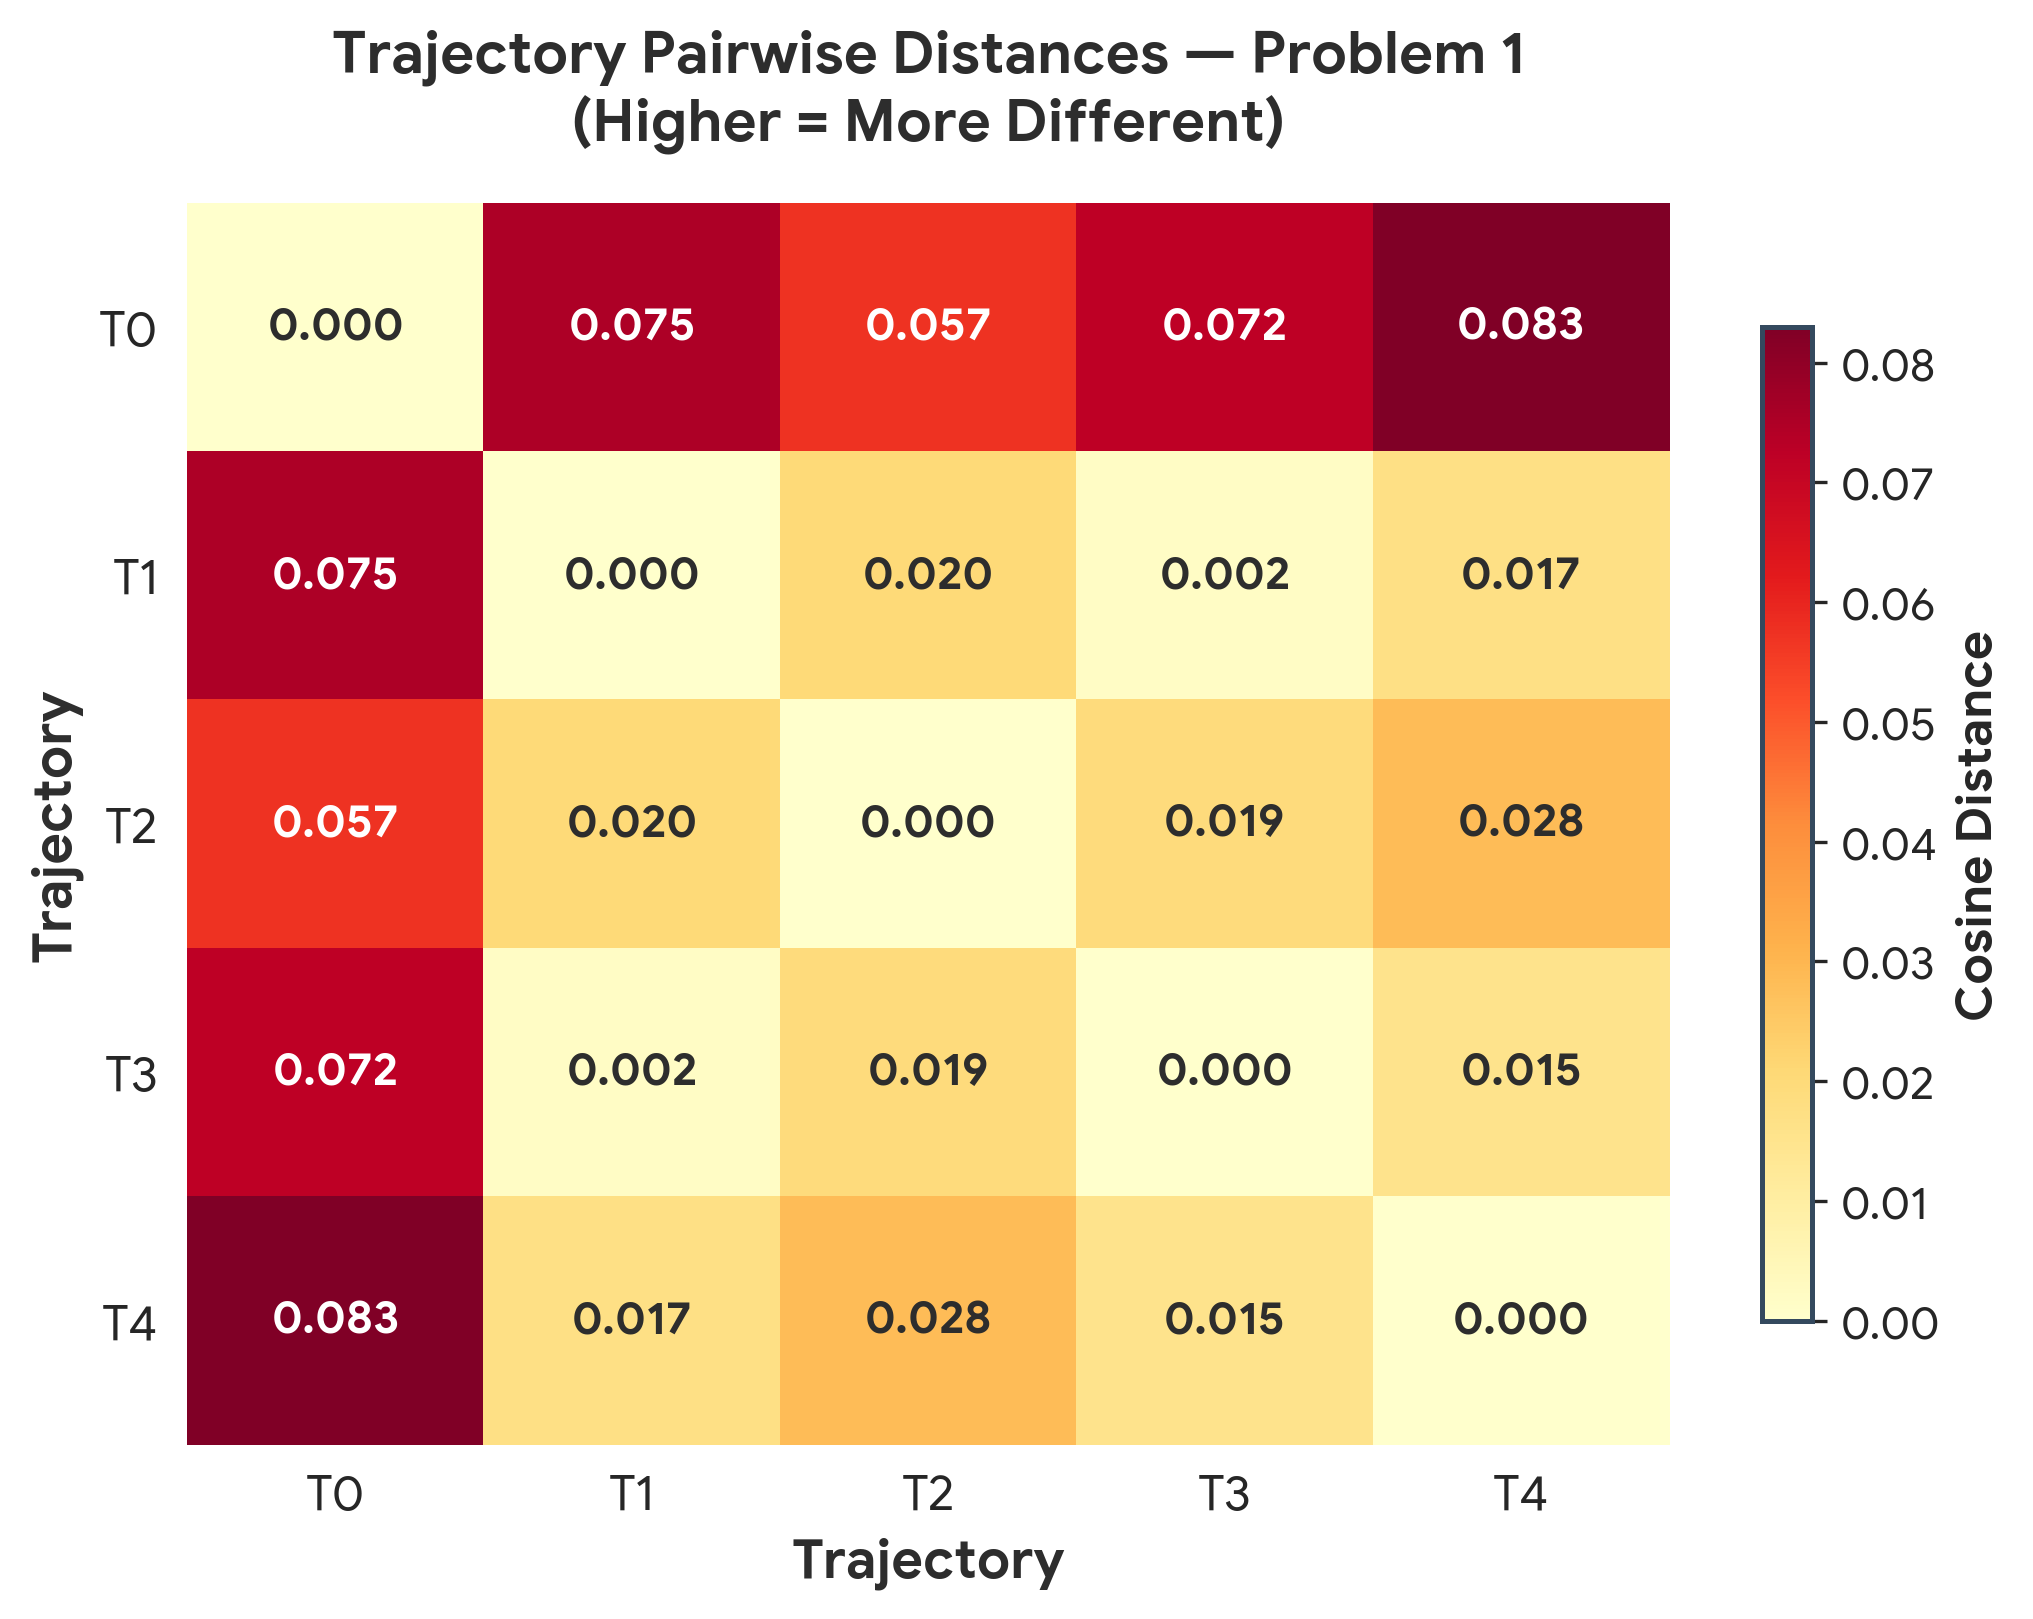


──────────────────────────────────────────────────────────────────────
  Trajectory Contents — Problem 1
──────────────────────────────────────────────────────────────────────

  T0 (4 steps):
  ──────────────────────────────────────────────────
    Step 1: Calculate the total number of eggs Janet has after her ducks lay eggs: 16 eggs per day.
    Step 2: Determine how many eggs Janet consumes for breakfast and in muffins: 3 eggs for breakfast + 4 eggs for muffins = 7 eggs consumed daily.
    Step 3: Find out how many eggs are left for sale at the farmers' market: 16 eggs - 7 eggs = 9 eggs remaining.
    Step 4: Calculate the total revenue from selling the remaining eggs at the farmers' market: 9 eggs * $2 per egg = $18.

  T1 (4 steps):
  ──────────────────────────────────────────────────
    Step 1: Janet's ducks lay a total of 16 eggs per day.
    Step 2: Janet eats 3 eggs for breakfast each morning. Therefore, the number of eggs she has left after breakfast is 16 - 3 = 13 eggs.
  

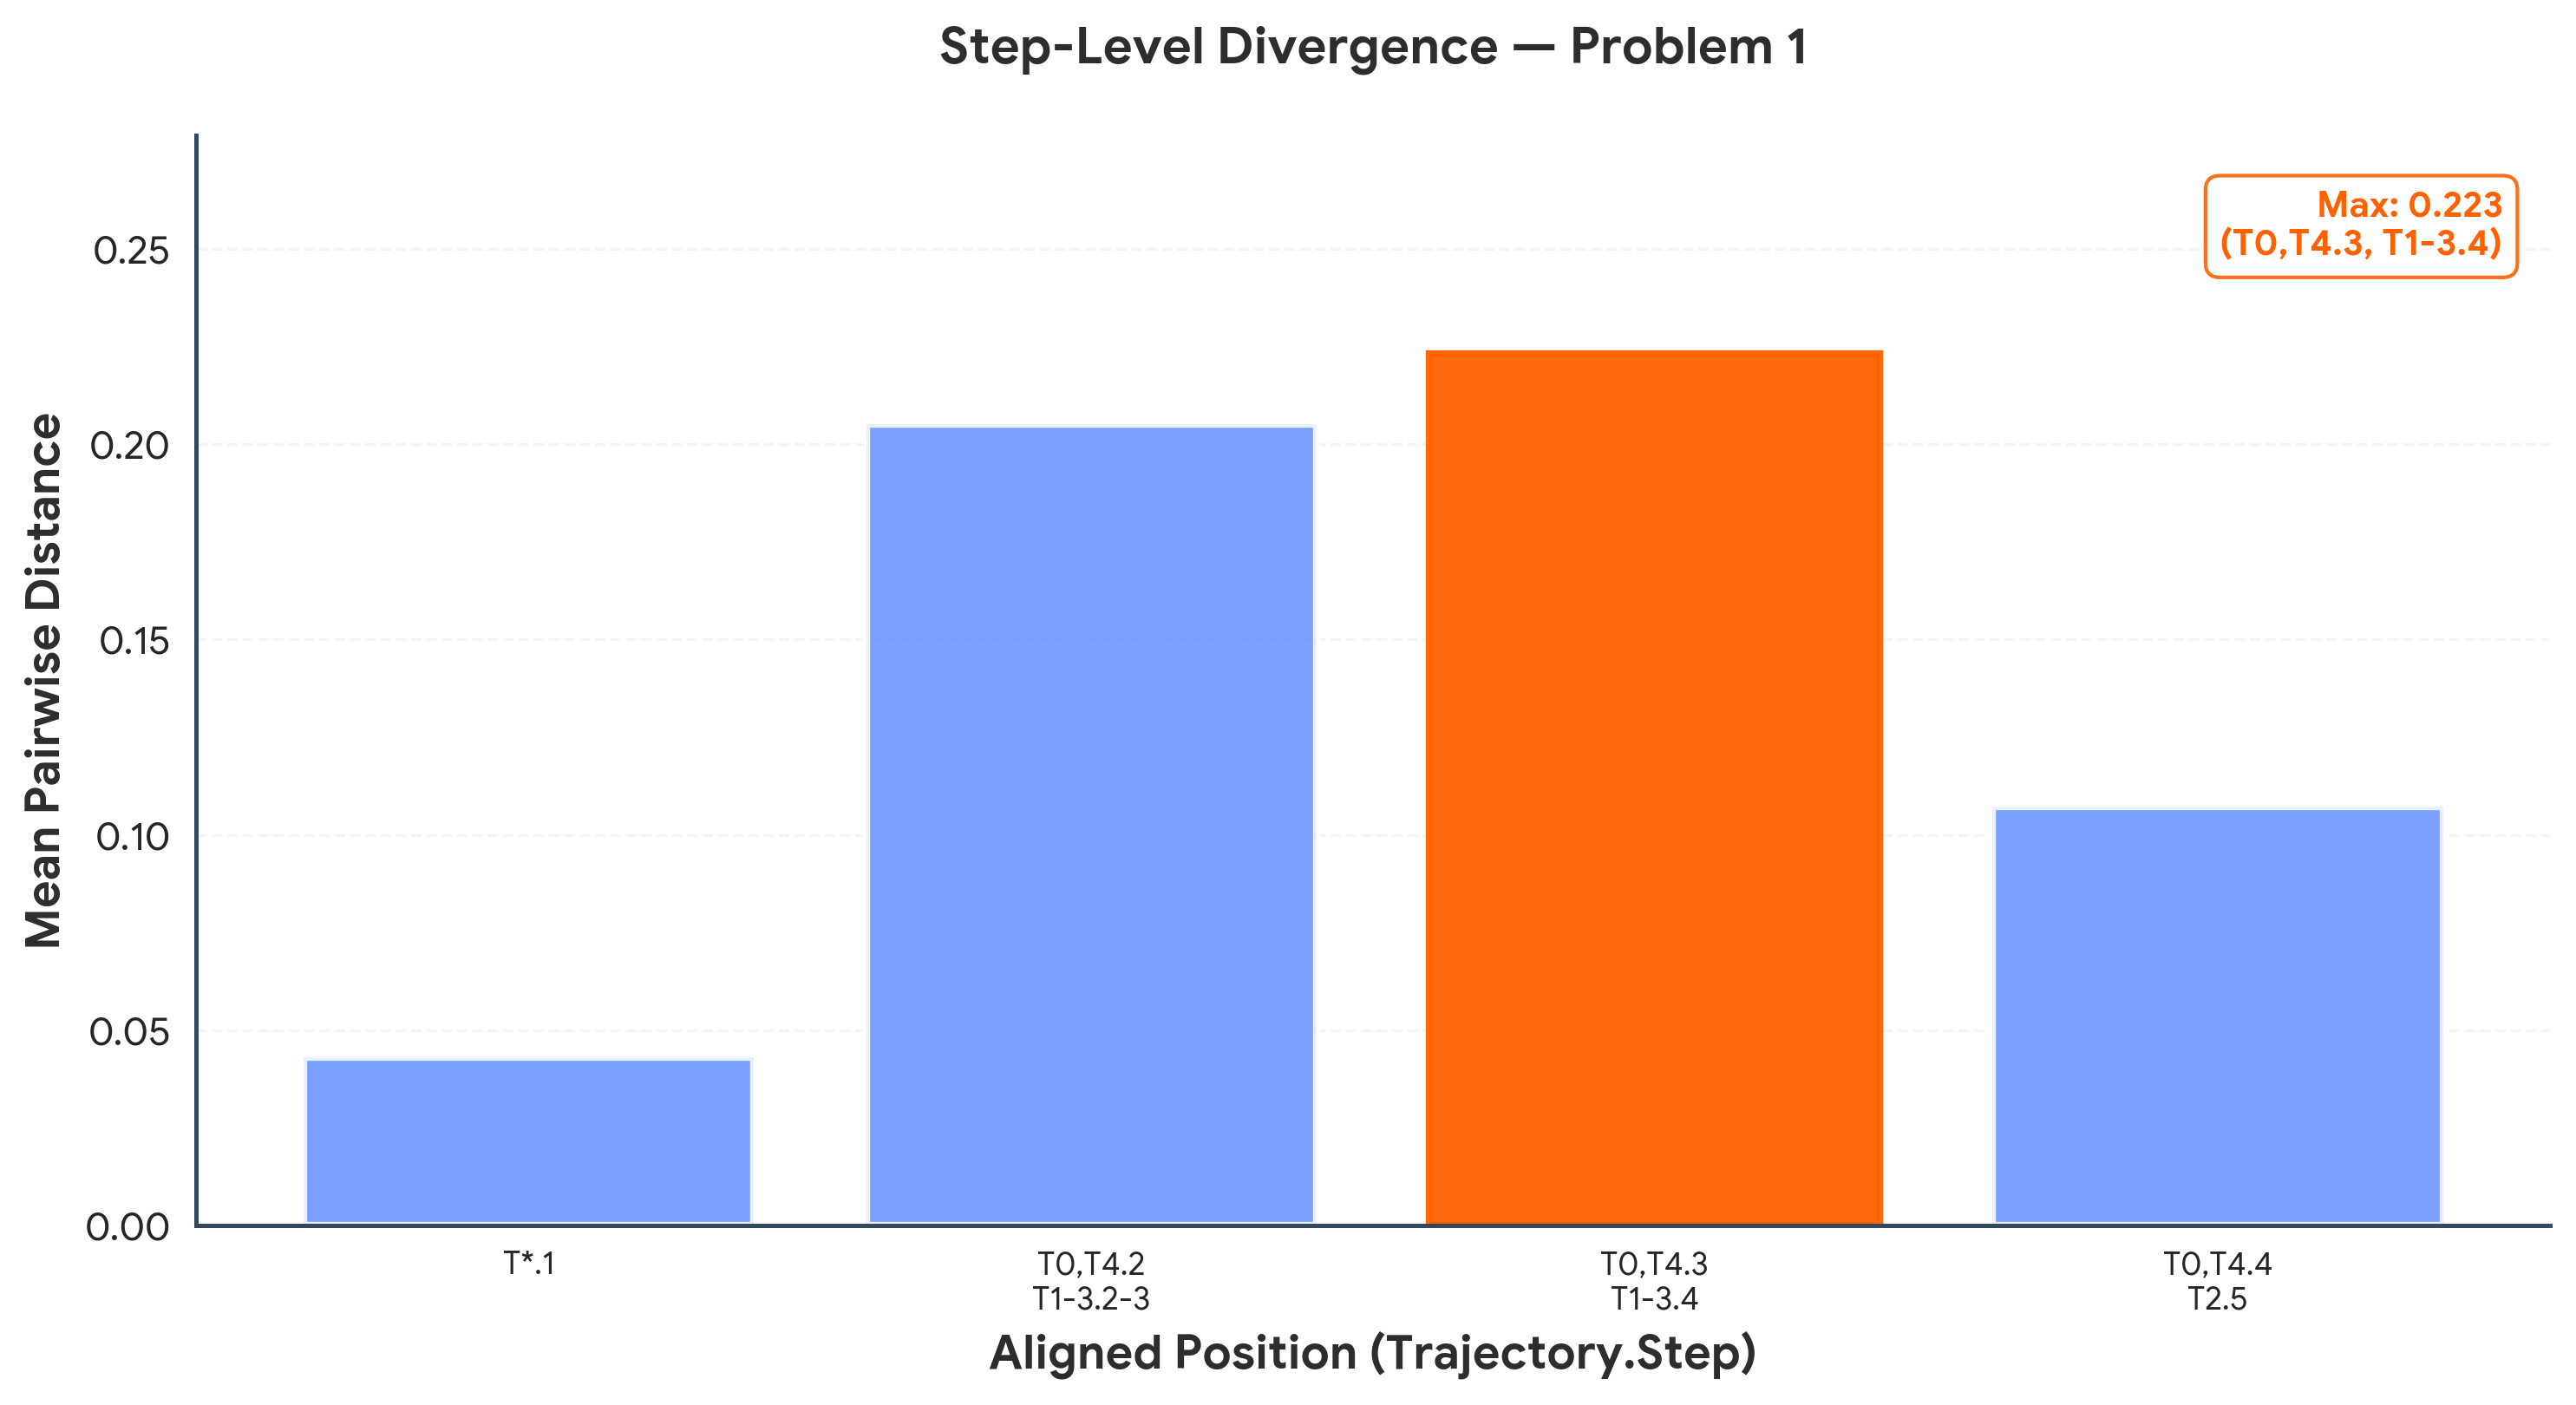


──────────────────────────────────────────────────────────────────────
  DTW-Aligned Step Details — Problem 1
──────────────────────────────────────────────────────────────────────

  Position 1 | Mean Distance: 0.0431
  ──────────────────────────────────────────────────
    T0.1: Calculate the total number of eggs Janet has after her ducks lay eggs: 16 eggs per day.
    T1.1: Janet's ducks lay a total of 16 eggs per day.
    T2.1: Janet's ducks lay a total of 16 eggs per day.
    T3.1: Janet's ducks lay a total of 16 eggs per day.
    T4.1: Janet's ducks lay a total of 16 eggs per day.

  Position 2 | Mean Distance: 0.2050
  ──────────────────────────────────────────────────
    T0.2: Determine how many eggs Janet consumes for breakfast and in muffins: 3 eggs for breakfast + 4 eggs for muffins = 7 eggs consumed daily.
    T1.2: Janet eats 3 eggs for breakfast each morning. Therefore, the number of eggs she has left after breakfast is 16 - 3 = 13 eggs.
    T1.3: Janet bakes muffins us

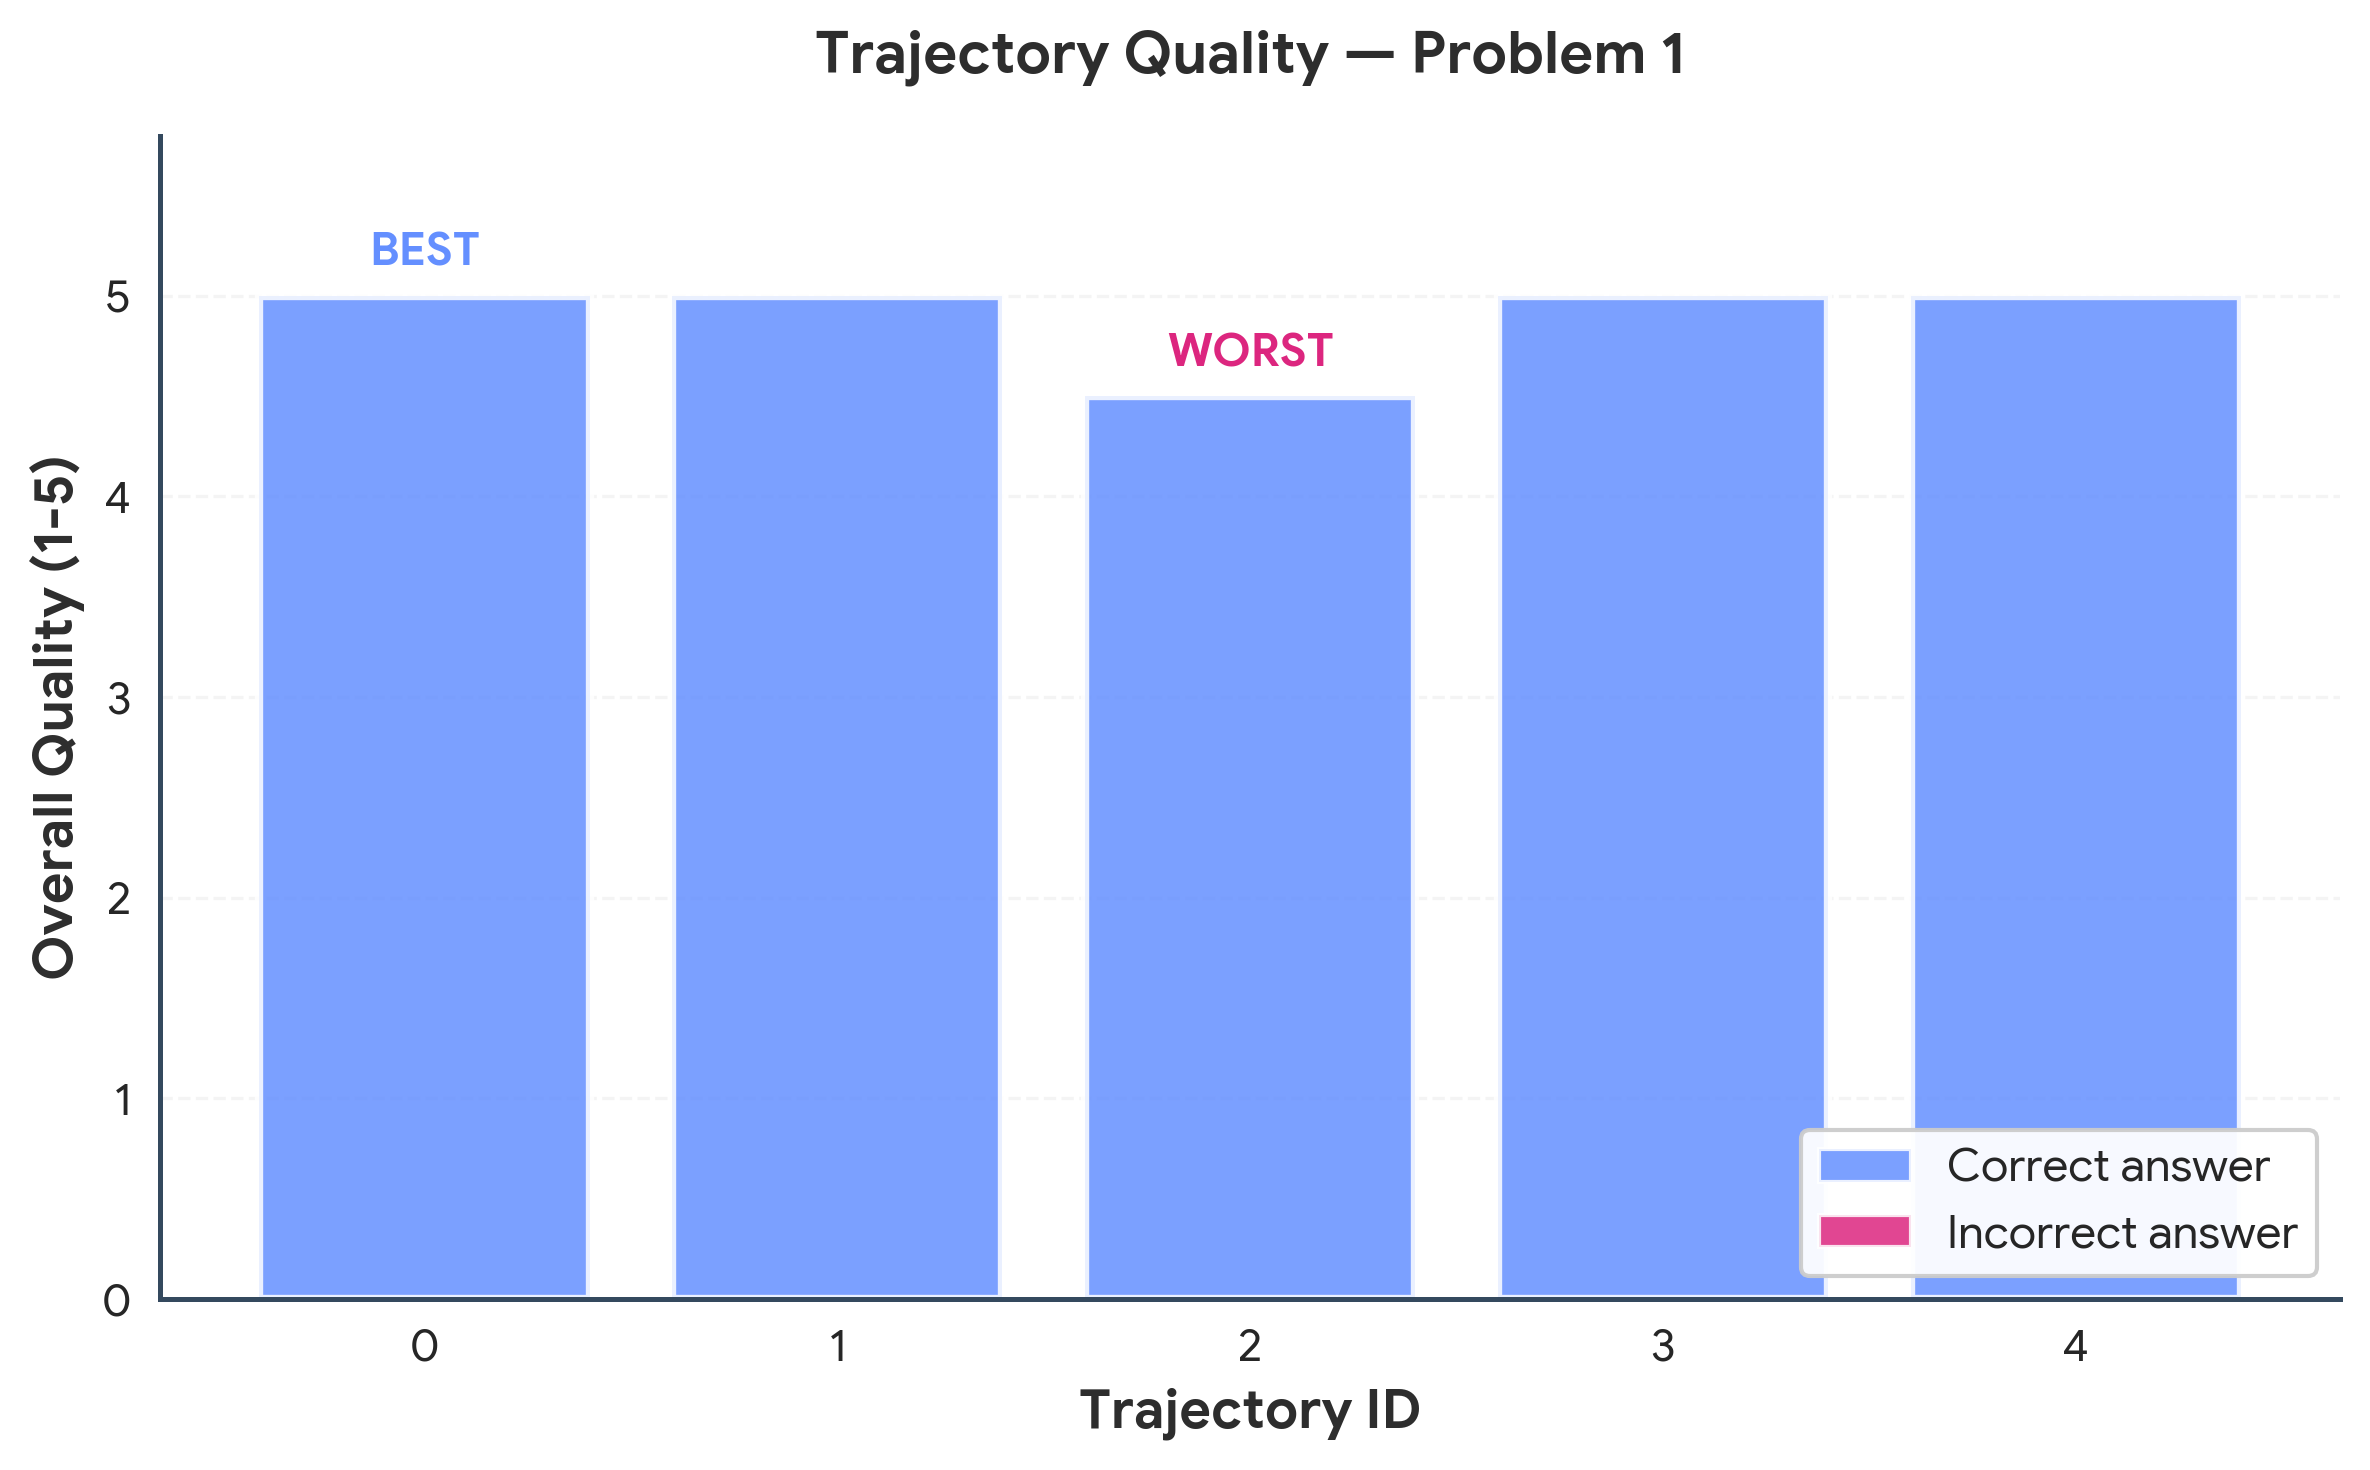


  Problem 2 Visualizations



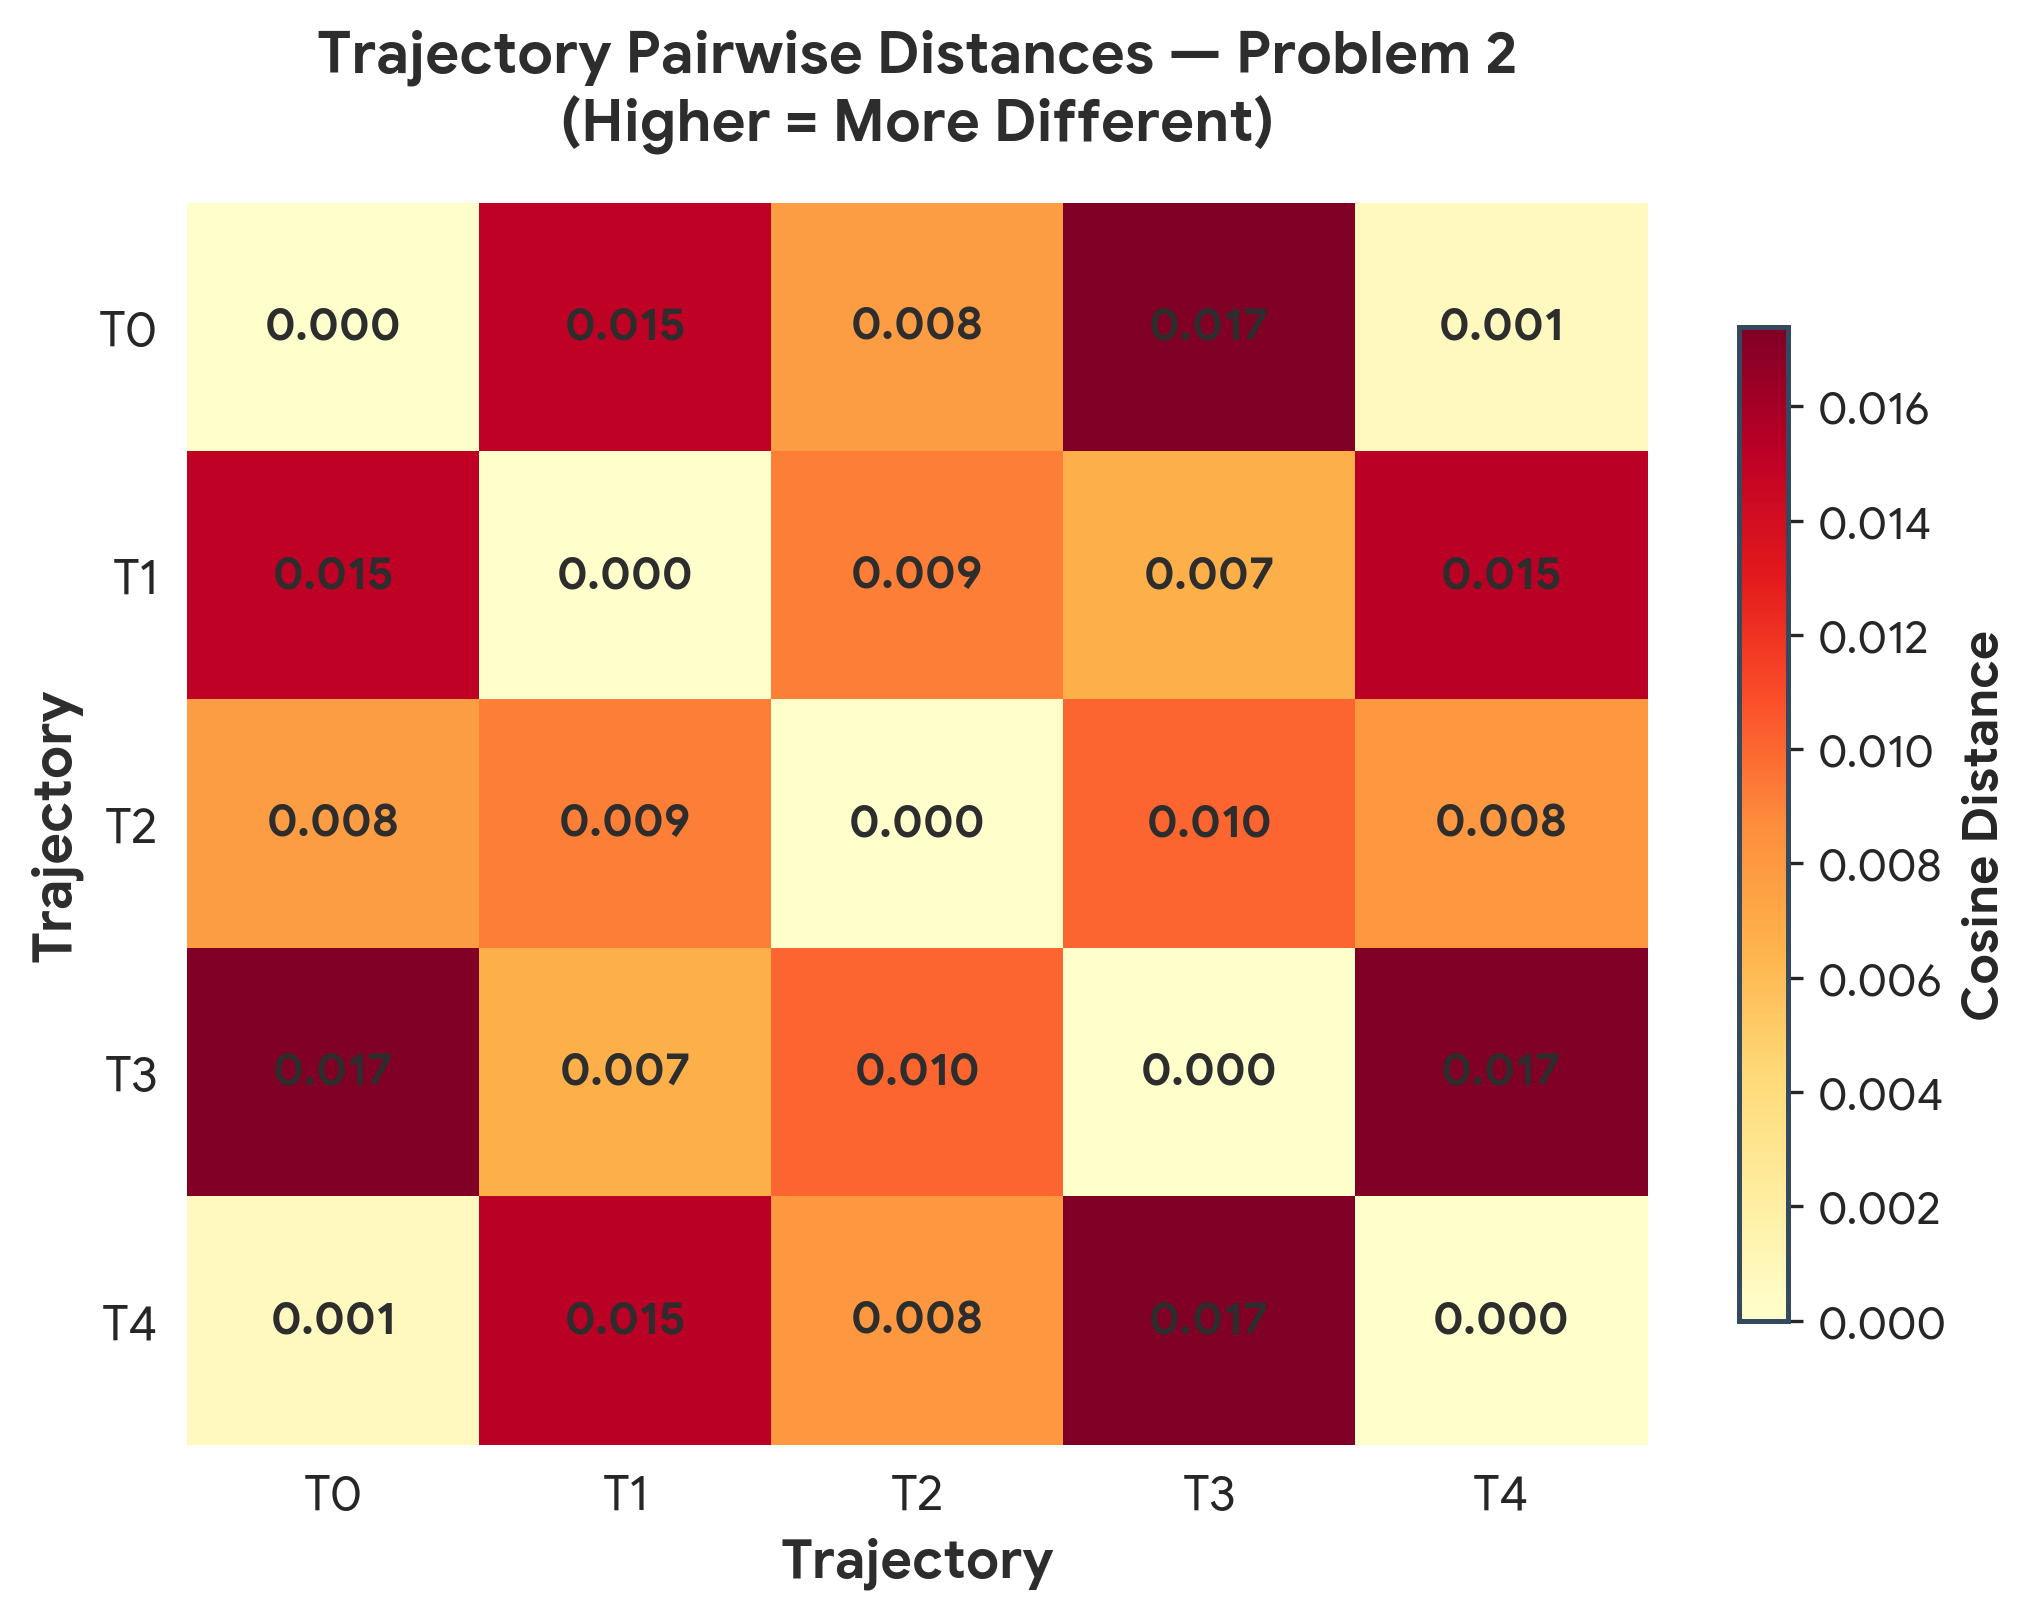


──────────────────────────────────────────────────────────────────────
  Trajectory Contents — Problem 2
──────────────────────────────────────────────────────────────────────

  T0 (3 steps):
  ──────────────────────────────────────────────────
    Step 1: Identify the amount of blue fiber needed for the robe, which is 2 bolts.
    Step 2: Calculate the amount of white fiber needed, which is half of the blue fiber: 2 bolts / 2 = 1 bolt.
    Step 3: Add the amount of blue fiber and white fiber together to find the total: 2 bolts (blue) + 1 bolt (white) = 3 bolts.

  T1 (3 steps):
  ──────────────────────────────────────────────────
    Step 1: Identify the amount of blue fiber needed for the robe, which is given as 2 bolts.
    Step 2: Determine the amount of white fiber needed for the robe, which is half of the blue fiber. Therefore, it requires 2 bolts of blue fiber / 2 = 1 bolt of white fiber.
    Step 3: Calculate the total amount of fiber needed by adding the bolts of blue and wh

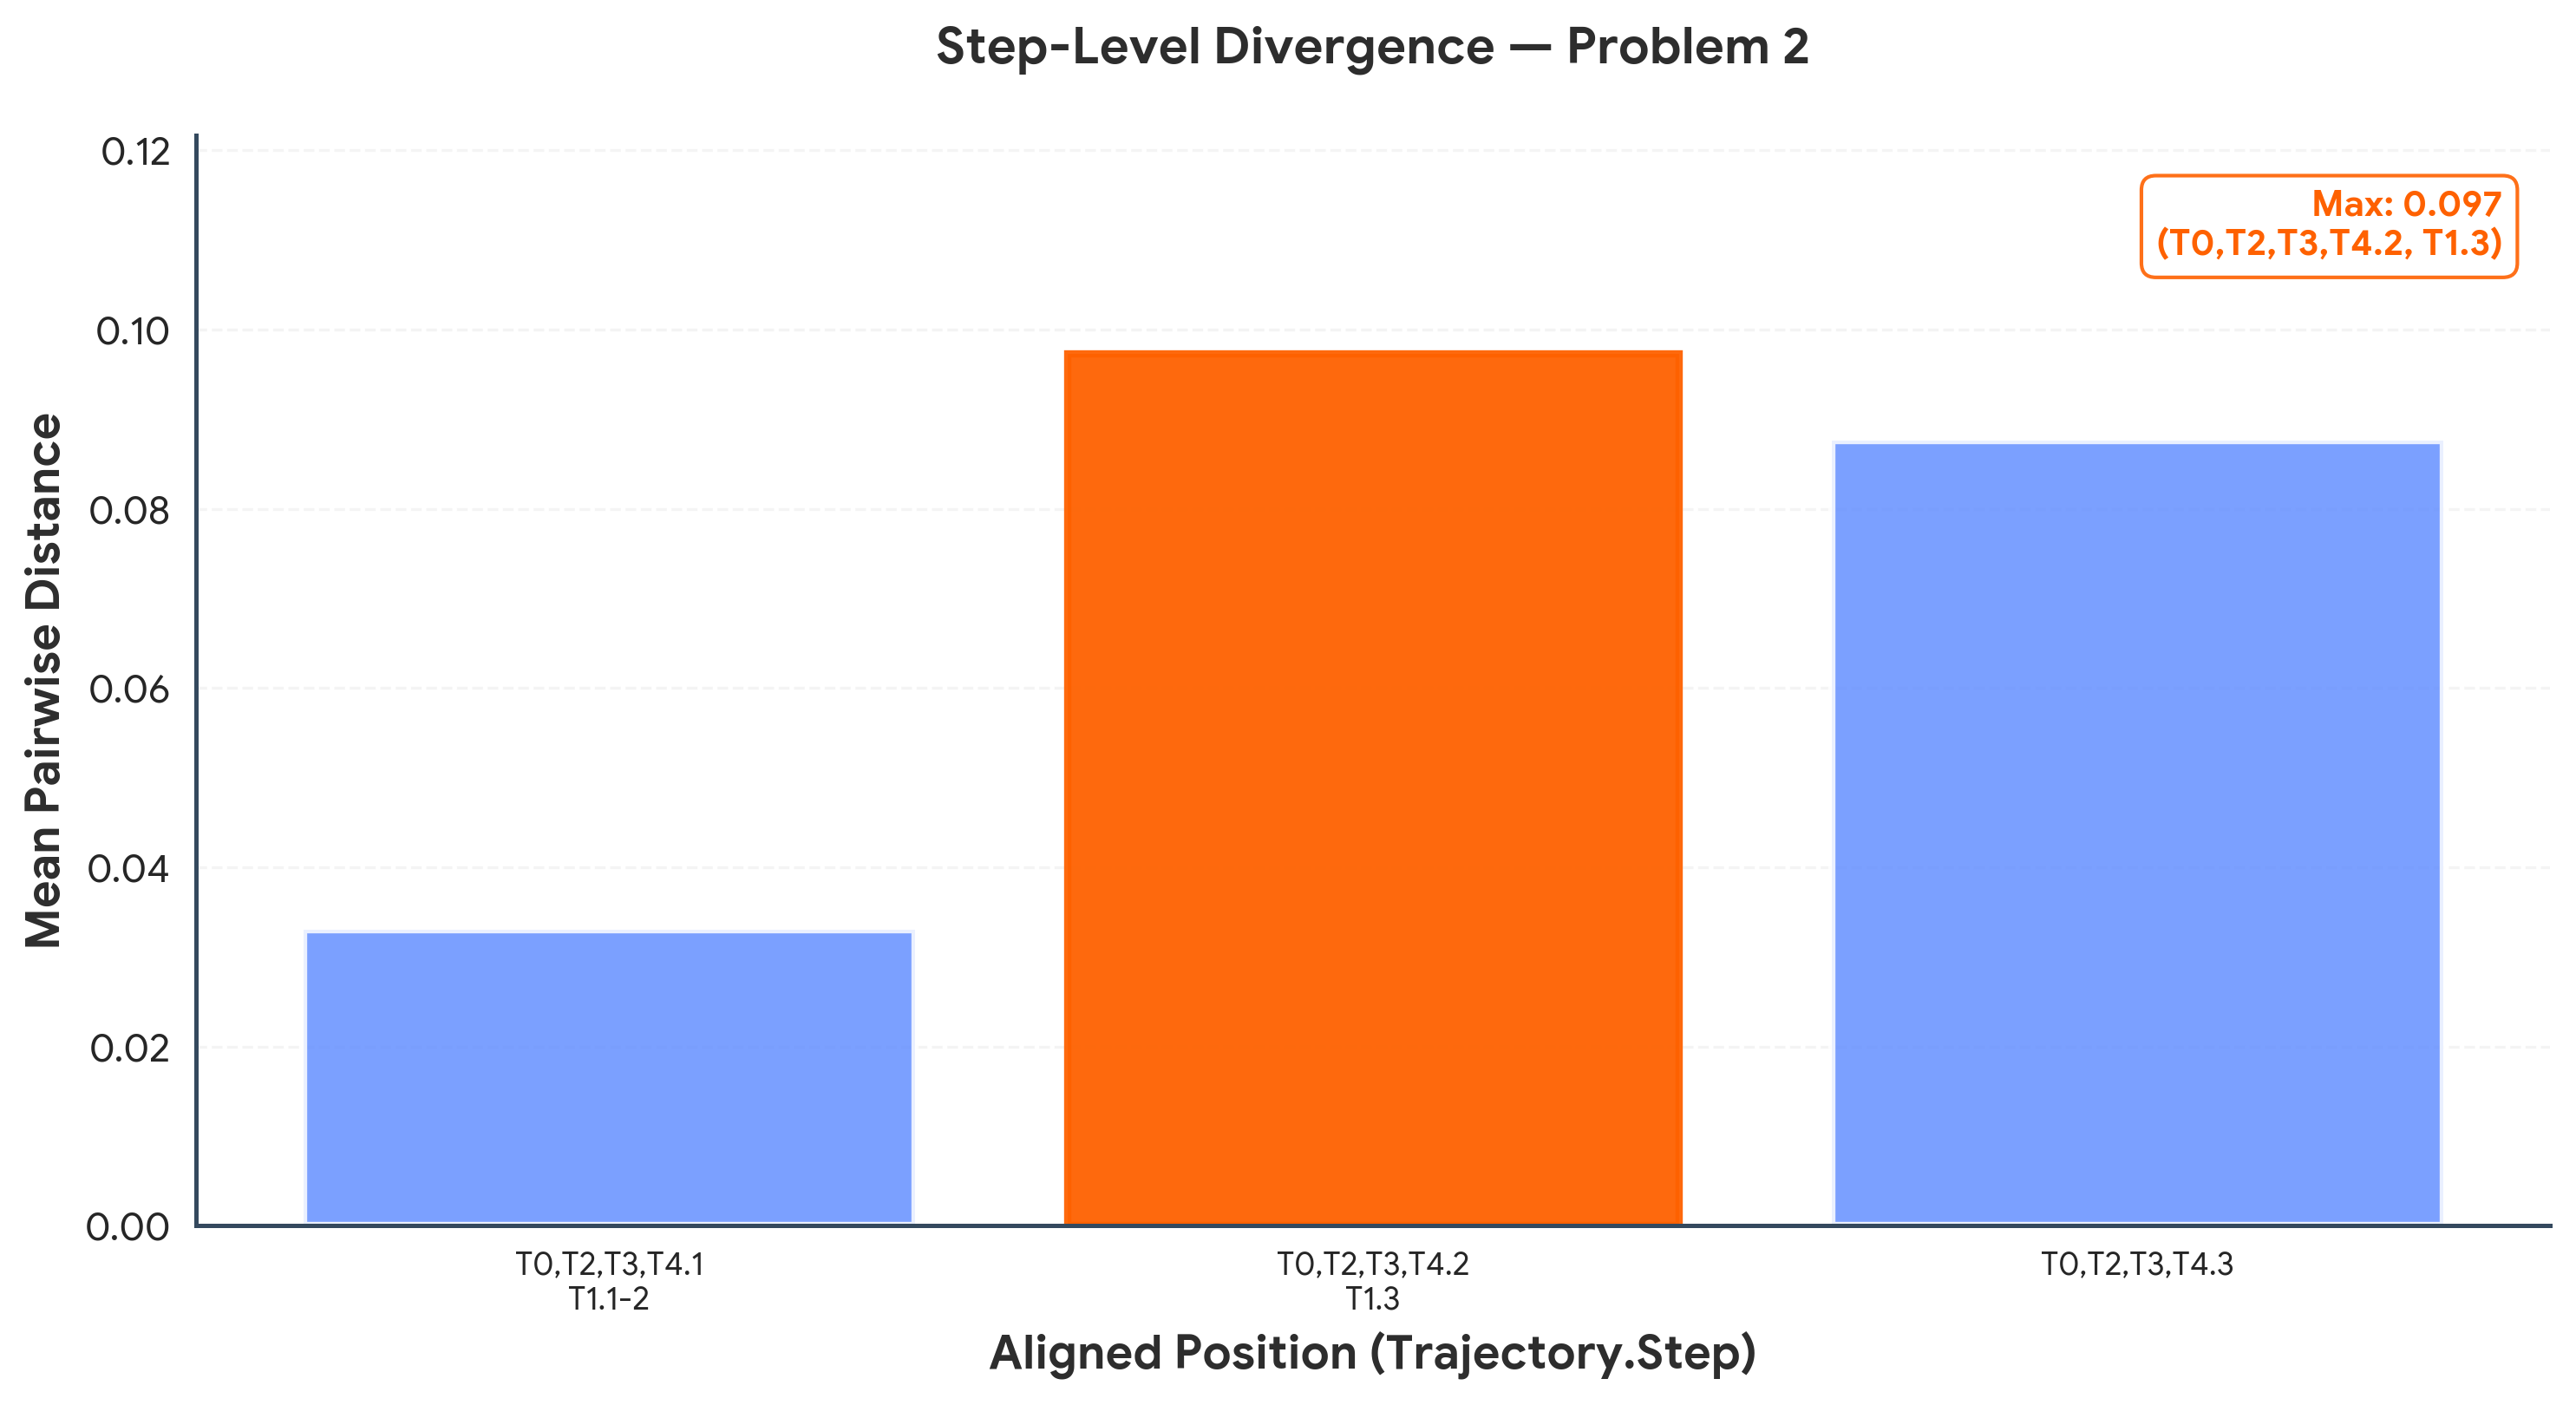


──────────────────────────────────────────────────────────────────────
  DTW-Aligned Step Details — Problem 2
──────────────────────────────────────────────────────────────────────

  Position 1 | Mean Distance: 0.0331
  ──────────────────────────────────────────────────
    T0.1: Identify the amount of blue fiber needed for the robe, which is 2 bolts.
    T1.1: Identify the amount of blue fiber needed for the robe, which is given as 2 bolts.
    T1.2: Determine the amount of white fiber needed for the robe, which is half of the blue fiber. Therefore, it requires 2 bolts of blue fiber / 2 = 1 bolt of white fiber.
    T2.1: Identify the amount of blue fiber needed for the robe, which is given as 2 bolts.
    T3.1: Identify the amount of blue fiber needed for the robe, which is given as 2 bolts.
    T4.1: Identify the amount of blue fiber needed for the robe, which is 2 bolts.

  Position 2 | Mean Distance: 0.0973
  ──────────────────────────────────────────────────
    T0.2: Calculate 

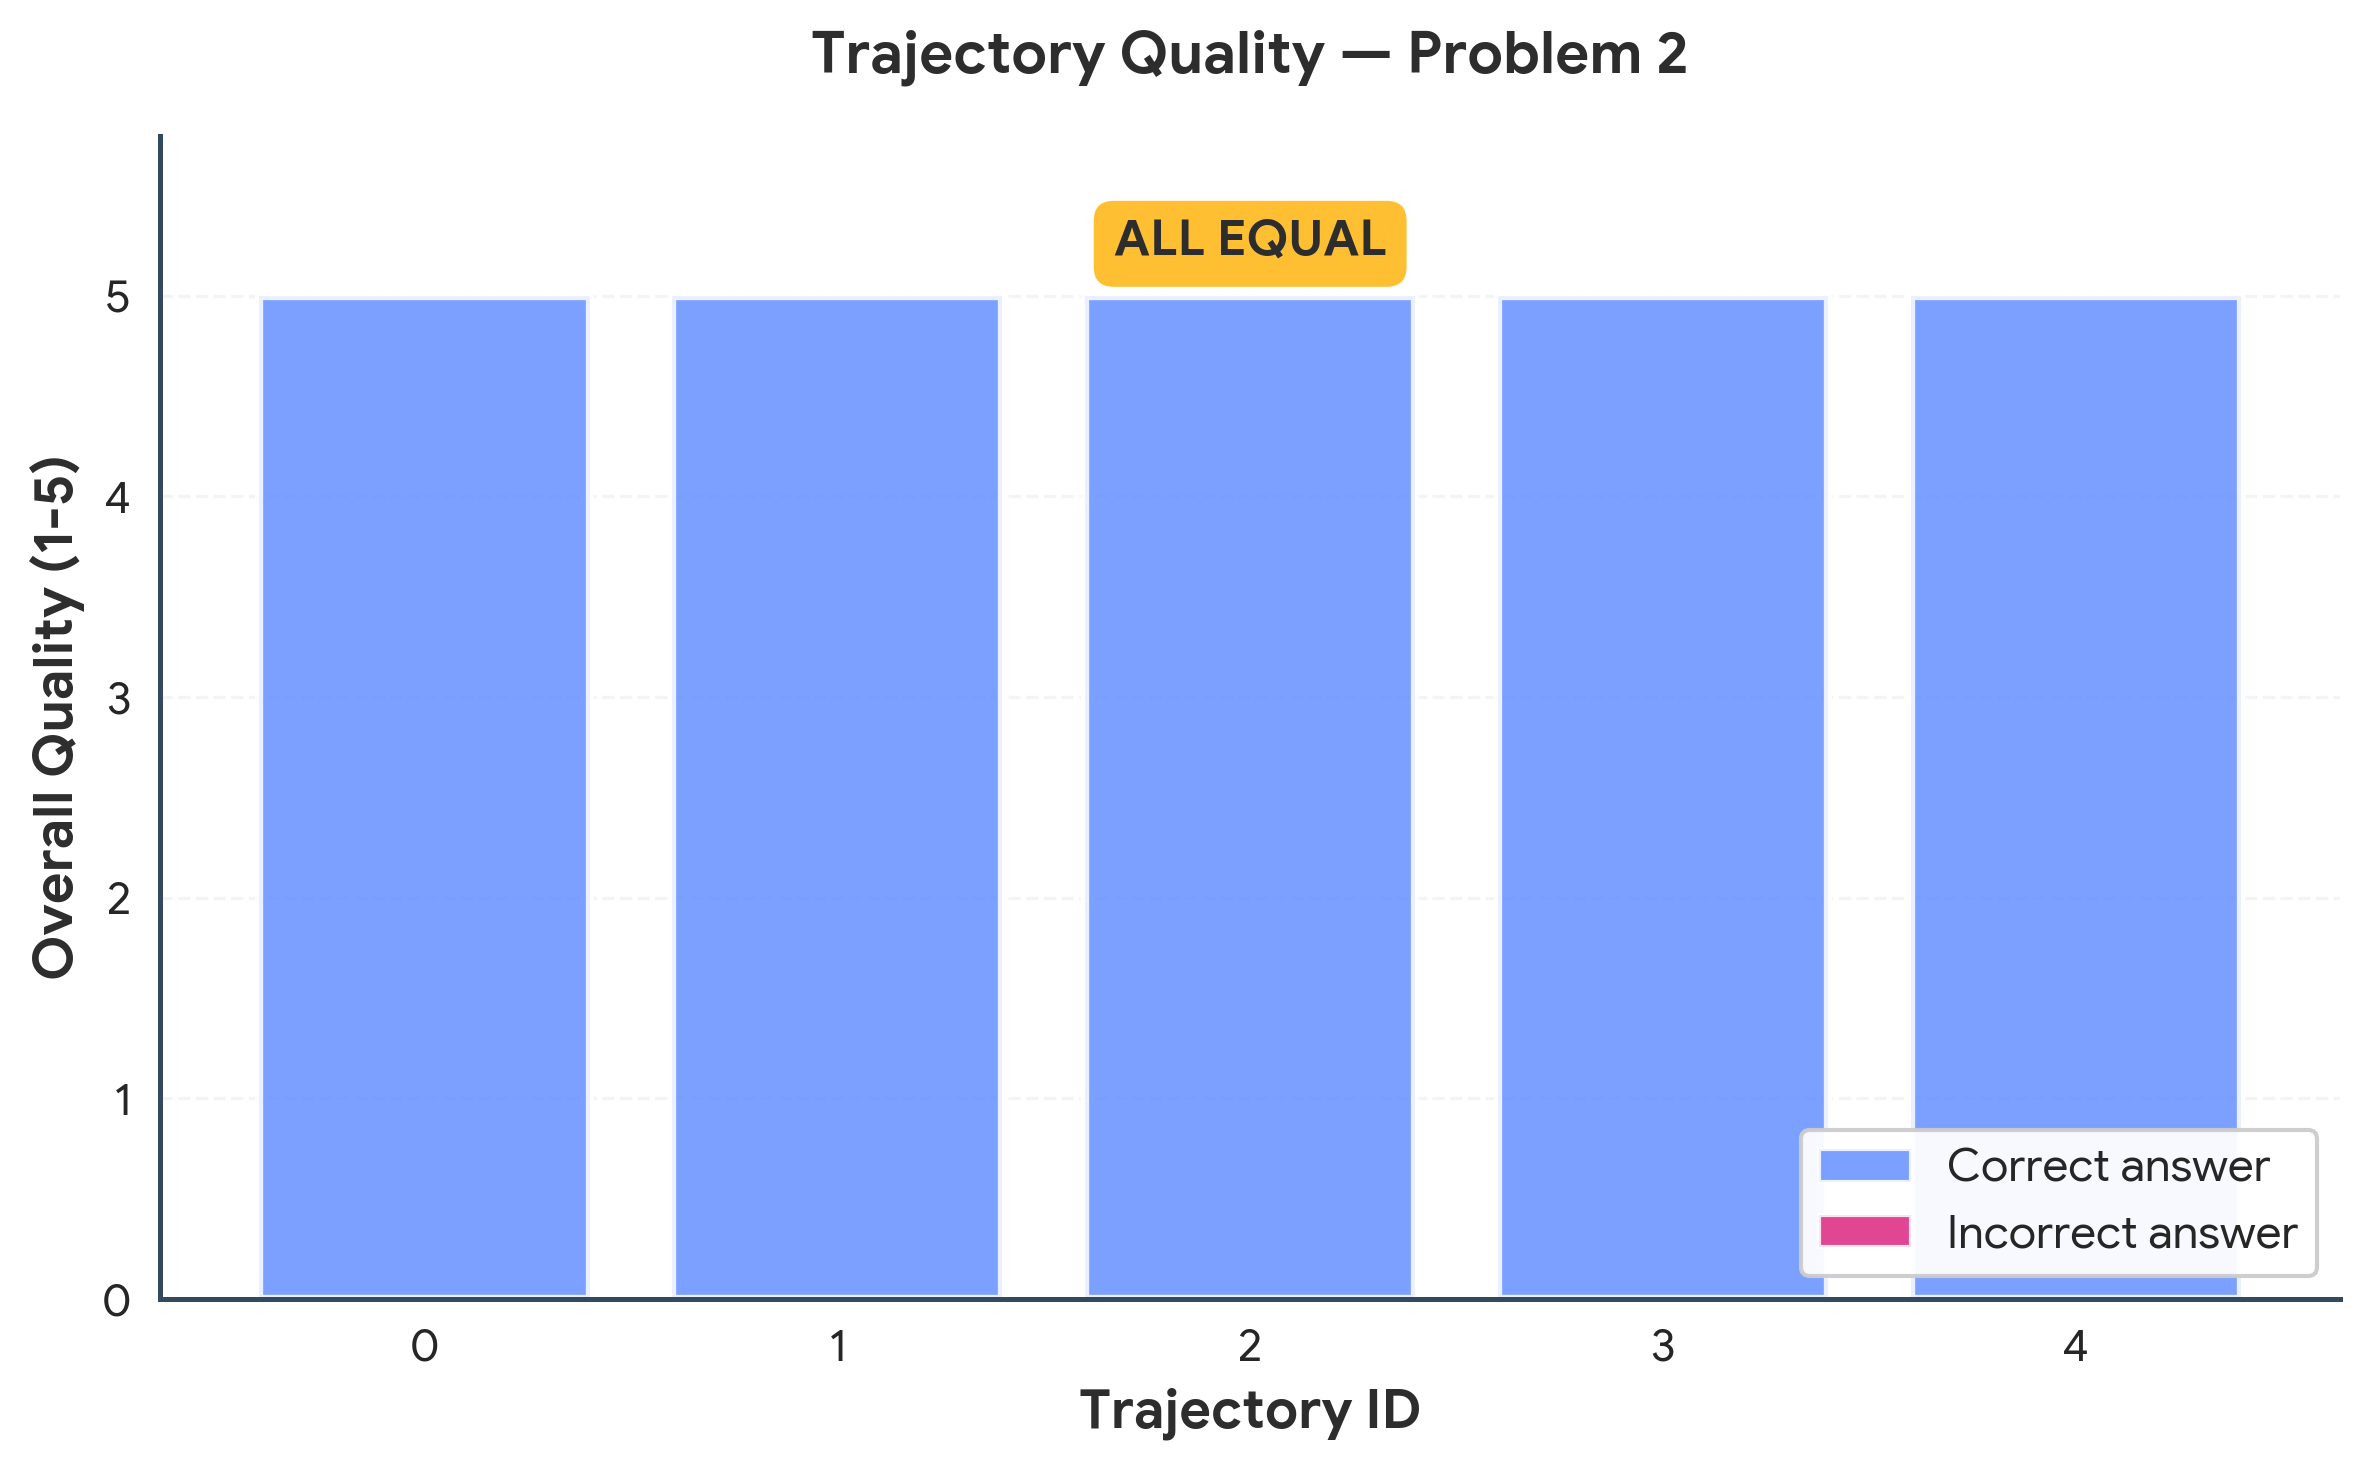


  Problem 3 Visualizations



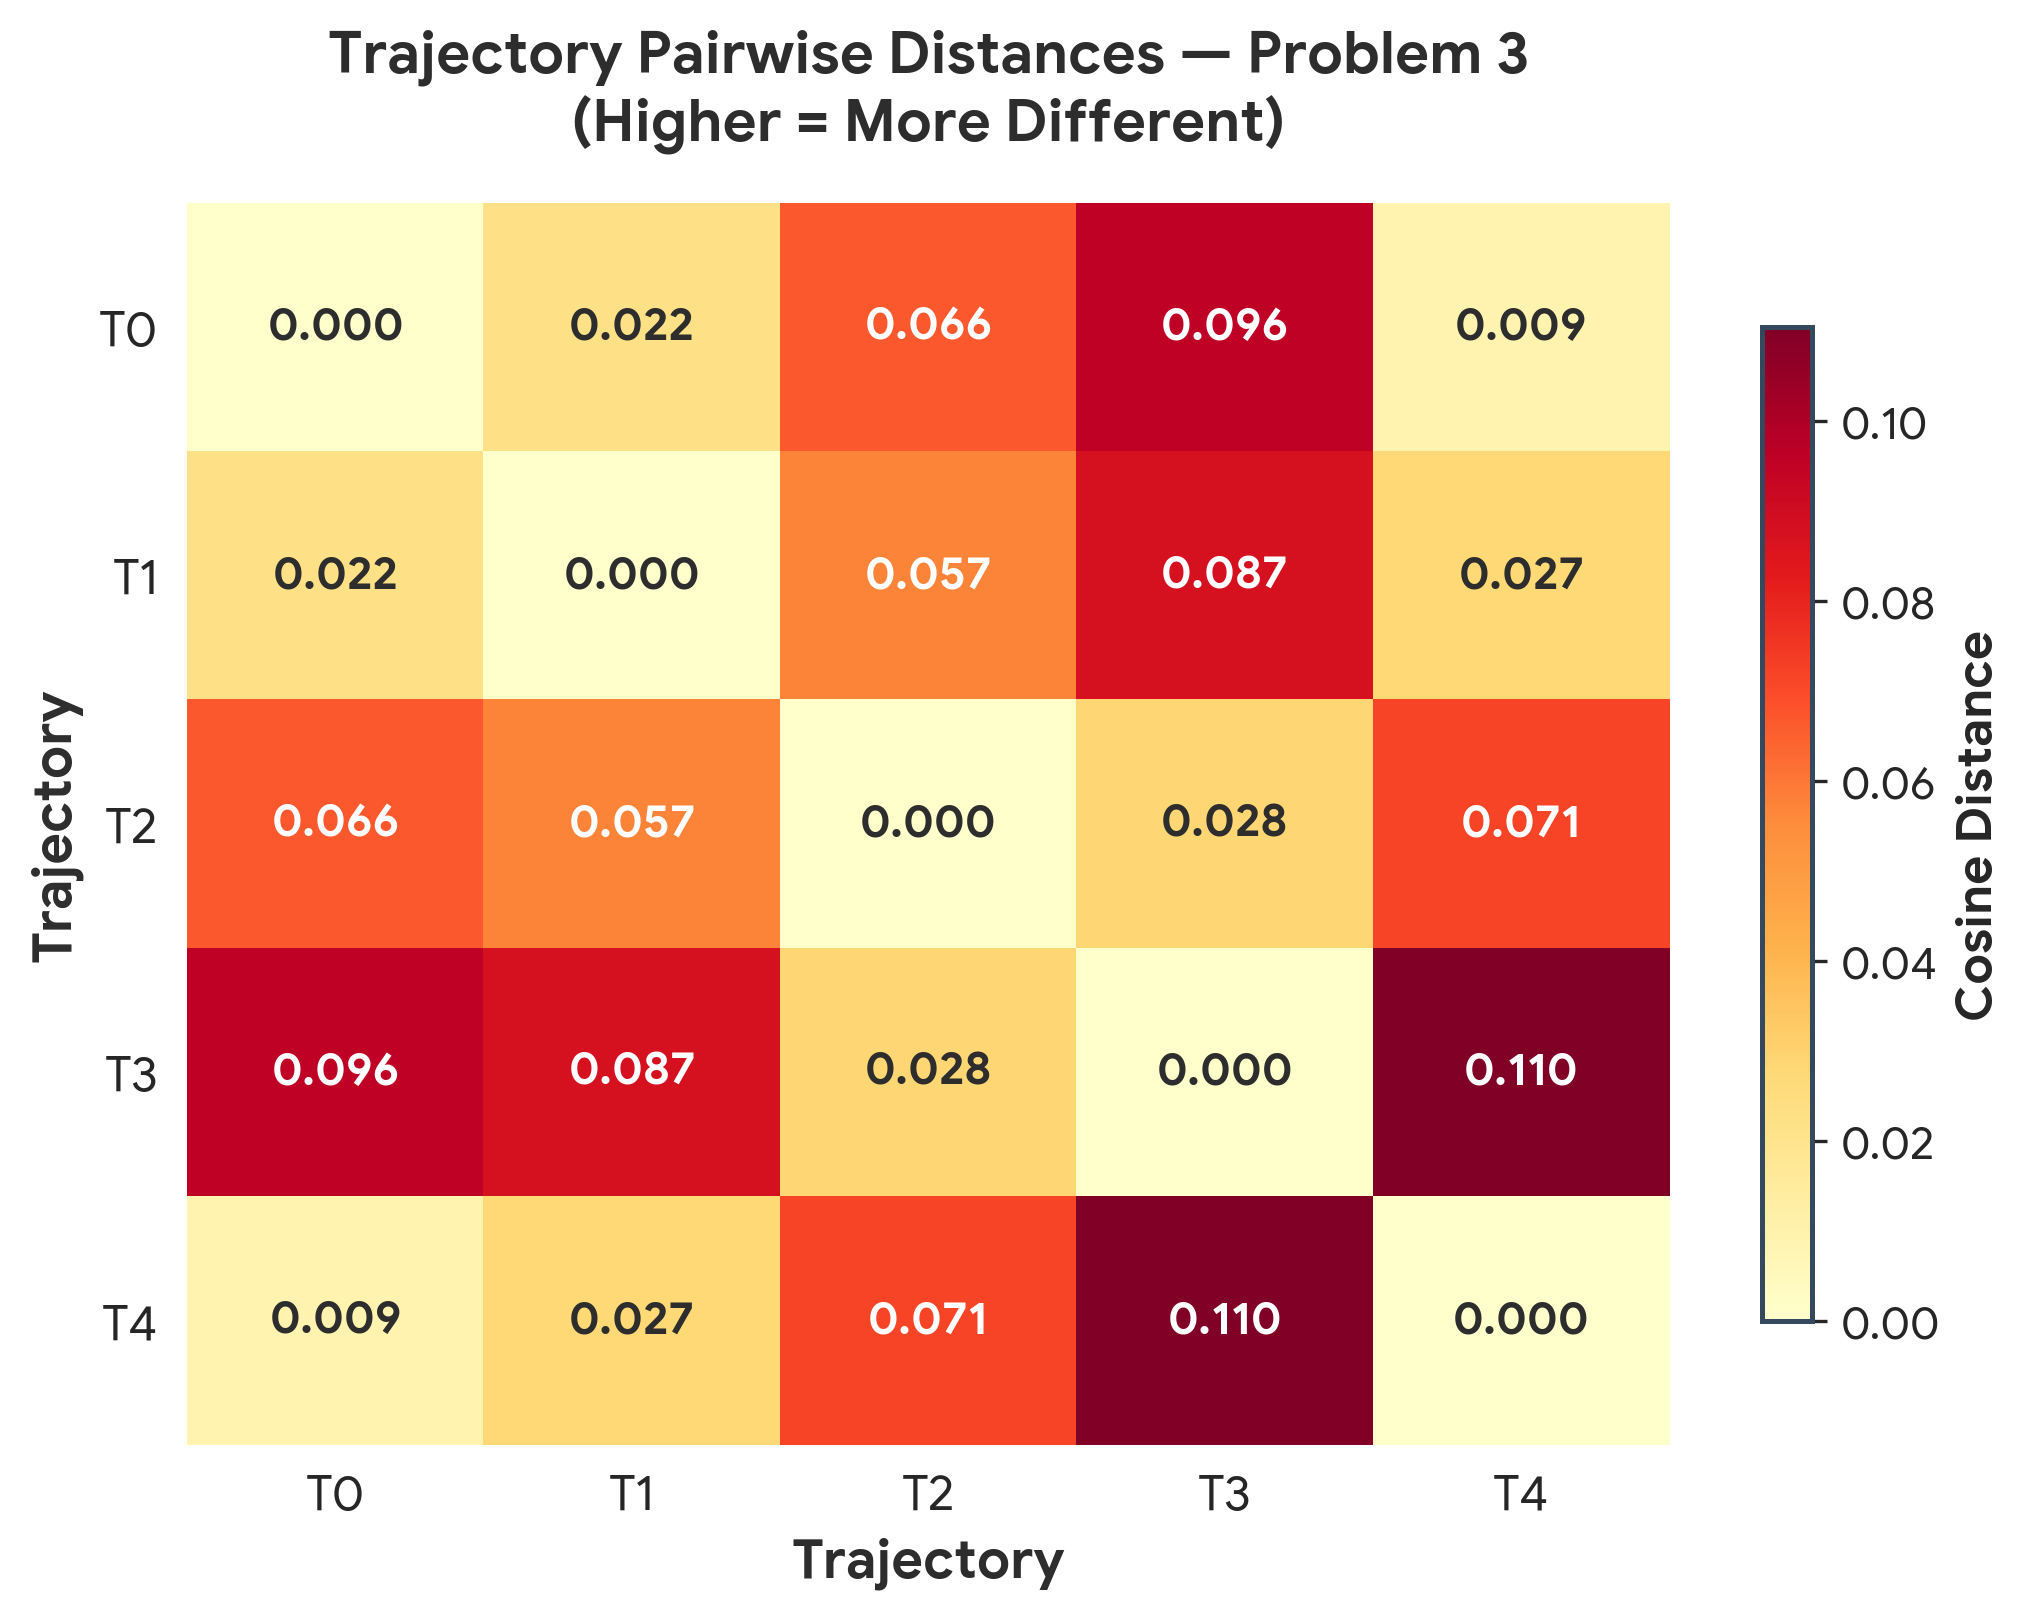


──────────────────────────────────────────────────────────────────────
  Trajectory Contents — Problem 3
──────────────────────────────────────────────────────────────────────

  T0 (3 steps):
  ──────────────────────────────────────────────────
    Step 1: Calculate the total cost Josh incurred for buying and repairing the house. Total cost = Purchase price + Repair costs = $80,000 + $50,000 = $130,000.
    Step 2: Determine the increased value of the house after repairs. Increased value = Original purchase price + (Original purchase price * Percentage increase) = $80,000 + ($80,000 * 150%) = $80,000 + $120,000 = $200,000.
    Step 3: Calculate the profit made by Josh. Profit = Increased value - Total cost = $200,000 - $130,000 = $70,000.

  T1 (4 steps):
  ──────────────────────────────────────────────────
    Step 1: Calculate the total cost Josh incurred when buying and repairing the house. The purchase price is $80,000 and the repair cost is $50,000. Total cost = 80,000 + 50,000 

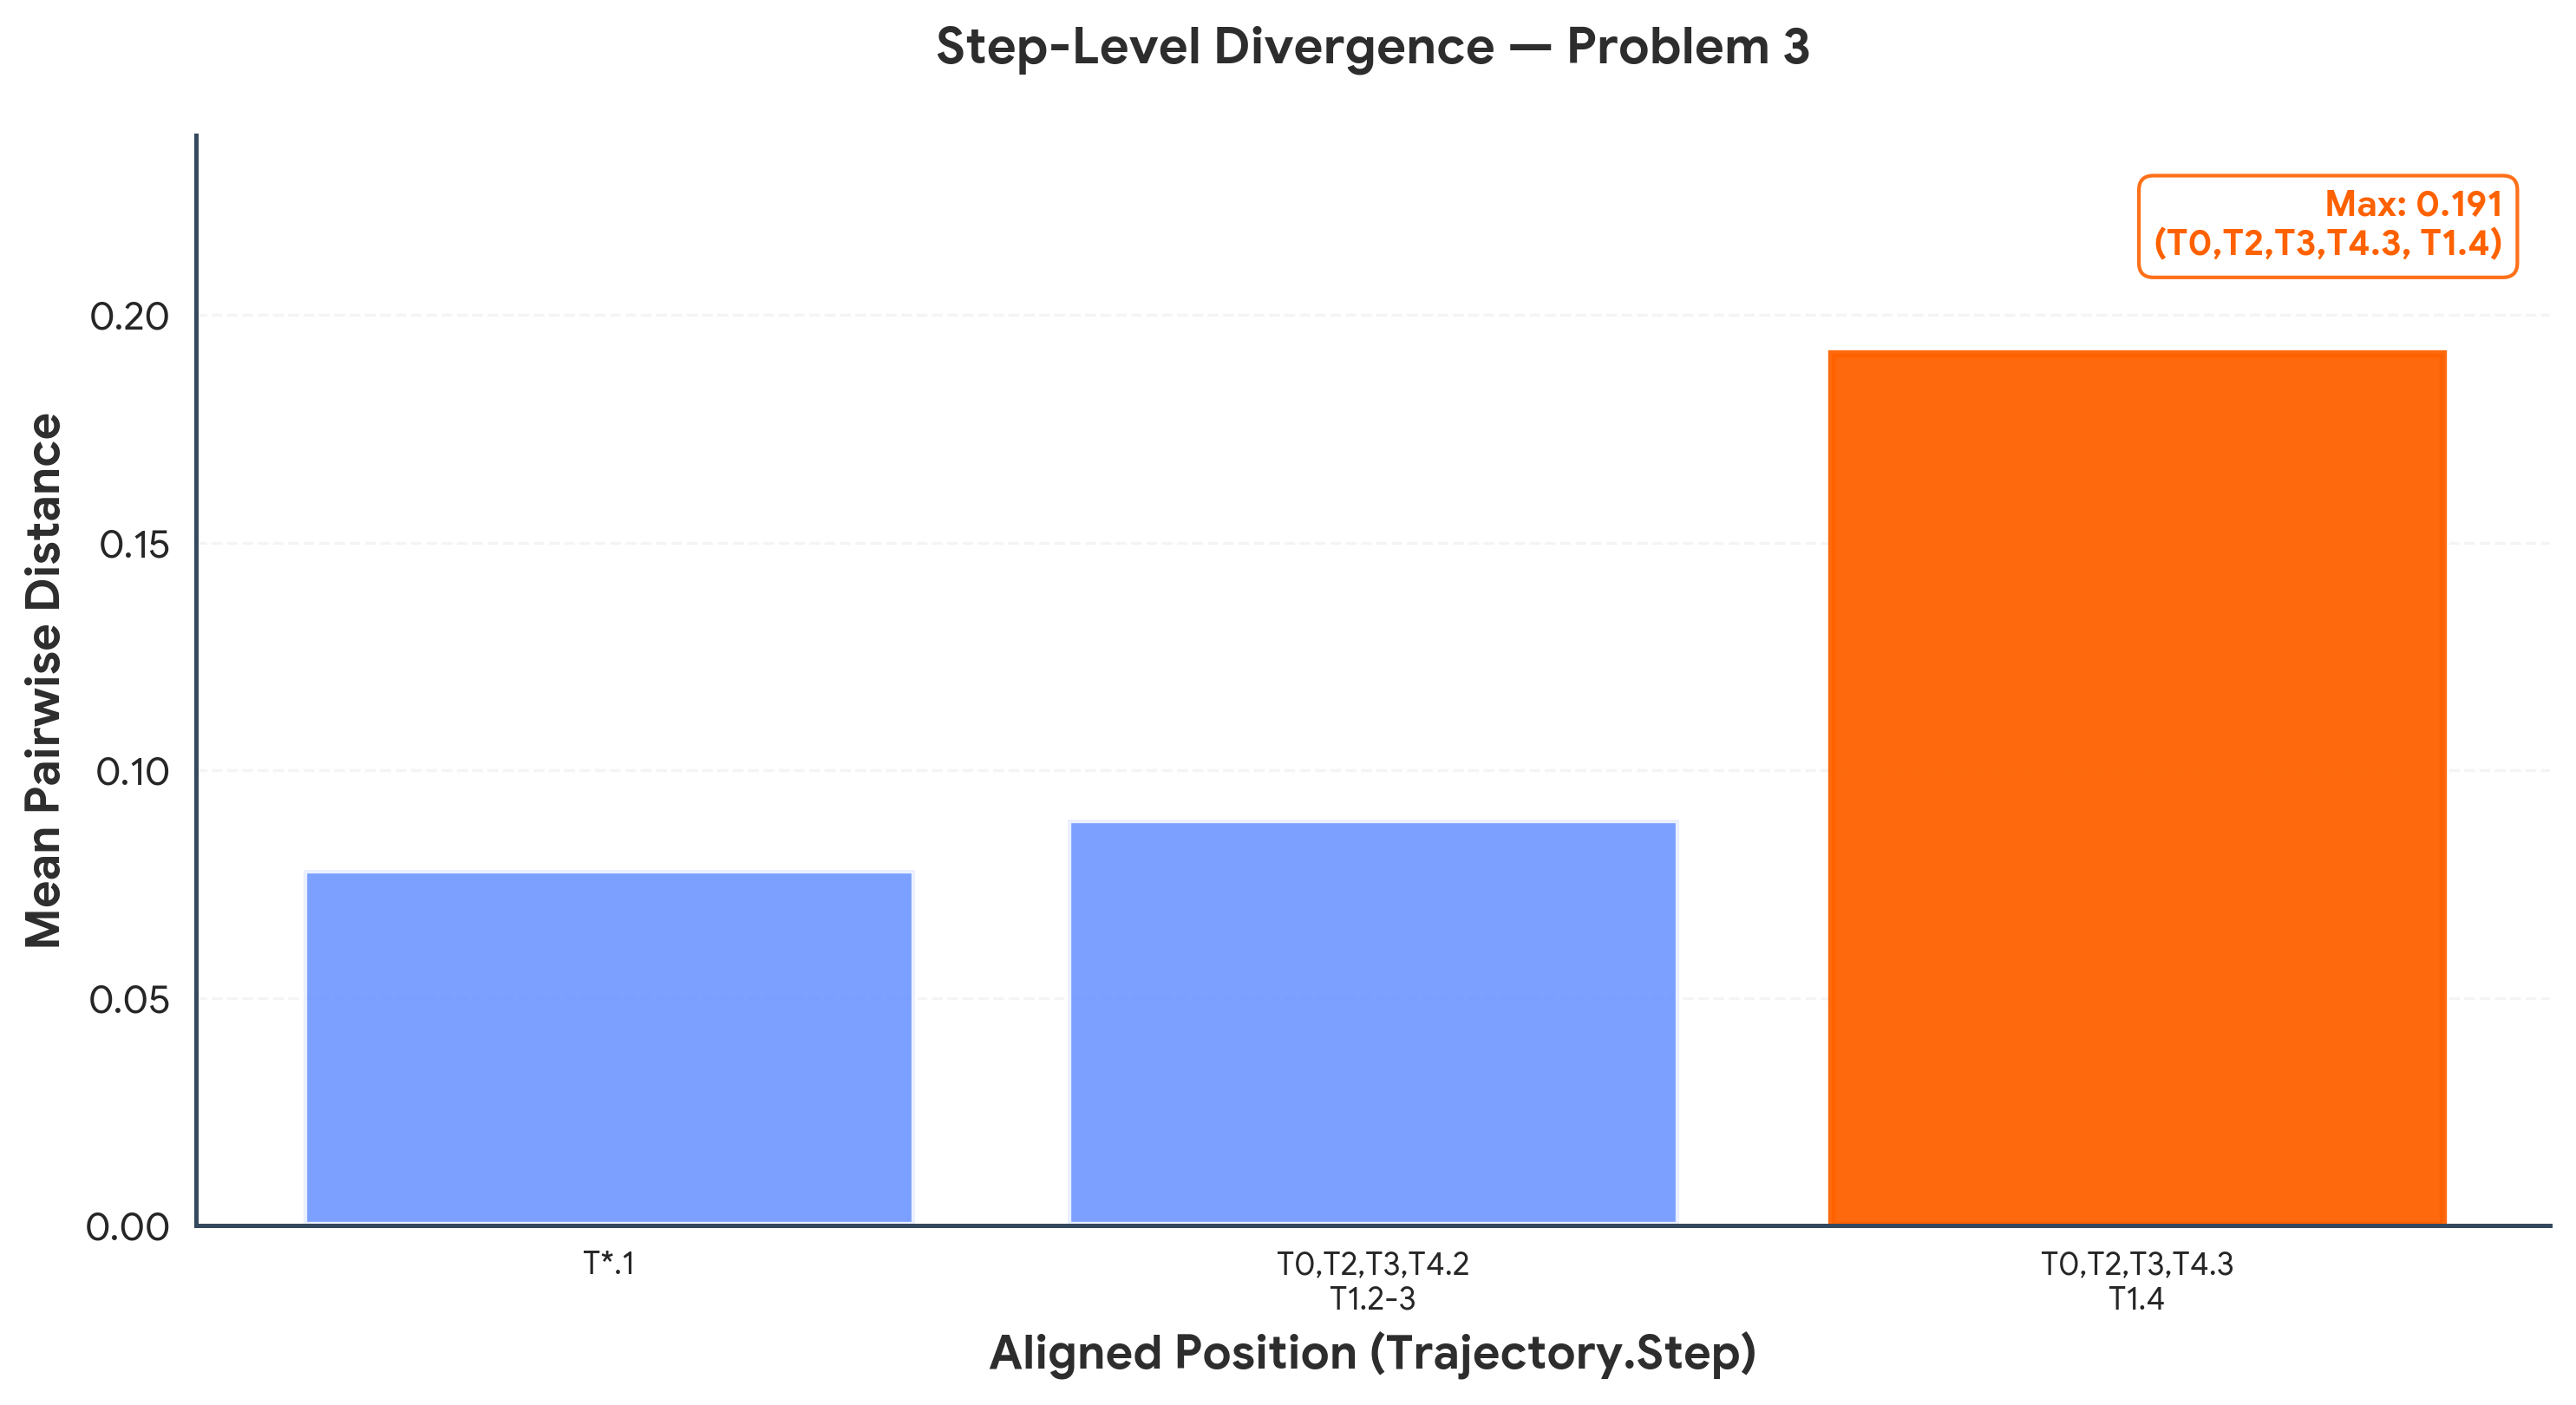


──────────────────────────────────────────────────────────────────────
  DTW-Aligned Step Details — Problem 3
──────────────────────────────────────────────────────────────────────

  Position 1 | Mean Distance: 0.0782
  ──────────────────────────────────────────────────
    T0.1: Calculate the total cost Josh incurred for buying and repairing the house. Total cost = Purchase price + Repair costs = $80,000 + $50,000 = $130,000.
    T1.1: Calculate the total cost Josh incurred when buying and repairing the house. The purchase price is $80,000 and the repair cost is $50,000. Total cost = 80,000 + 50,000 = $130,000.
    T2.1: Calculate the total cost of the house, which includes the purchase price and the repair costs. The purchase price is $80,000 and the repair costs are $50,000. Total cost = $80,000 + $50,000 = $130,000.
    T3.1: Calculate the total cost of the house, which includes the purchase price and the repairs. 
Total Cost = Purchase Price + Repairs = $80,000 + $50,000 = $130,

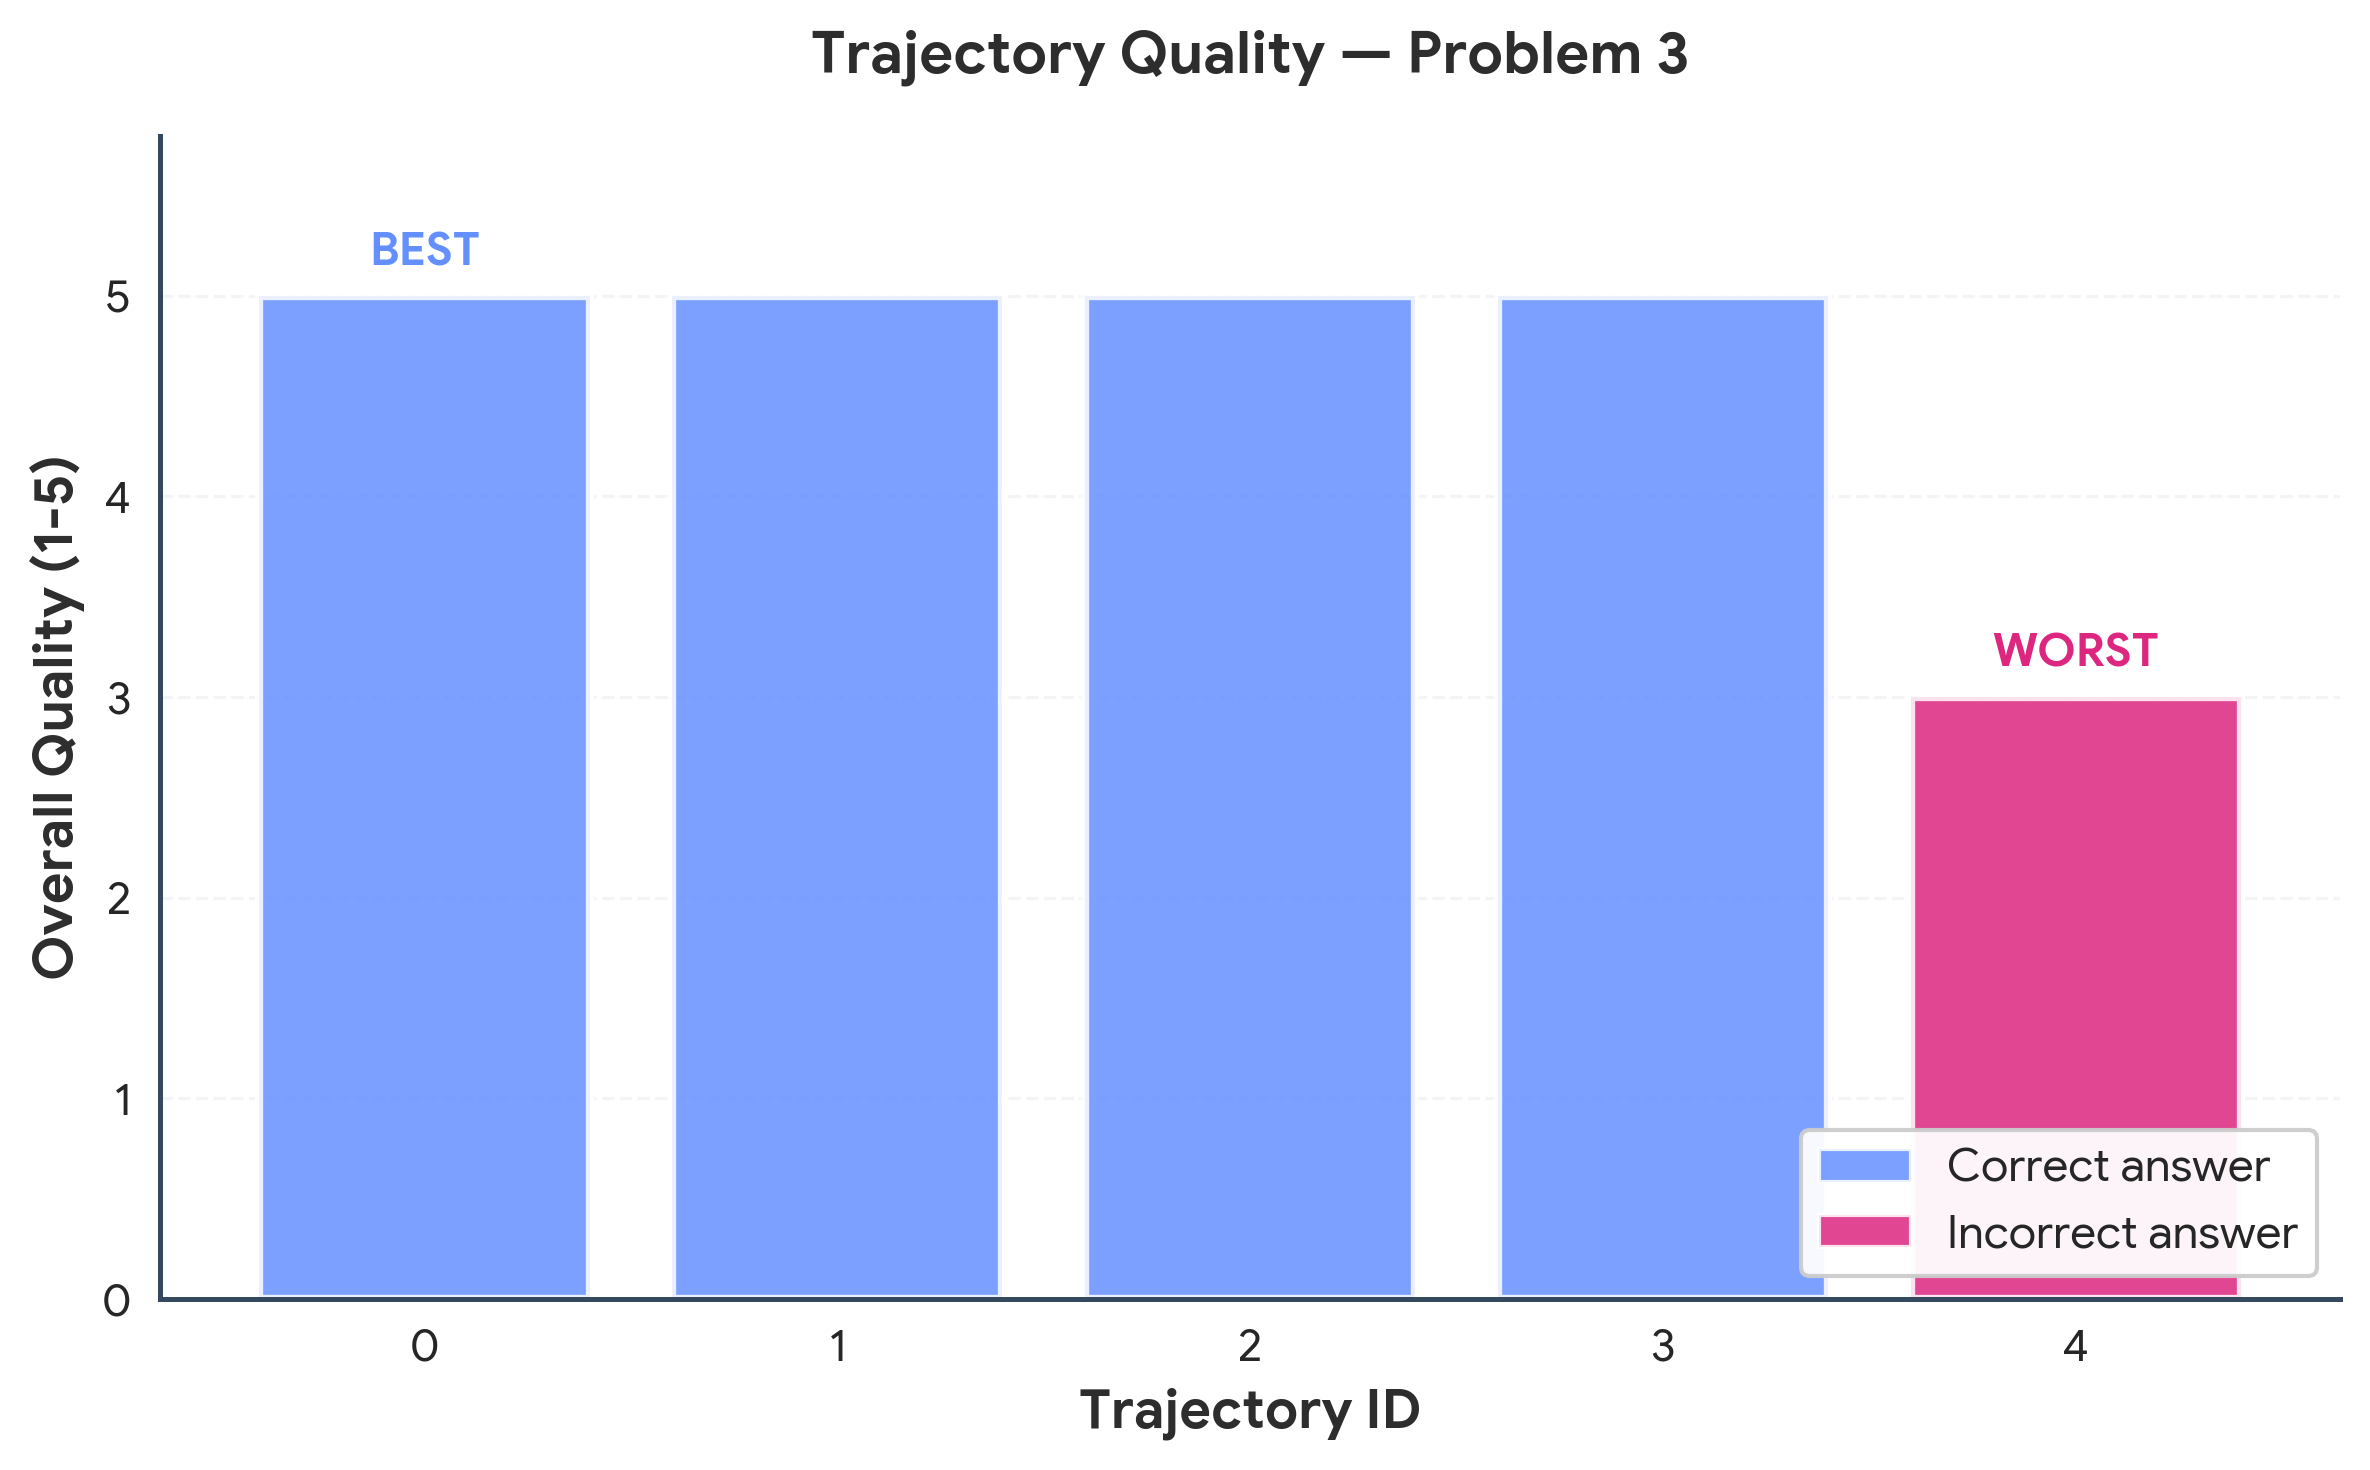

In [ ]:
# =============================================================================
# VISUALIZATION FUNCTIONS (Streamlined for Paper)
# =============================================================================

def plot_trajectory_distance_heatmap(result, problem_idx):
    """Plot pairwise distance matrix as a heatmap."""
    emb_results = result['embedding_results']
    dist_matrix = emb_results.pairwise_distance_matrix
    
    if dist_matrix is None or len(dist_matrix) < 2:
        print("No distance matrix to plot")
        return None
    
    fig, ax = plt.subplots(figsize=(7, 5.5), dpi=300)
    
    im = ax.imshow(dist_matrix, cmap=HEATMAP_CMAP, aspect='auto')
    
    n = len(dist_matrix)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([f'T{i}' for i in range(n)], fontsize=12)
    ax.set_yticklabels([f'T{i}' for i in range(n)], fontsize=12)
    
    for i in range(n):
        for j in range(n):
            val = dist_matrix[i, j]
            text_color = 'white' if val > 0.05 else COLORS['dark_gray']
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', 
                   color=text_color, fontsize=11, fontweight='bold')
    
    ax.set_title(f'Trajectory Pairwise Distances — Problem {problem_idx + 1}\n(Higher = More Different)', 
                fontsize=14, fontweight='bold', pad=15, color=COLORS['dark_gray'])
    ax.set_xlabel('Trajectory', fontsize=13, fontweight='bold', color=COLORS['dark_gray'])
    ax.set_ylabel('Trajectory', fontsize=13, fontweight='bold', color=COLORS['dark_gray'])
    
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Cosine Distance', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=11)
    
    plt.tight_layout()
    return fig


def print_trajectory_details(result, problem_idx):
    """
    Print each trajectory's steps so we can see the raw data
    that went into the pairwise distance heatmap.
    """
    trajectories = result['trajectories']
    
    print(f"\n{'─'*70}")
    print(f"  Trajectory Contents — Problem {problem_idx + 1}")
    print(f"{'─'*70}")
    
    for traj_idx, traj in enumerate(trajectories):
        print(f"\n  T{traj_idx} ({len(traj)} steps):")
        print(f"  {'─'*50}")
        for step_idx, step in enumerate(traj):
            # Clean up step text
            display_text = step
            if ':' in display_text[:15]:
                display_text = display_text.split(':', 1)[1].strip()
            # if len(display_text) > 65:
            #     display_text = display_text[:62] + "..."
            print(f"    Step {step_idx + 1}: {display_text}")
    
    print(f"\n{'─'*70}\n")


def generate_step_labels(aligned_metadata, num_trajectories):
    """
    Generate x-axis labels showing which steps mapped to each position.
    
    Rules:
    - T*.N  = ALL trajectories contributed exactly step N (and only step N)
    - Otherwise, list each trajectory's contribution explicitly
    
    Examples:
    - "T*.1" = all 5 trajectories contributed step 1
    - "T0-3.2, T4.2-3" = T0,T1,T2,T3 contributed step 2; T4 contributed steps 2 and 3
    """
    labels = []
    
    for pos_idx, metadata in enumerate(aligned_metadata):
        # Group by trajectory: {traj_id: [step_indices]}
        traj_steps = {}
        for traj_id, step_idx in metadata:
            if traj_id not in traj_steps:
                traj_steps[traj_id] = []
            traj_steps[traj_id].append(step_idx + 1)  # 1-indexed for display
        
        # Check if ALL trajectories contributed the SAME single step
        all_same = (
            len(traj_steps) == num_trajectories and
            all(len(steps) == 1 for steps in traj_steps.values()) and
            len(set(steps[0] for steps in traj_steps.values())) == 1
        )
        
        if all_same:
            step_num = list(traj_steps.values())[0][0]
            label = f"T*.{step_num}"
        else:
            # Group trajectories by their step contribution pattern
            contribution_groups = {}
            for traj_id, steps in traj_steps.items():
                steps_sorted = tuple(sorted(steps))
                if steps_sorted not in contribution_groups:
                    contribution_groups[steps_sorted] = []
                contribution_groups[steps_sorted].append(traj_id)
            
            parts = []
            for steps, traj_ids in sorted(contribution_groups.items(), key=lambda x: min(x[1])):
                # Format step range
                if len(steps) == 1:
                    step_str = str(steps[0])
                else:
                    step_str = f"{min(steps)}-{max(steps)}"
                
                # Format trajectory range
                traj_ids_sorted = sorted(traj_ids)
                if len(traj_ids_sorted) == 1:
                    traj_str = f"T{traj_ids_sorted[0]}"
                elif traj_ids_sorted == list(range(min(traj_ids_sorted), max(traj_ids_sorted) + 1)):
                    # Consecutive range
                    traj_str = f"T{min(traj_ids_sorted)}-{max(traj_ids_sorted)}"
                else:
                    traj_str = ",".join(f"T{t}" for t in traj_ids_sorted)
                
                parts.append(f"{traj_str}.{step_str}")
            
            label = "\n".join(parts) if len(parts) > 1 else parts[0]
        
        labels.append(label)
    
    return labels


def print_aligned_step_details(result, problem_idx):
    """
    Print the raw step content for each DTW-aligned position.
    Shows exactly what steps were collapsed together.
    """
    emb_results = result['embedding_results']
    
    if not hasattr(emb_results, 'aligned_step_metadata') or not emb_results.aligned_step_metadata:
        print("  No alignment metadata available")
        return
    
    print(f"\n{'─'*70}")
    print(f"  DTW-Aligned Step Details — Problem {problem_idx + 1}")
    print(f"{'─'*70}")
    
    for pos_idx, (metadata, step_group) in enumerate(zip(
        emb_results.aligned_step_metadata, 
        emb_results.aligned_step_groups
    )):
        dist = emb_results.step_mean_distances[pos_idx]
        print(f"\n  Position {pos_idx + 1} | Mean Distance: {dist:.4f}")
        print(f"  {'─'*50}")
        
        # Sort by trajectory ID for consistent display
        entries = list(zip(metadata, step_group))
        entries.sort(key=lambda x: (x[0][0], x[0][1]))
        
        for (traj_id, step_idx), step_text in entries:
            # Truncate long step text
            display_text = step_text
            if ':' in display_text[:15]:
                display_text = display_text.split(':', 1)[1].strip()
            # if len(display_text) > 60:
            #     display_text = display_text[:57] + "..."
            
            print(f"    T{traj_id}.{step_idx + 1}: {display_text}")
    
    print(f"\n{'─'*70}\n")


def plot_step_distances(result, problem_idx):
    """
    Plot DTW-aligned step-level mean distances.
    X-axis shows step mapping in T*.N notation.
    """
    emb_results = result['embedding_results']
    
    num_steps = emb_results.num_aligned_steps
    mean_dists = emb_results.step_mean_distances
    num_trajectories = len(result['trajectories'])
    
    # Generate labels from metadata
    if hasattr(emb_results, 'aligned_step_metadata') and emb_results.aligned_step_metadata:
        step_labels = generate_step_labels(emb_results.aligned_step_metadata, num_trajectories)
    else:
        step_labels = [f"Pos {i+1}" for i in range(num_steps)]
    
    fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)
    
    x_pos = range(num_steps)
    bars = ax.bar(x_pos, mean_dists, color=COLORS['blue'], alpha=0.85, 
                  edgecolor='white', linewidth=2)
    
    # Highlight max distance step
    max_idx = np.argmax(mean_dists)
    bars[max_idx].set_color(COLORS['orange'])
    bars[max_idx].set_alpha(0.95)
    
    ax.set_xlabel('Aligned Position (Trajectory.Step)', fontsize=13, fontweight='bold', color=COLORS['dark_gray'])
    ax.set_ylabel('Mean Pairwise Distance', fontsize=13, fontweight='bold', color=COLORS['dark_gray'])
    ax.set_title(f'Step-Level Divergence — Problem {problem_idx + 1}', 
                fontsize=14, fontweight='bold', color=COLORS['dark_gray'], pad=20)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(step_labels, fontsize=9, ha='center')
    
    ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.8, axis='y')
    ax.tick_params(axis='y', labelsize=11)
    
    # Max divergence annotation
    y_max = max(mean_dists) if mean_dists else 0.1
    ax.set_ylim(0, y_max * 1.25)
    
    max_label_short = step_labels[max_idx].replace("\n", ", ")
    ax.text(0.98, 0.95, f'Max: {mean_dists[max_idx]:.3f}\n({max_label_short})', 
           transform=ax.transAxes, fontsize=10, fontweight='bold', color=COLORS['orange'],
           ha='right', va='top',
           bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor=COLORS['orange']))
    
    plt.tight_layout()
    return fig


def plot_trajectory_quality(result, problem_idx):
    """Plot quality scores colored by correctness."""
    llm_results = result['llm_results']
    evals = llm_results.trajectory_evaluations.evaluations
    
    if len(evals) == 0:
        print("No trajectory evaluations to plot")
        return None
    
    fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
    
    traj_ids = [e.trajectory_id for e in evals]
    qualities = [e.overall_quality for e in evals]
    correct = [e.reaches_correct_answer for e in evals]
    
    colors = [COLORS['correct'] if c else COLORS['incorrect'] for c in correct]
    bars = ax.bar(traj_ids, qualities, color=colors, alpha=0.85,
                  edgecolor='white', linewidth=2)
    
    best_id = llm_results.best_trajectory_id
    worst_id = llm_results.worst_trajectory_id
    
    unique_qualities = set(qualities)
    if len(unique_qualities) == 1:
        mid_traj = len(traj_ids) // 2
        ax.annotate('ALL EQUAL', xy=(mid_traj, qualities[0] + 0.2), 
                   ha='center', fontsize=12, fontweight='bold', color=COLORS['dark_gray'],
                   bbox=dict(boxstyle='round,pad=0.4', facecolor=COLORS['yellow'], 
                            alpha=0.8, edgecolor='none'))
    elif best_id != worst_id:
        ax.annotate('BEST', xy=(best_id, qualities[best_id] + 0.15), 
                   ha='center', fontsize=11, fontweight='bold', color=COLORS['blue'])
        ax.annotate('WORST', xy=(worst_id, qualities[worst_id] + 0.15), 
                   ha='center', fontsize=11, fontweight='bold', color=COLORS['magenta'])
    
    ax.set_xlabel('Trajectory ID', fontsize=13, fontweight='bold', color=COLORS['dark_gray'])
    ax.set_ylabel('Overall Quality (1-5)', fontsize=13, fontweight='bold', color=COLORS['dark_gray'])
    ax.set_title(f'Trajectory Quality — Problem {problem_idx + 1}', 
                fontsize=14, fontweight='bold', color=COLORS['dark_gray'], pad=15)
    ax.set_ylim(0, 5.8)
    ax.set_xticks(traj_ids)
    
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=COLORS['correct'], label='Correct answer', alpha=0.85),
                      Patch(facecolor=COLORS['incorrect'], label='Incorrect answer', alpha=0.85)]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.95)
    ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.8, axis='y')
    ax.tick_params(axis='both', labelsize=11)
    
    plt.tight_layout()
    return fig


def visualize_problem_analysis(result, problem_idx):
    """Generate visualizations and raw data for a single problem."""
    print(f"\n{'='*60}")
    print(f"  Problem {problem_idx + 1} Visualizations")
    print(f"{'='*60}\n")
    
    fig1 = plot_trajectory_distance_heatmap(result, problem_idx)
    if fig1:
        plt.show()
    
    # Print raw trajectory data below heatmap
    print_trajectory_details(result, problem_idx)
    
    fig2 = plot_step_distances(result, problem_idx)
    if fig2:
        plt.show()
    
    # Print raw step details below the chart
    print_aligned_step_details(result, problem_idx)
    
    fig3 = plot_trajectory_quality(result, problem_idx)
    if fig3:
        plt.show()


# Generate visualizations using ORIGINAL dataset indices
for idx in range(min(3, len(all_results))):
    result = all_results[idx]
    problem_idx = result.get('dataset_idx', idx)  # Use original dataset index
    visualize_problem_analysis(result, problem_idx)


## 12. Visualization: Embedding Pipeline Metrics

### Comparing Trajectory-Level and Step-Level Uncertainty

This plot shows uncertainty metrics from Pipeline 1 across all problems:
- **Trajectory Mean Distance**: Overall divergence between complete reasoning paths
- **Step Avg Entropy**: Local uncertainty averaged across DTW-aligned steps

High correlation between these metrics suggests consistent uncertainty; divergence suggests some problems have localized uncertainty spikes.

In [14]:
# =============================================================================
# CROSS-PROBLEM SUMMARY TABLE
# =============================================================================
# Instead of complex multi-panel plots, present a simple summary table
# that can be directly used in the paper.

def generate_summary_table(all_results):
    """Generate a summary table of metrics across all problems."""
    rows = []
    
    for idx, result in enumerate(all_results):
        emb = result.get('embedding_results')
        llm = result.get('llm_results')
        
        if emb is None or llm is None:
            continue
        
        correct = sum(1 for e in llm.trajectory_evaluations.evaluations if e.reaches_correct_answer)
        total = len(llm.trajectory_evaluations.evaluations)
        
        rows.append({
            'Problem': result.get('dataset_idx', idx) + 1,
            'Traj Distance': f'{emb.traj_mean_distance:.4f}',
            'Avg Step Dist': f'{np.mean(emb.step_mean_distances):.4f}',
            'Max Step Dist': f'{np.max(emb.step_max_distances):.4f}',
            'Final Ans Unc': f'{emb.final_answer_mean_distance:.4f}',
            'Avg Quality': f'{llm.avg_quality:.2f}',
            'Correctness': f'{correct}/{total}'
        })
    
    if rows:
        df = pd.DataFrame(rows)
        print("\n" + "="*70)
        print("  SUMMARY TABLE (Copy to Paper)")
        print("="*70)
        print(df.to_string(index=False))
        print("="*70 + "\n")
        return df
    return None

# Generate summary table
if len(all_results) > 0:
    summary_df = generate_summary_table(all_results)



  SUMMARY TABLE (Copy to Paper)
 Problem Traj Distance Avg Step Dist Max Step Dist Final Ans Unc Avg Quality Correctness
       1        0.0389        0.1446        0.4108        0.0627        4.90         5/5
       2        0.0107        0.0727        0.1777        0.0844        5.00         5/5
       3        0.0575        0.1196        0.3250        0.1915        4.60         4/5
       4        0.0198        0.0963        0.3098        0.0223        5.00         5/5
       5        0.0231        0.0658        0.2216        0.1086        5.00         5/5
       6        0.0299        0.0974        0.3729        0.2327        4.50         5/5
       7        0.0356        0.0983        0.5423        0.2436        4.84         5/5
       8        0.0717        0.1928        0.3672        0.2092        4.70         2/5
       9        0.0398        0.1443        0.3573        0.1686        5.00         5/5
      10        0.0316        0.0840        0.2248        0.1489        4.90 

## 13. Visualization: Step-Level Divergence

### Pairwise Distances and Per-Step Metrics

For each problem, visualize:
1. **Pairwise Distance Matrix**: Which trajectories are most/least similar?
2. **Step Entropy & Clusters**: Where do trajectories diverge most?

Look for:
- **Off-diagonal patterns**: Groups of similar trajectories
- **Step spikes**: Specific reasoning choices causing divergence


  Detailed Step Analysis (Supplementary)


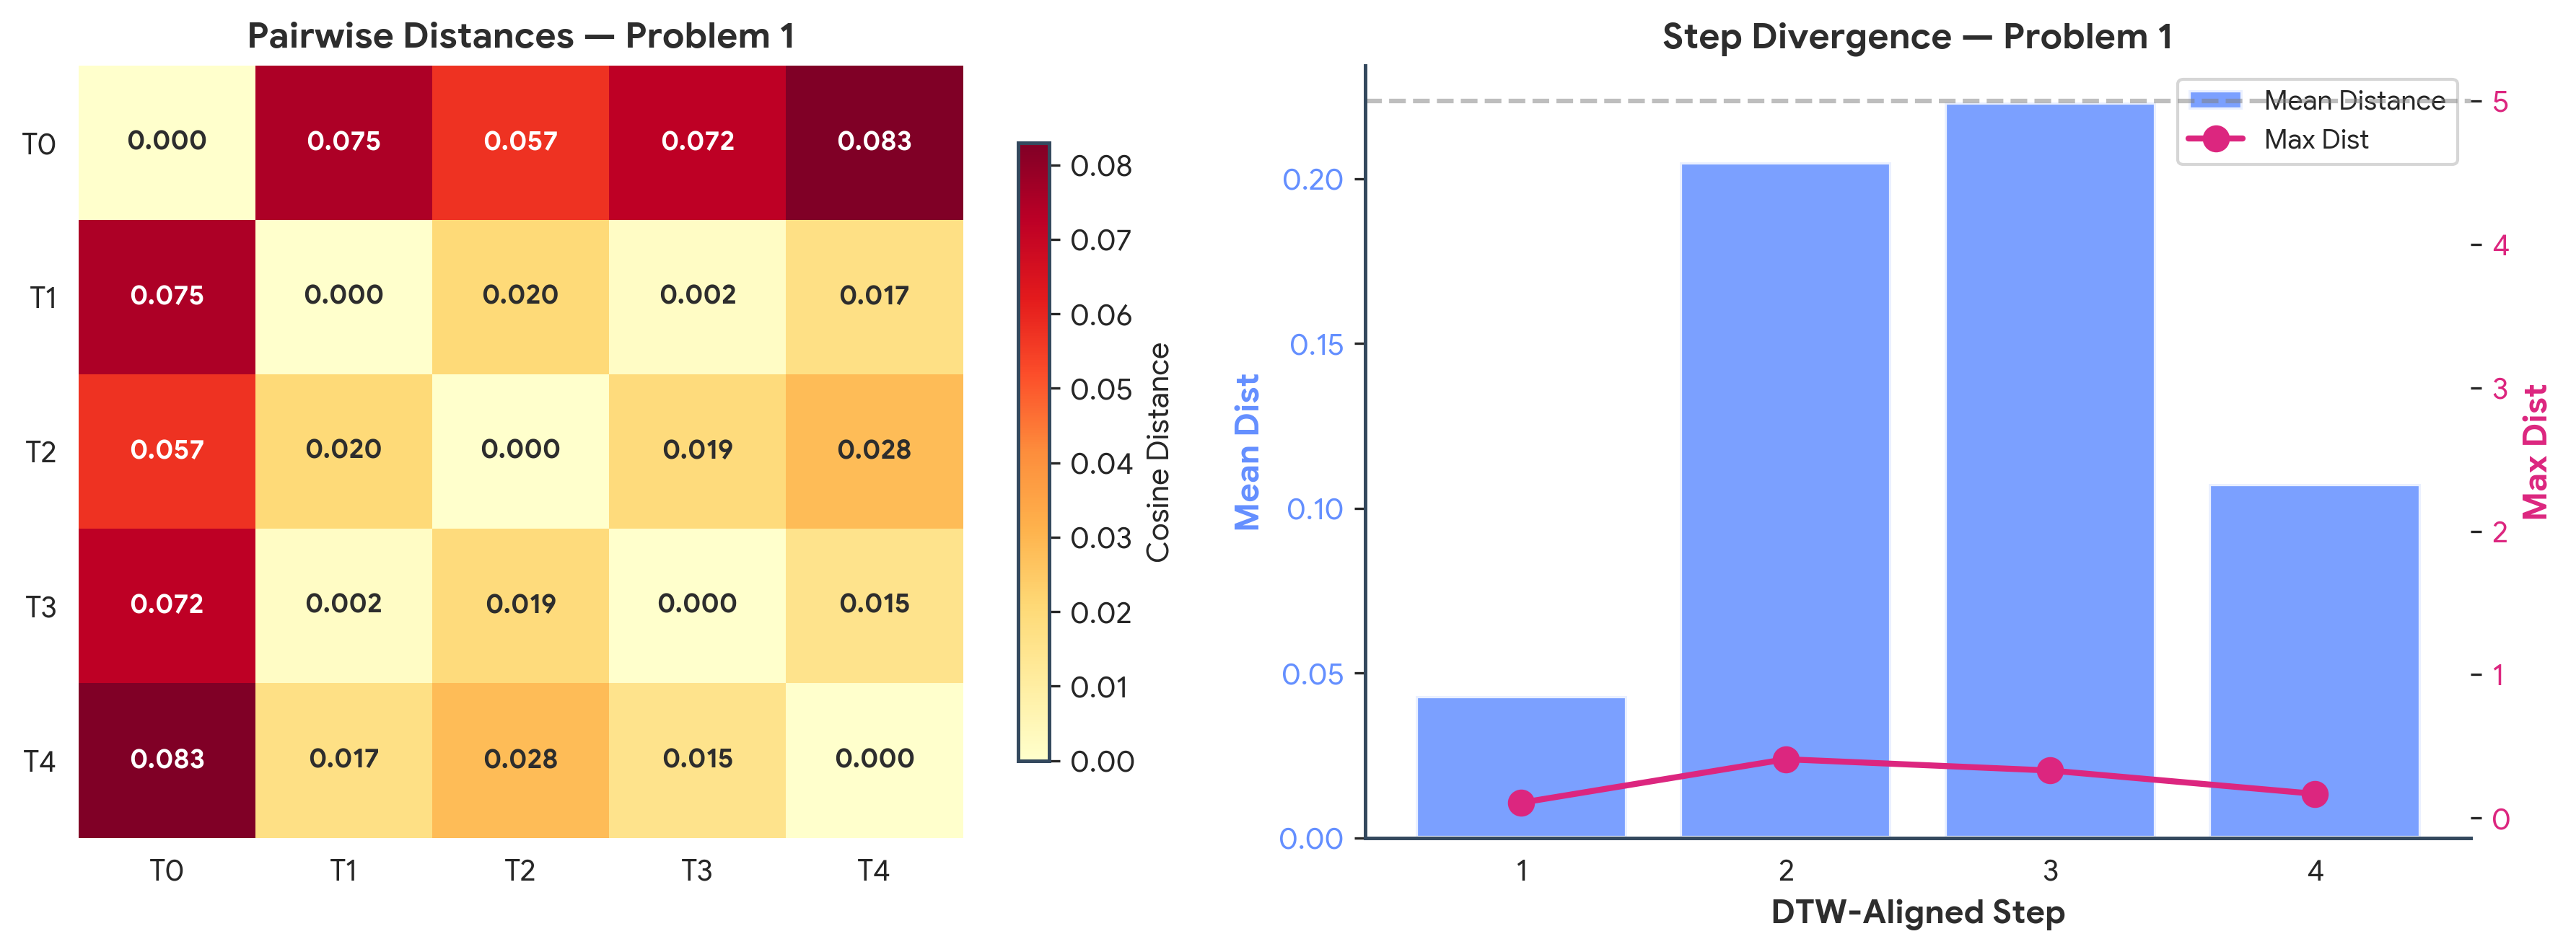

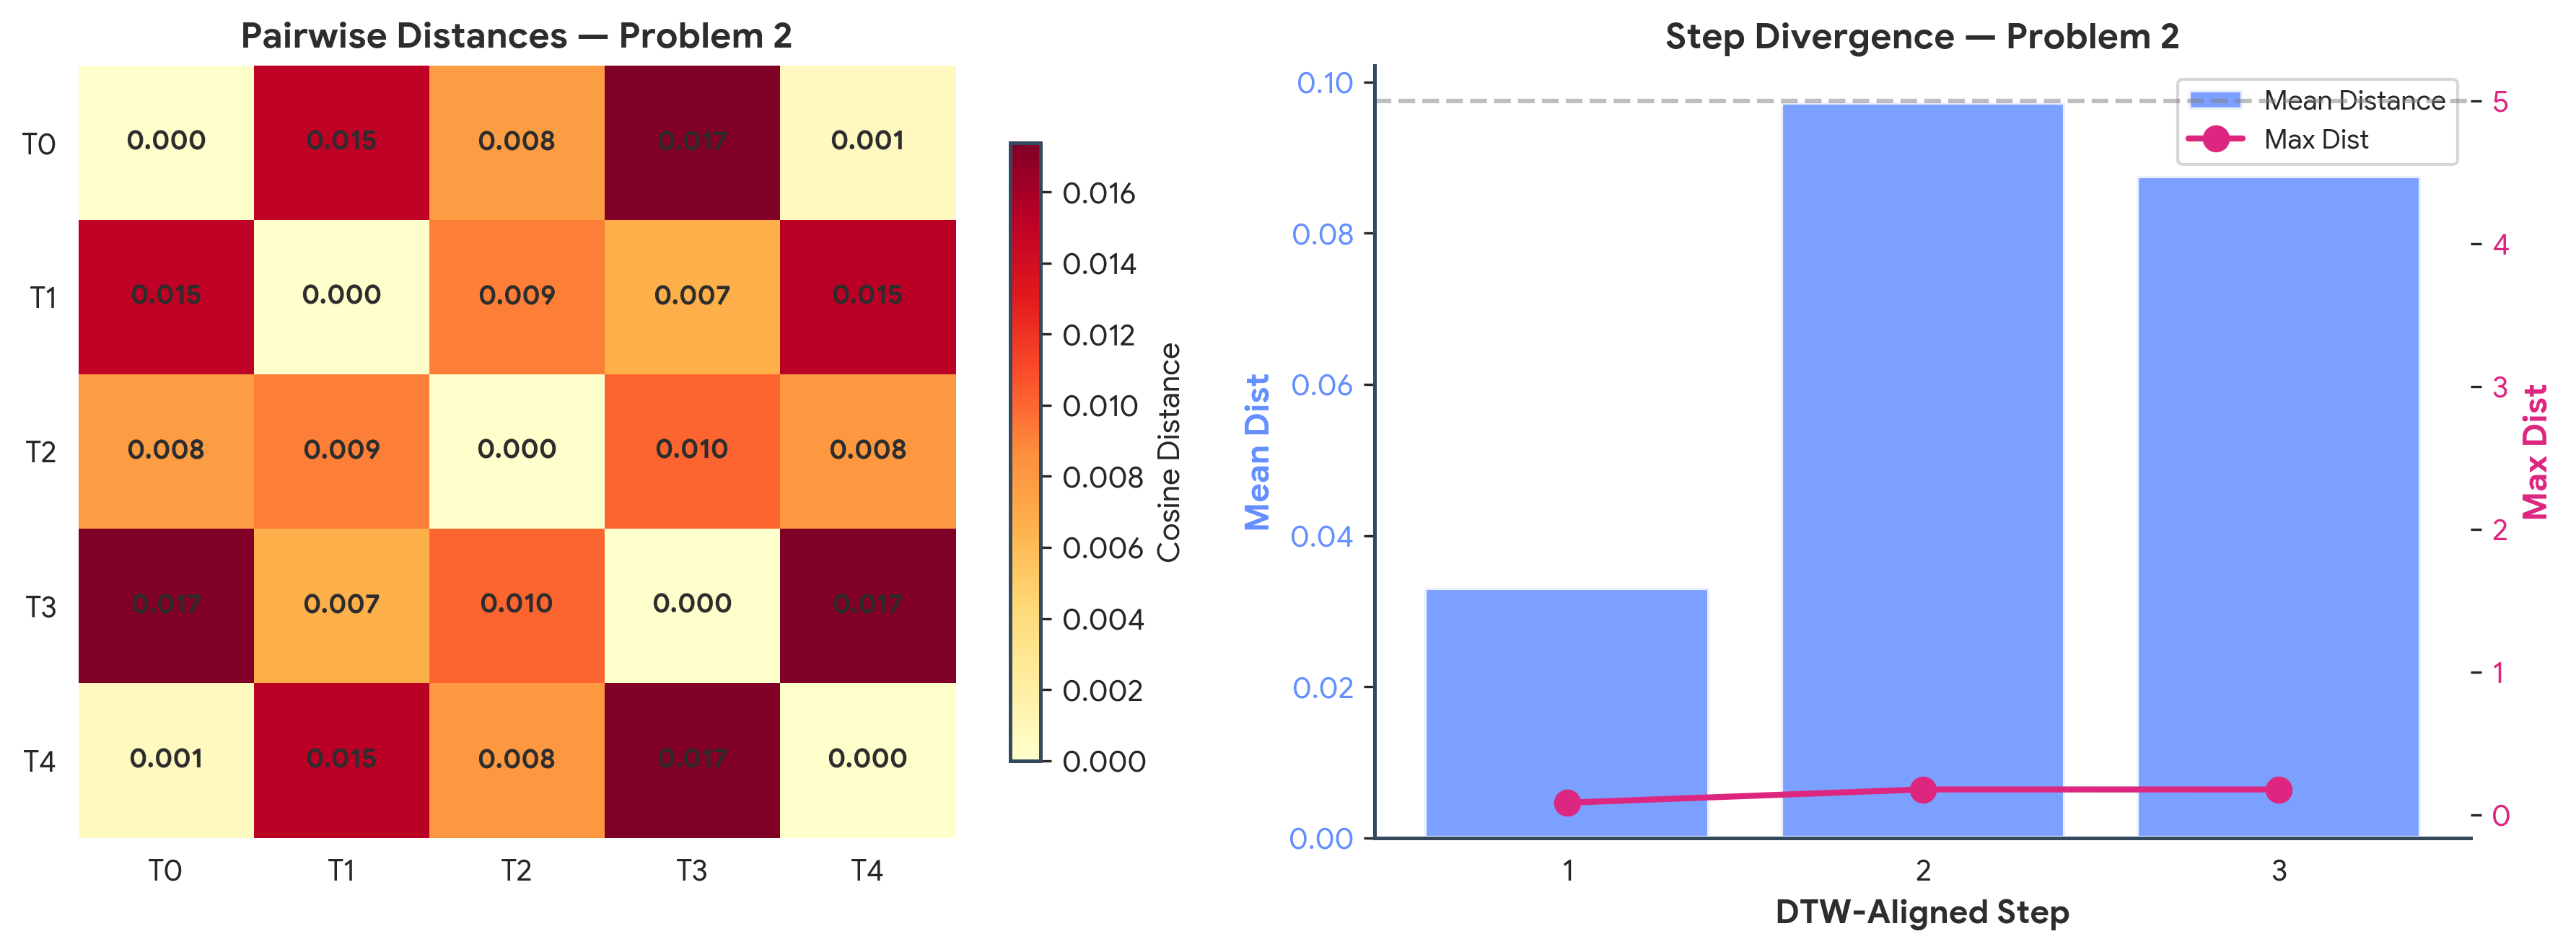

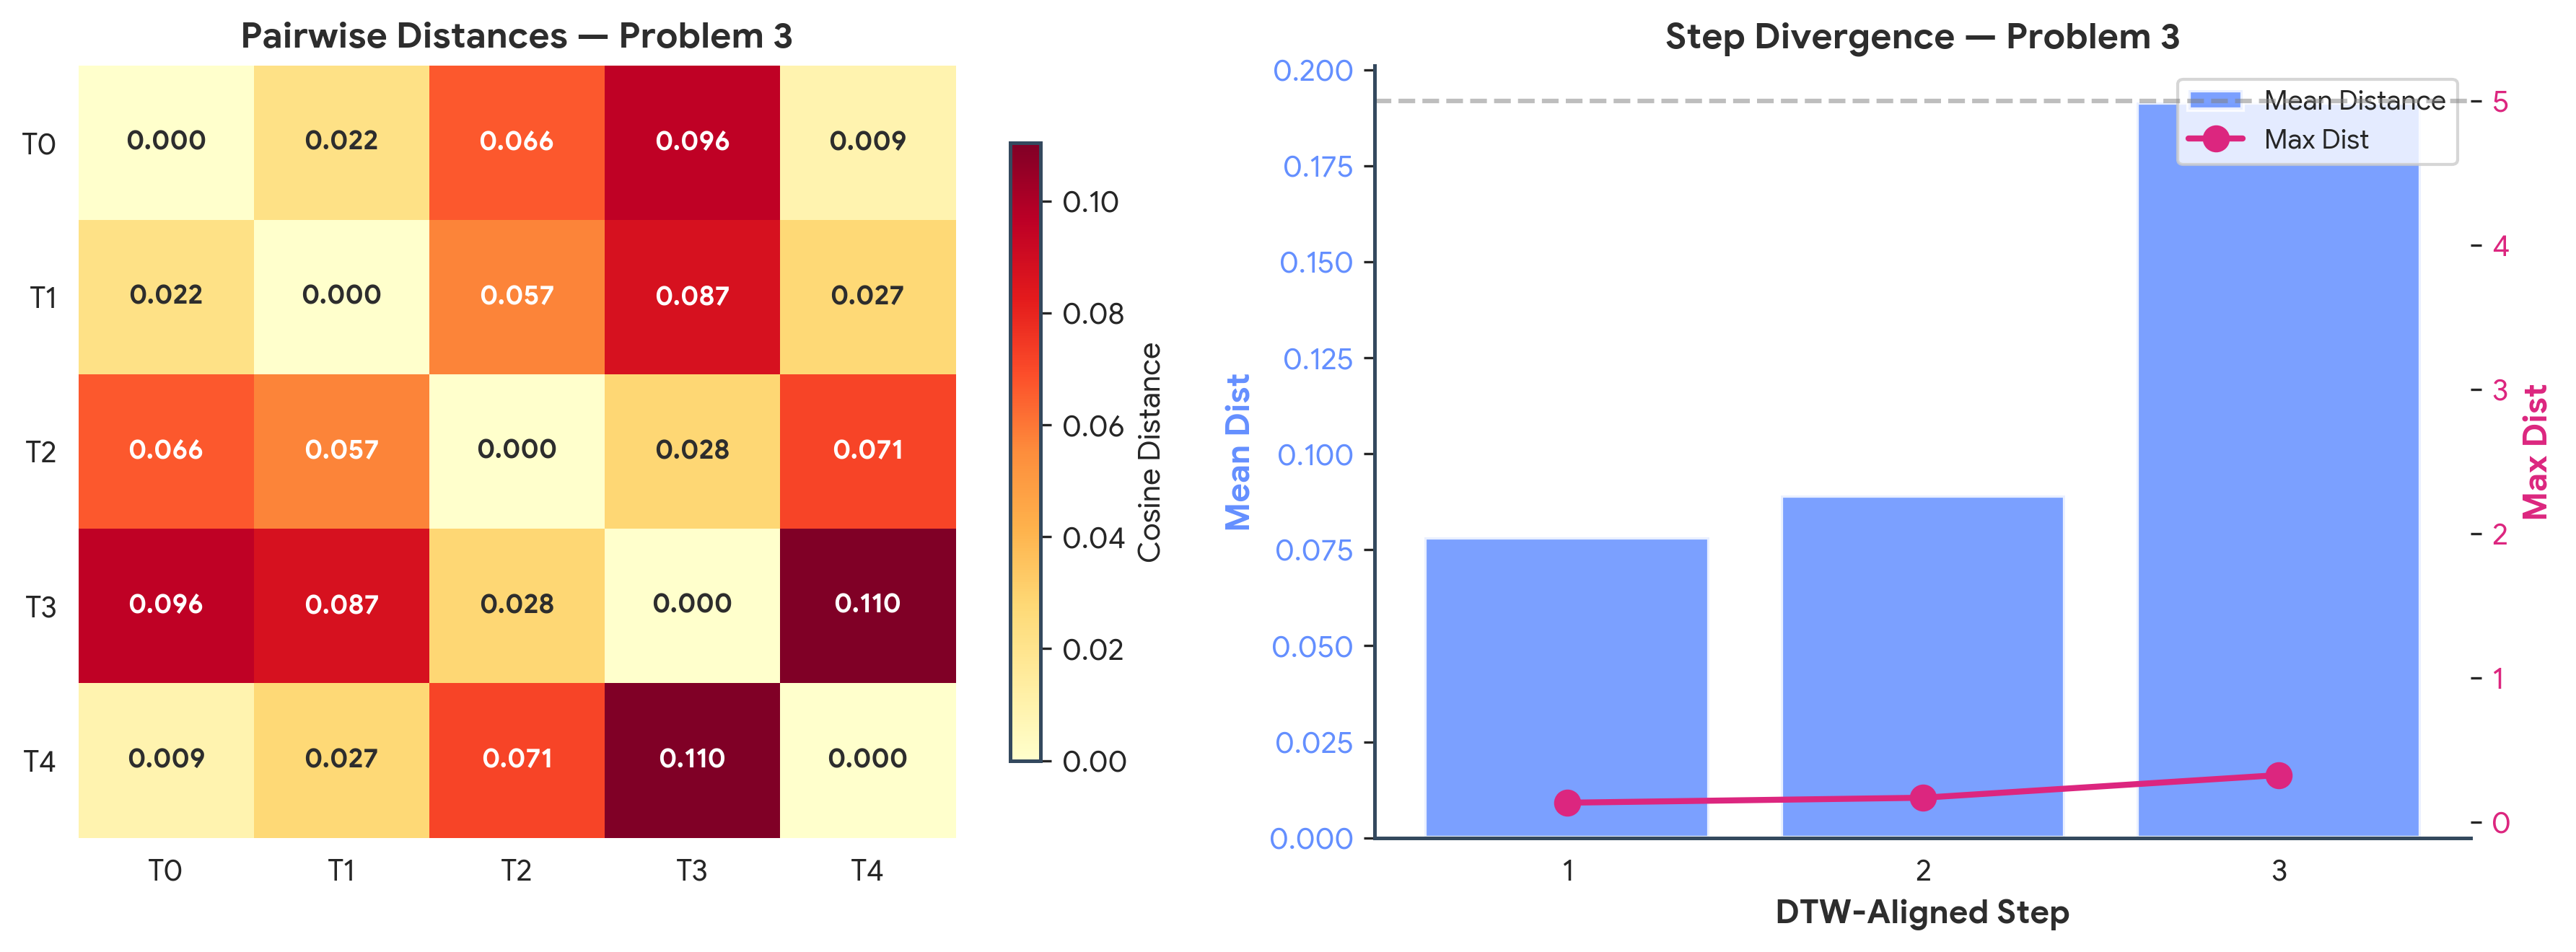

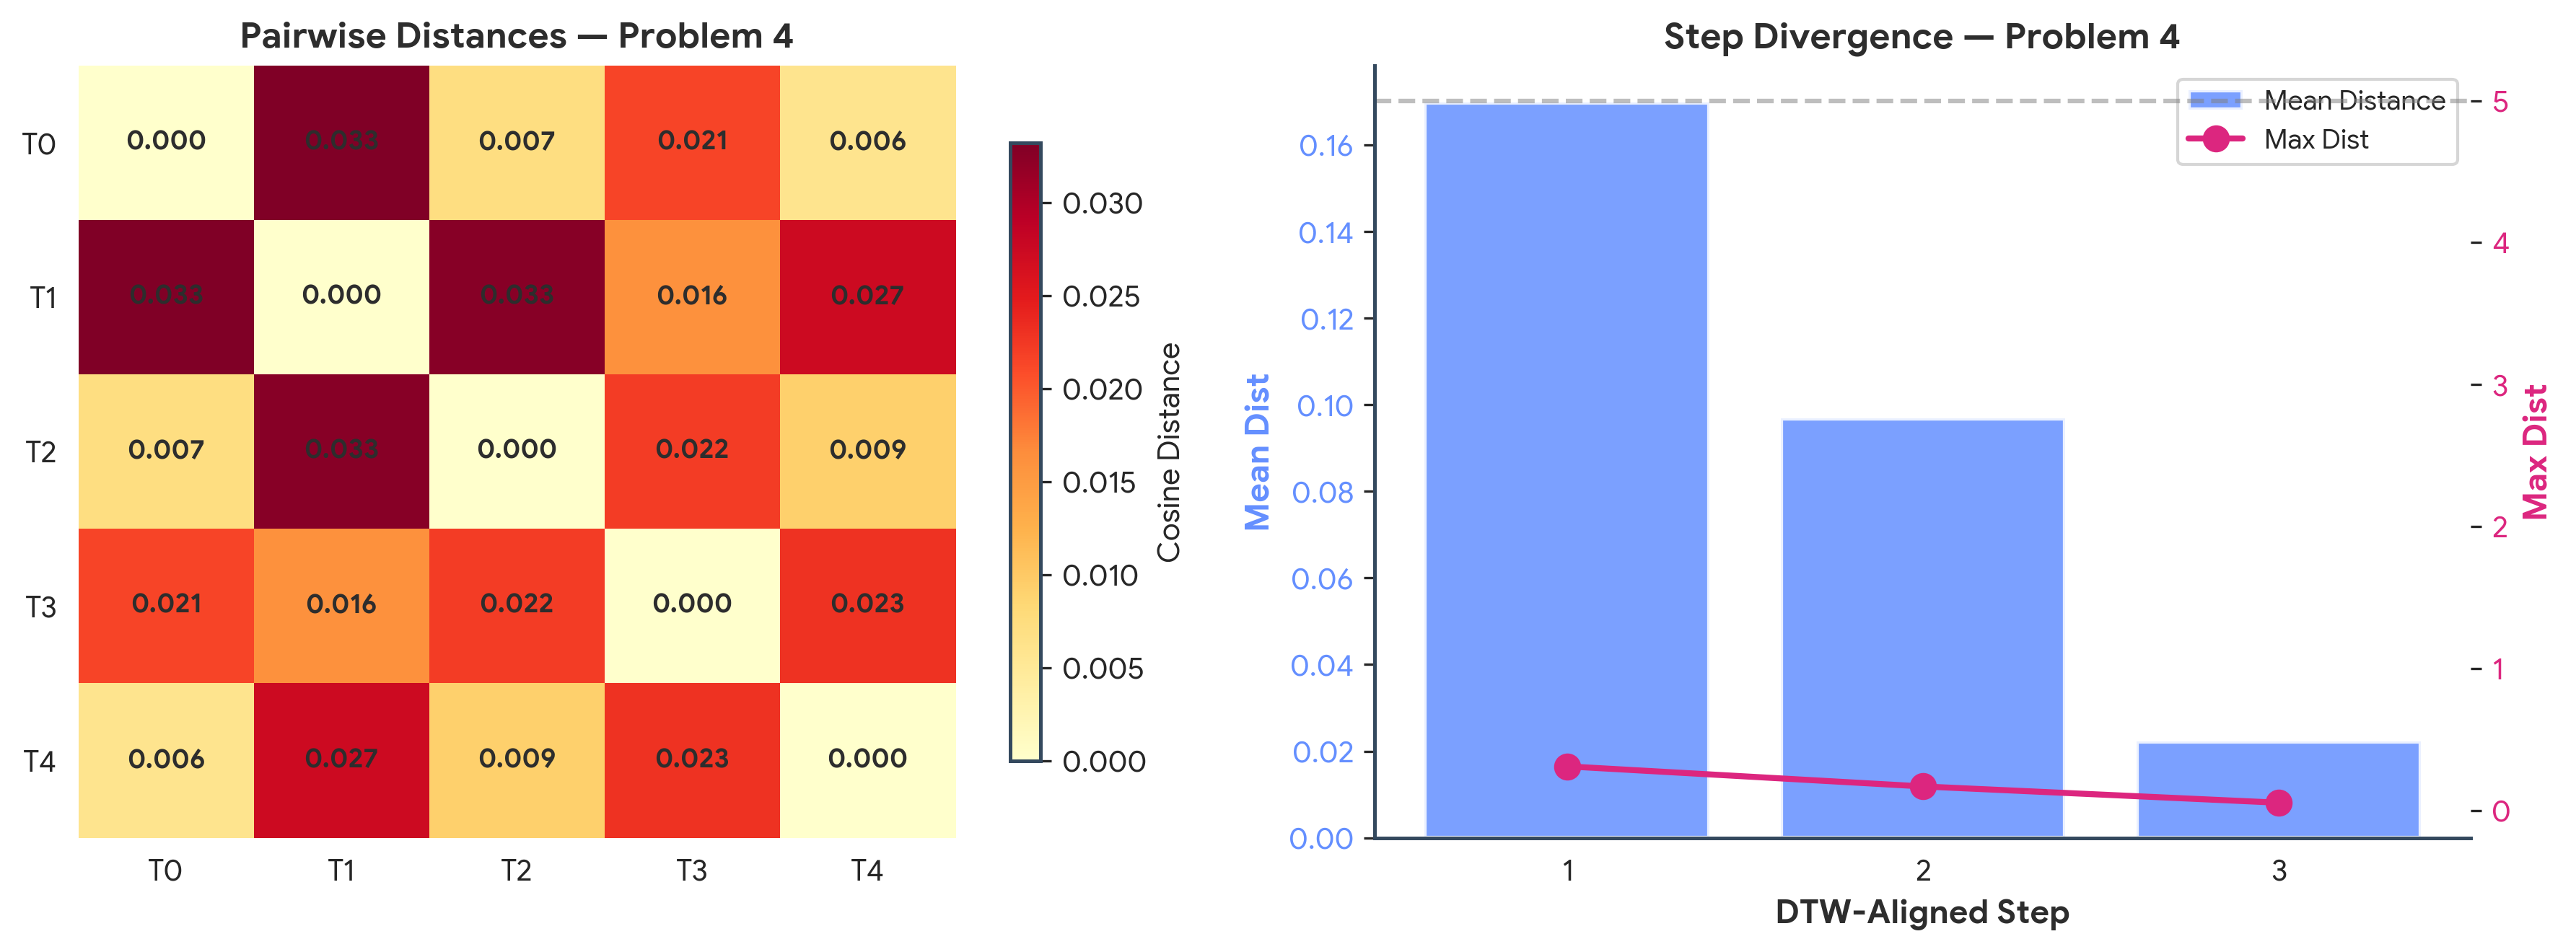

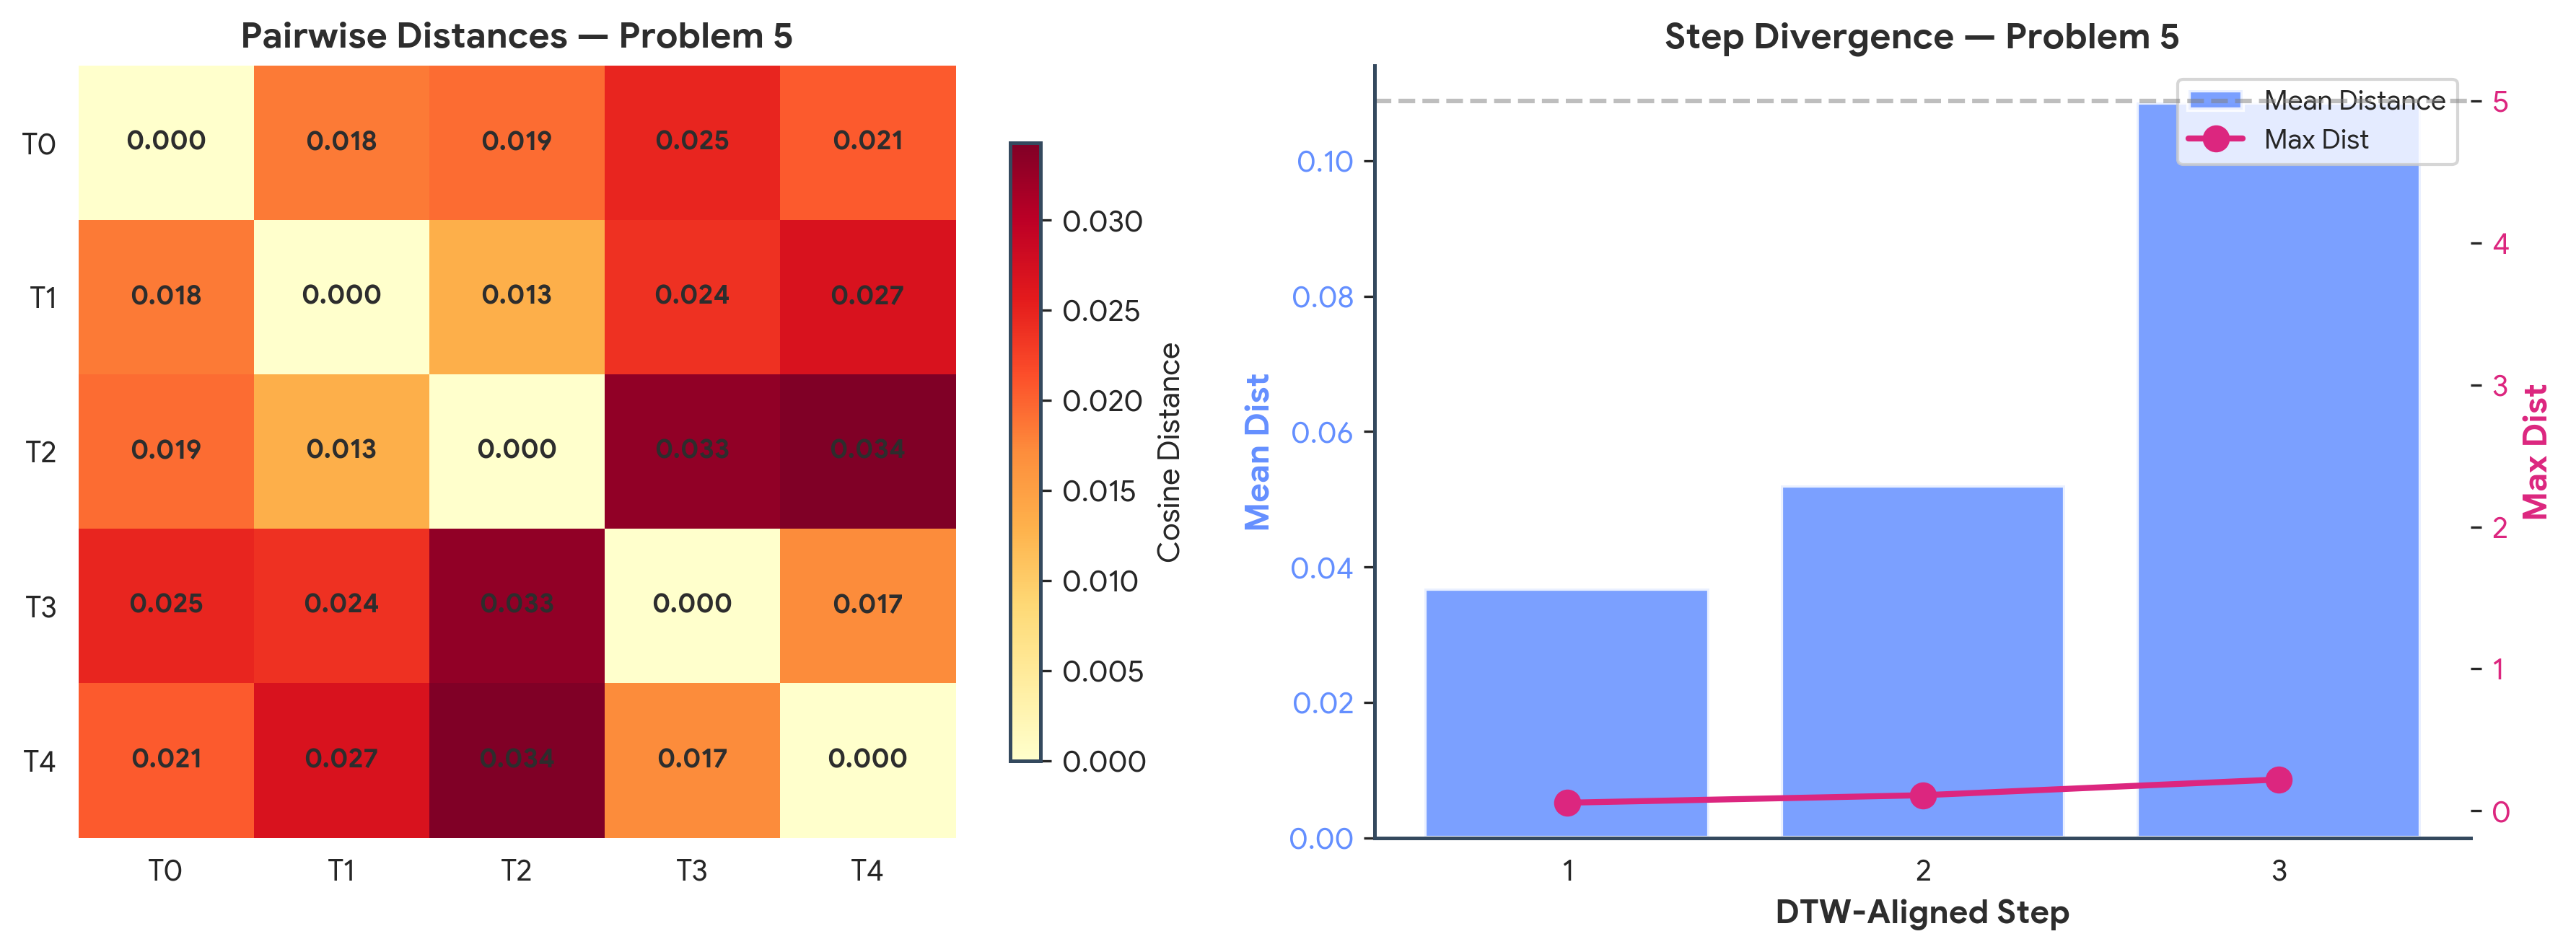

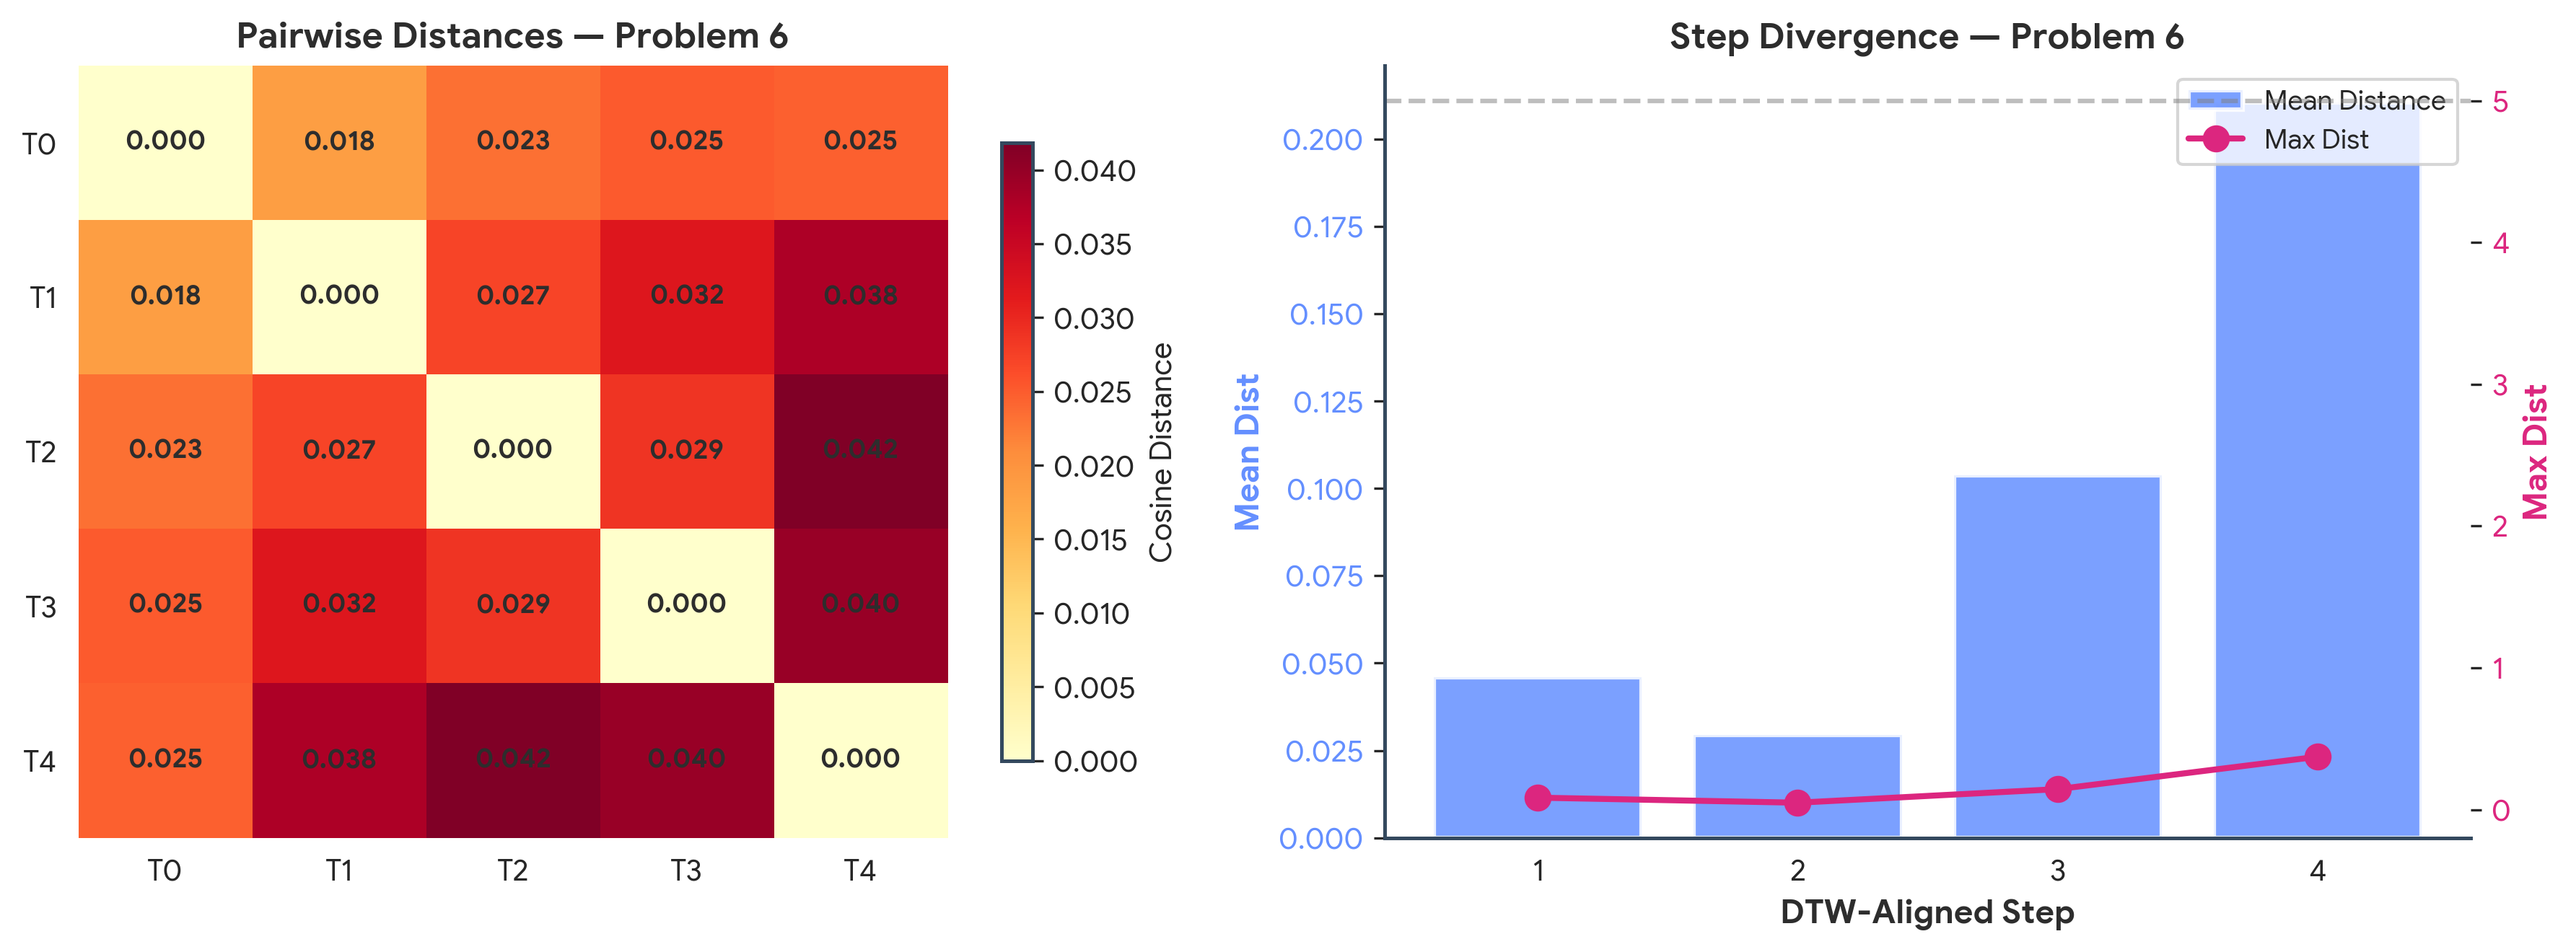

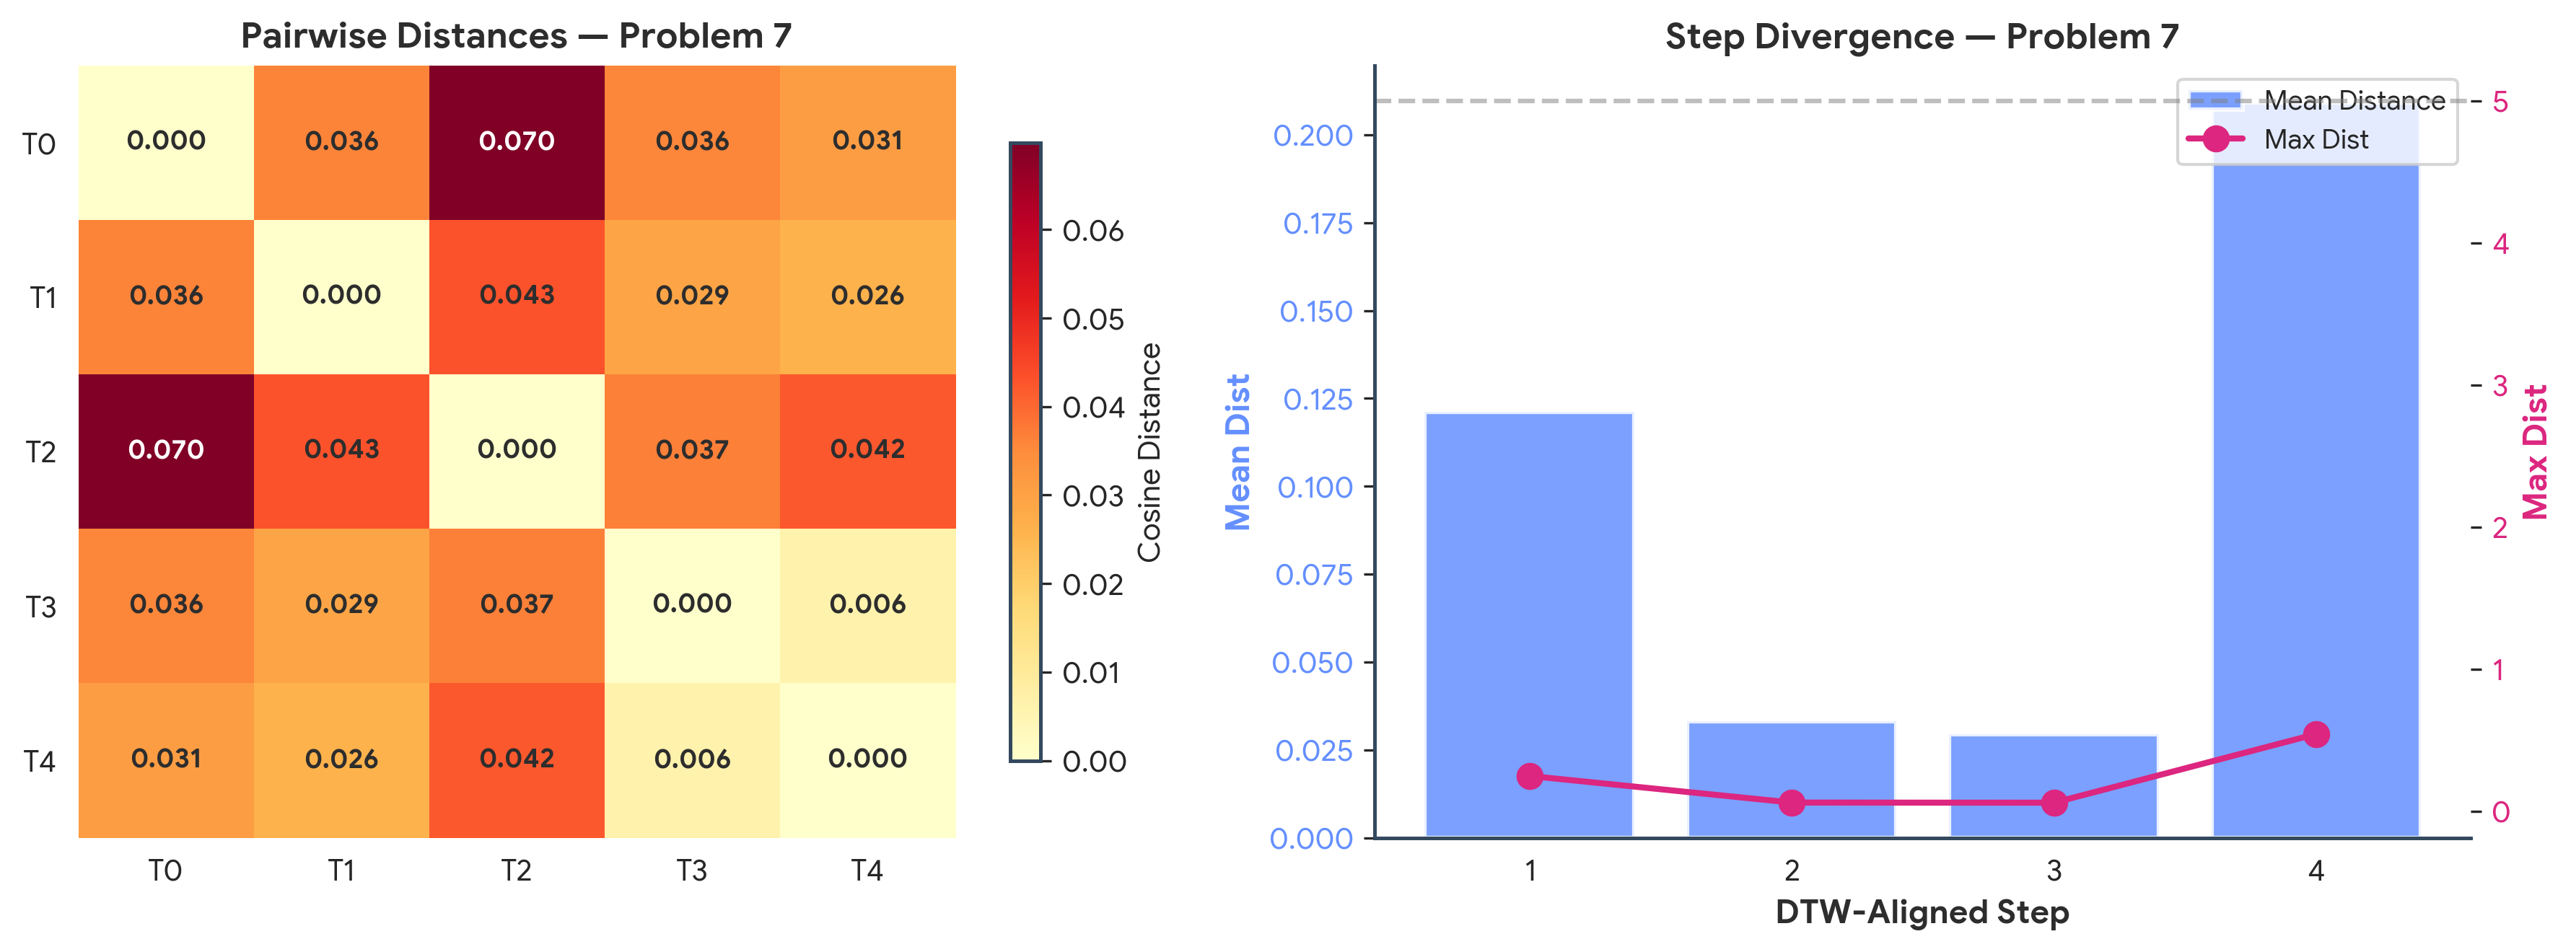

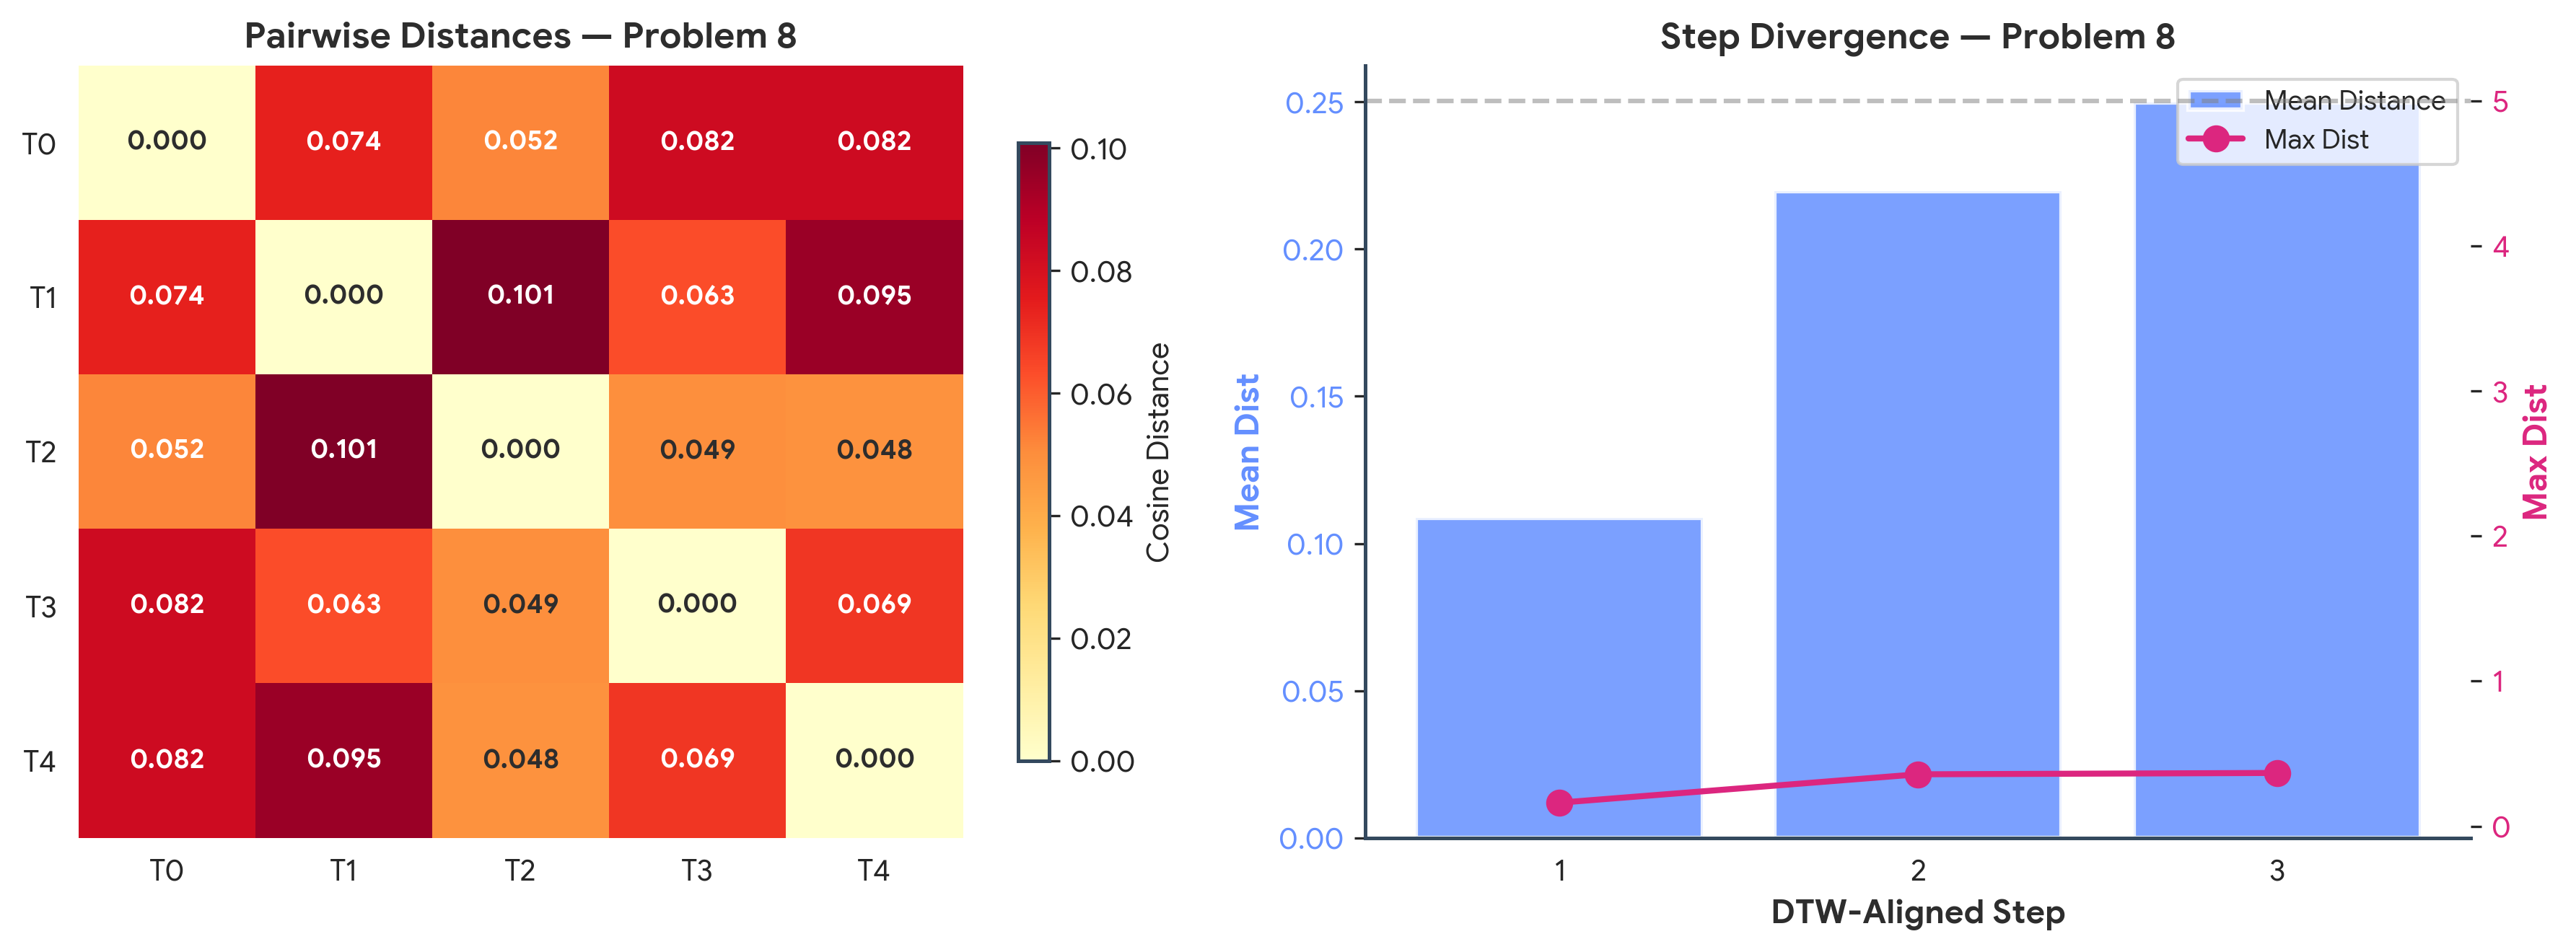

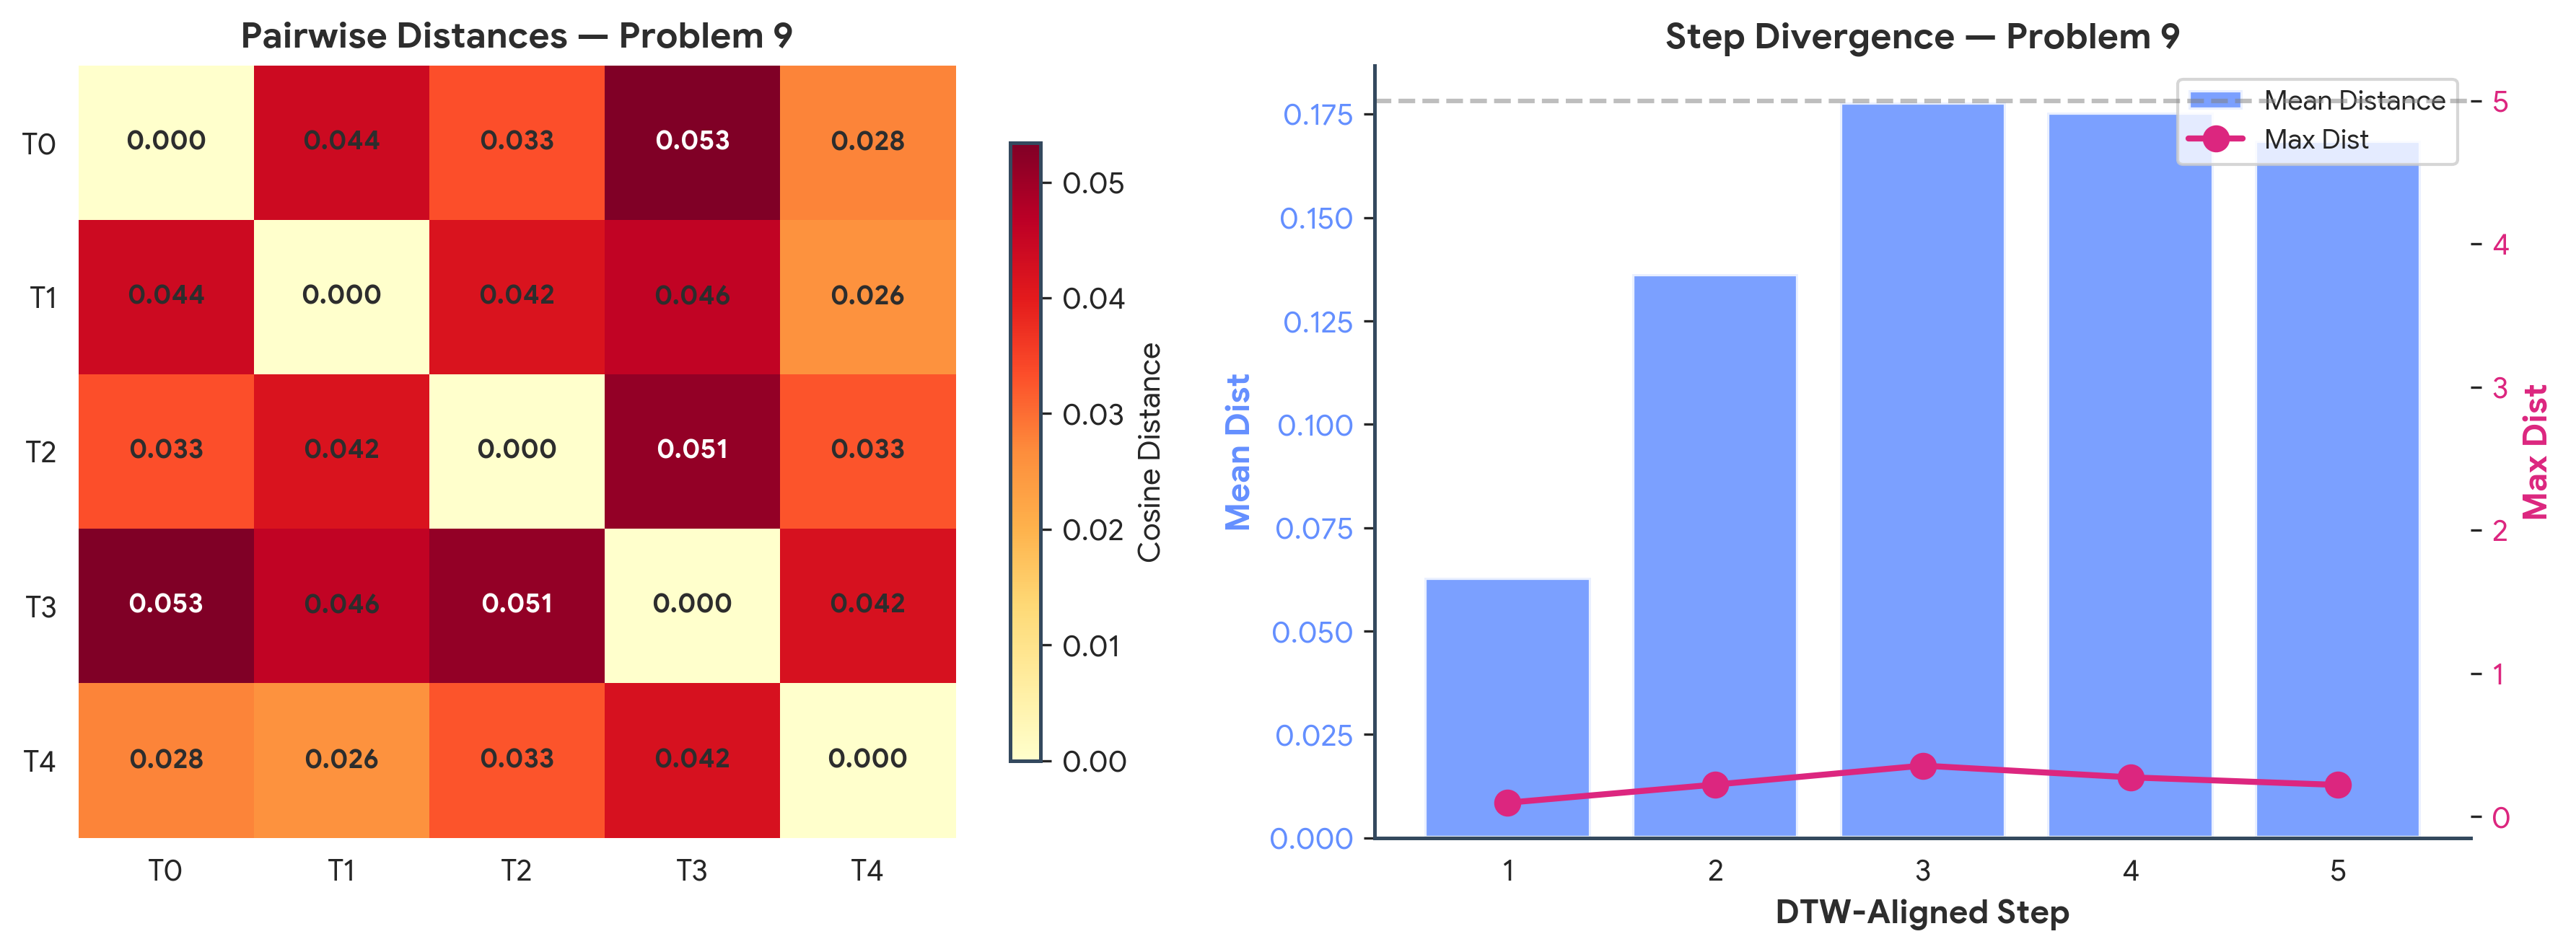

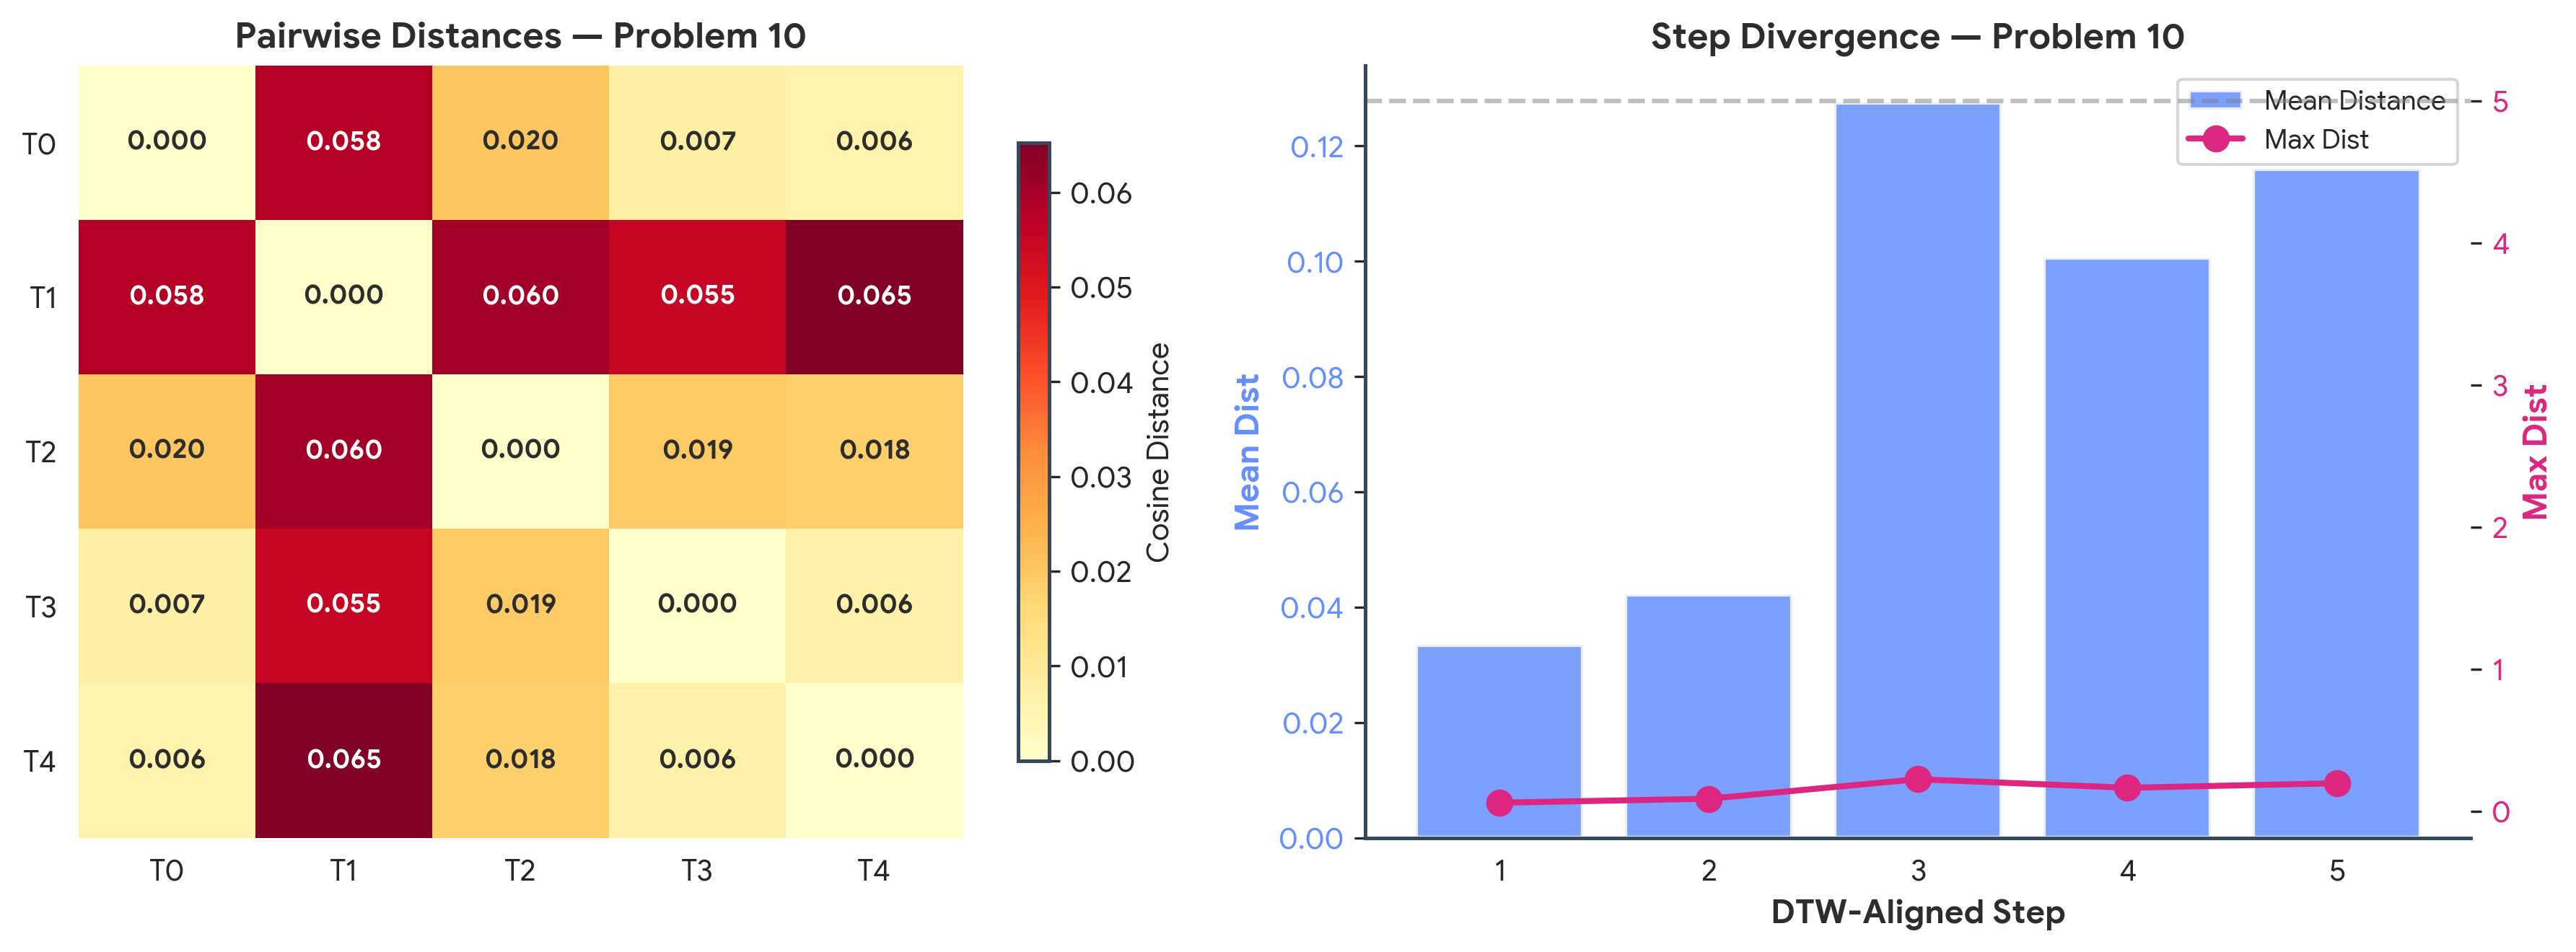

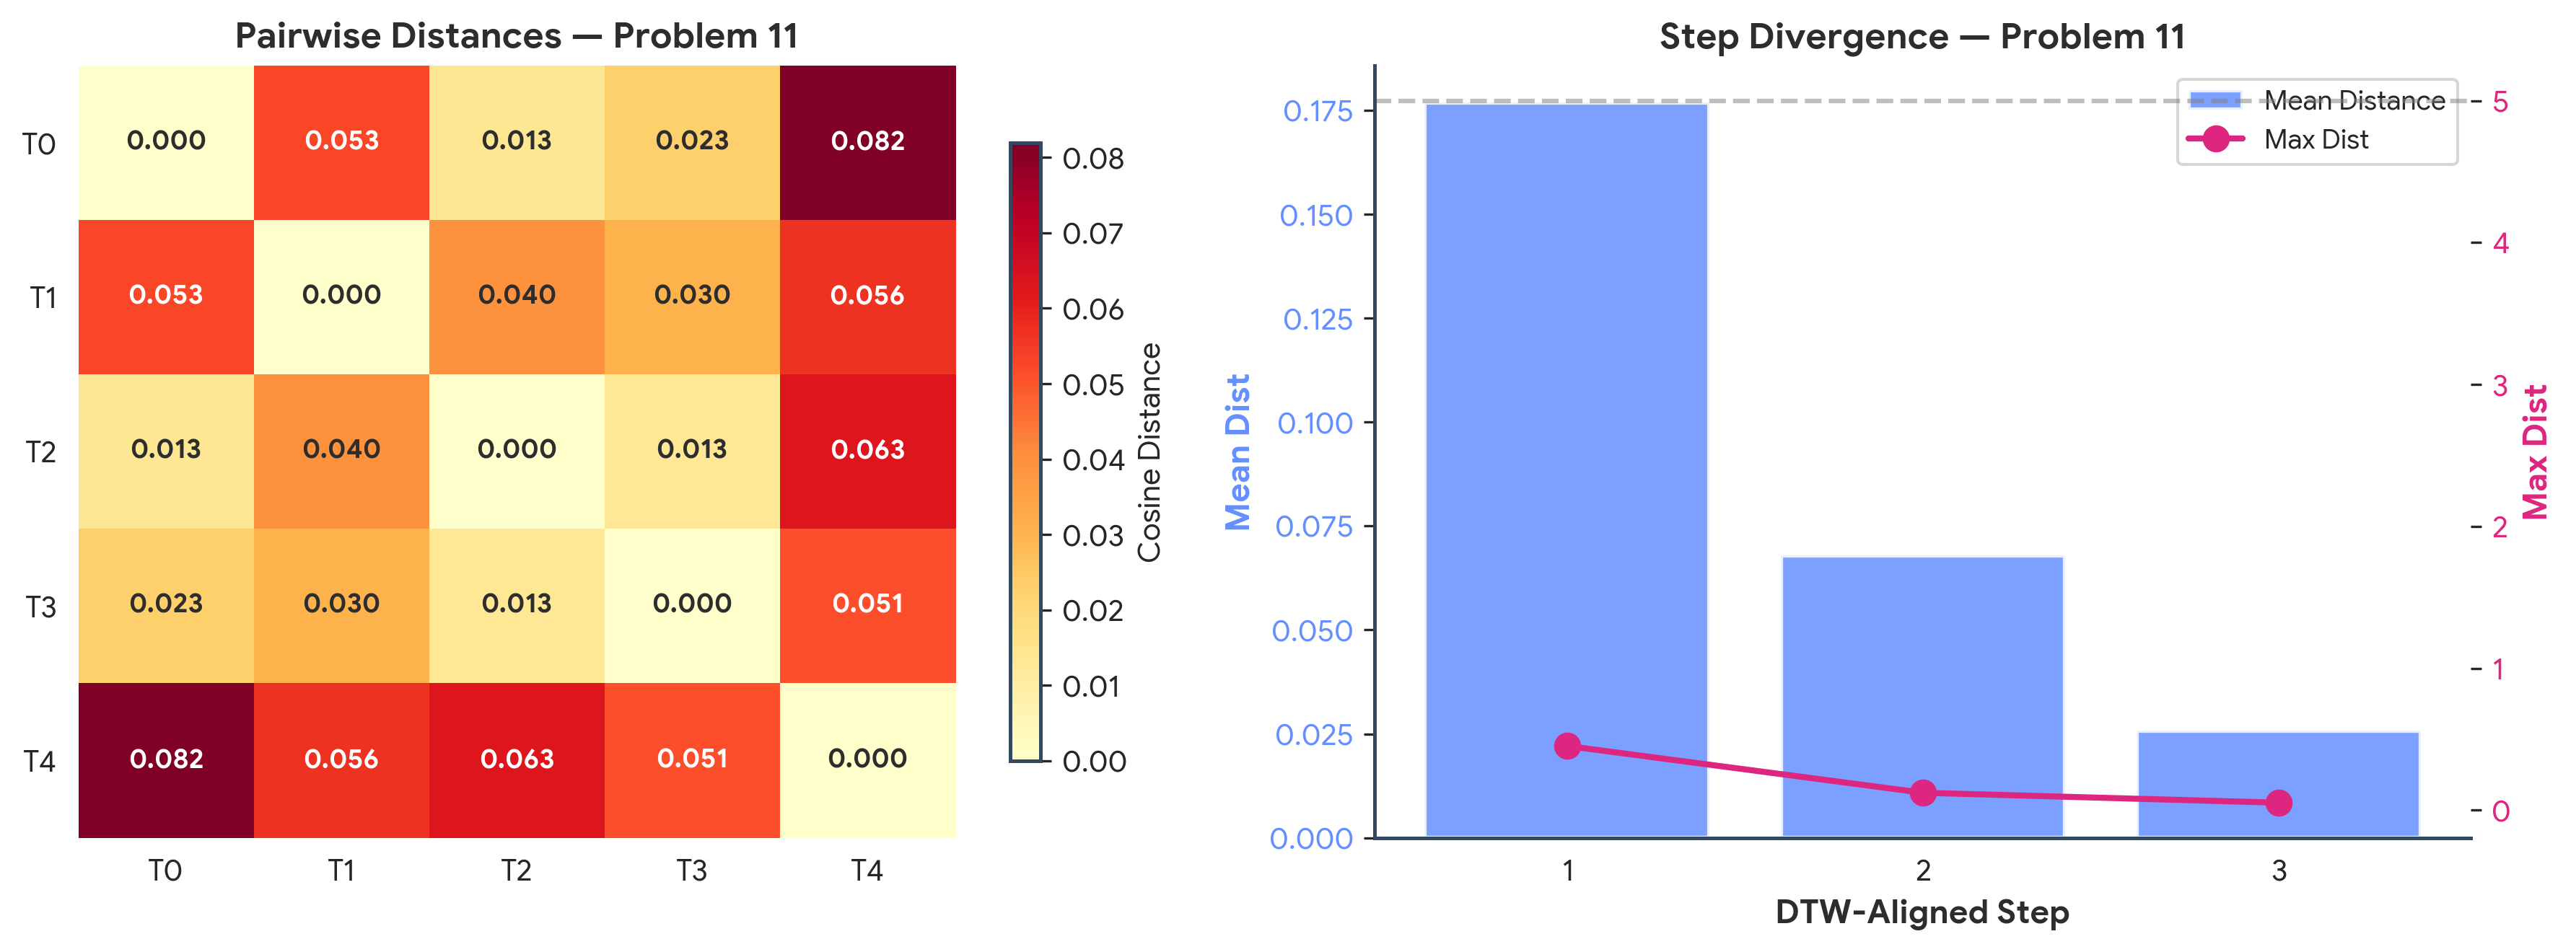

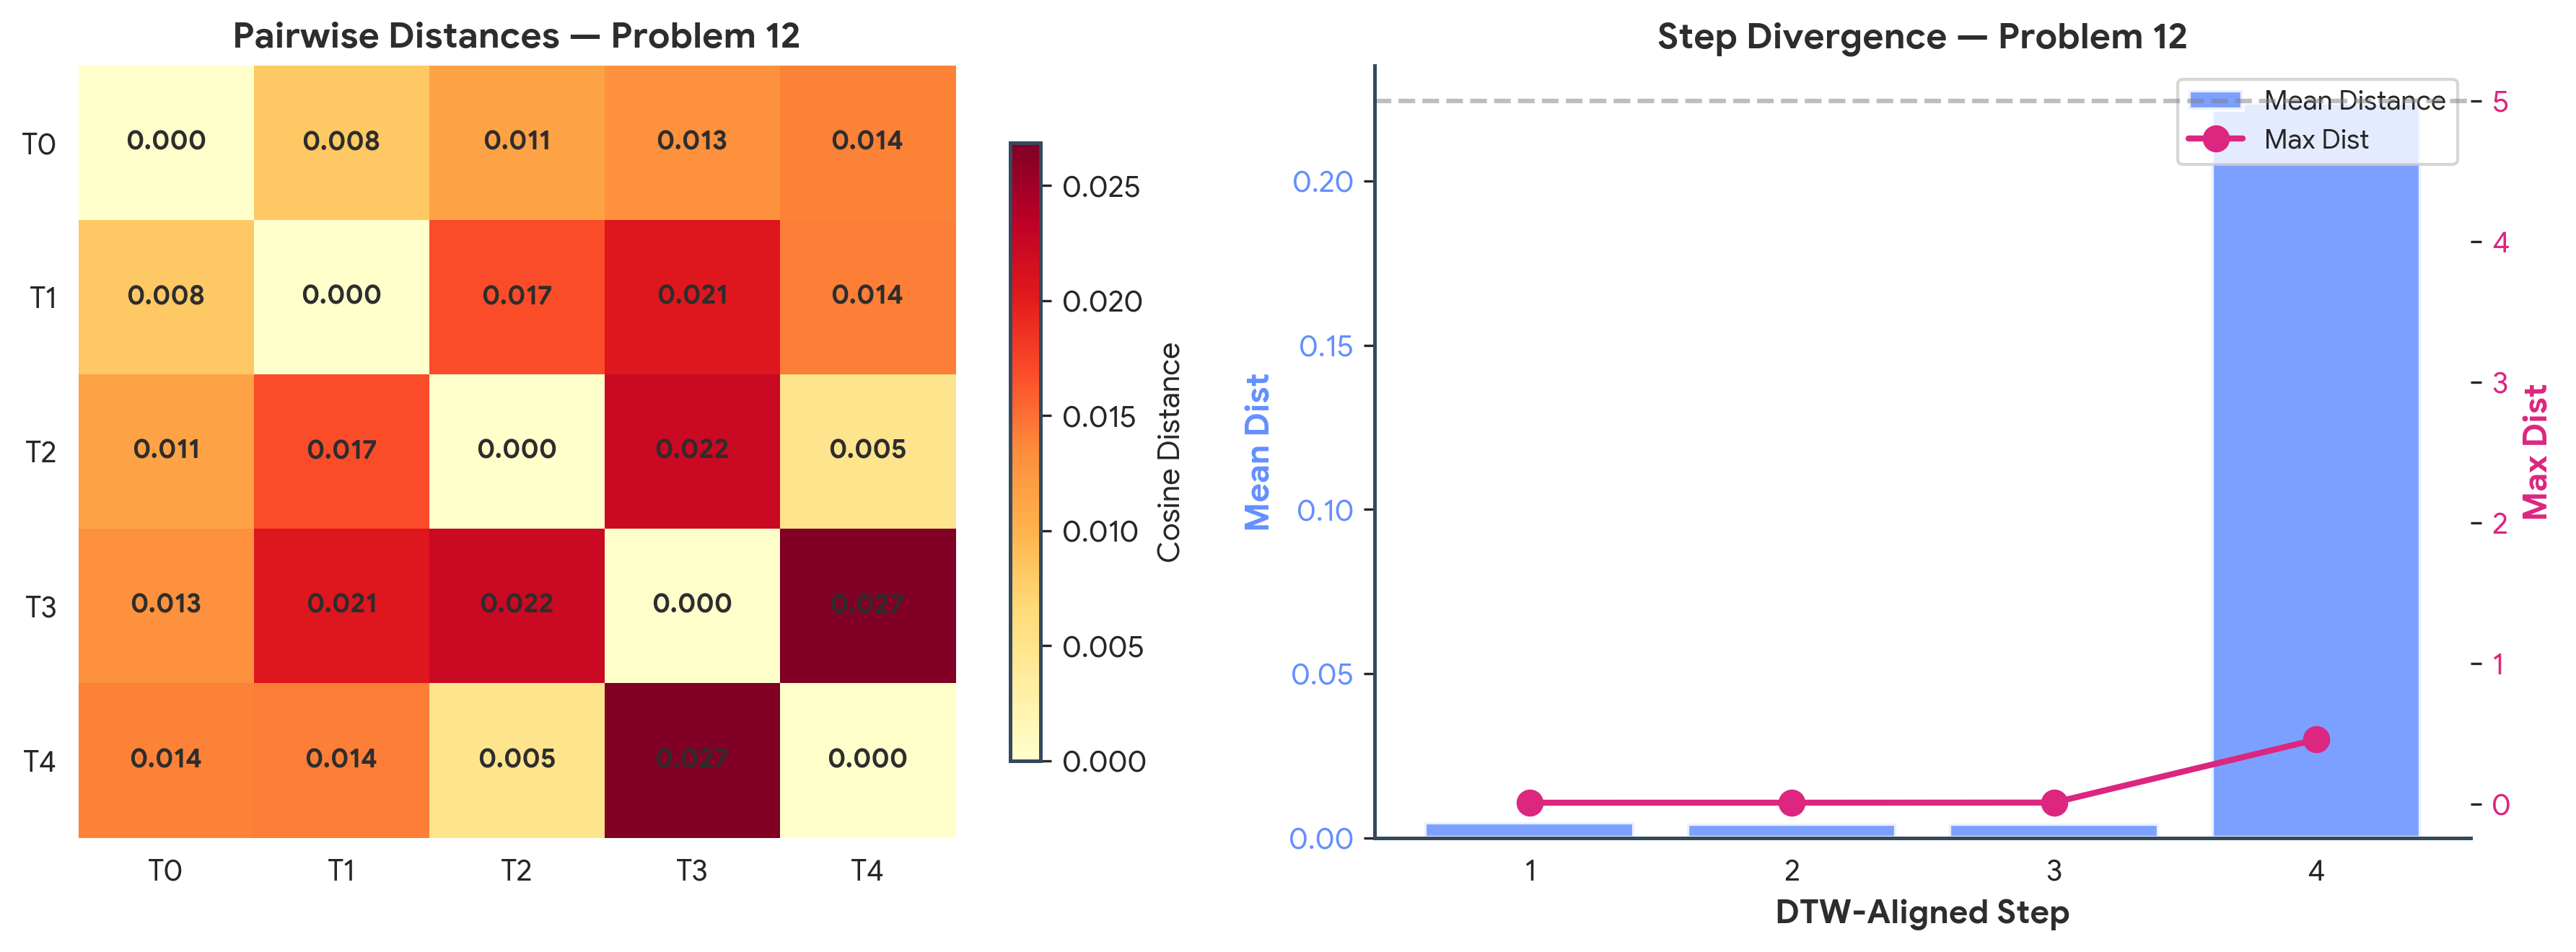

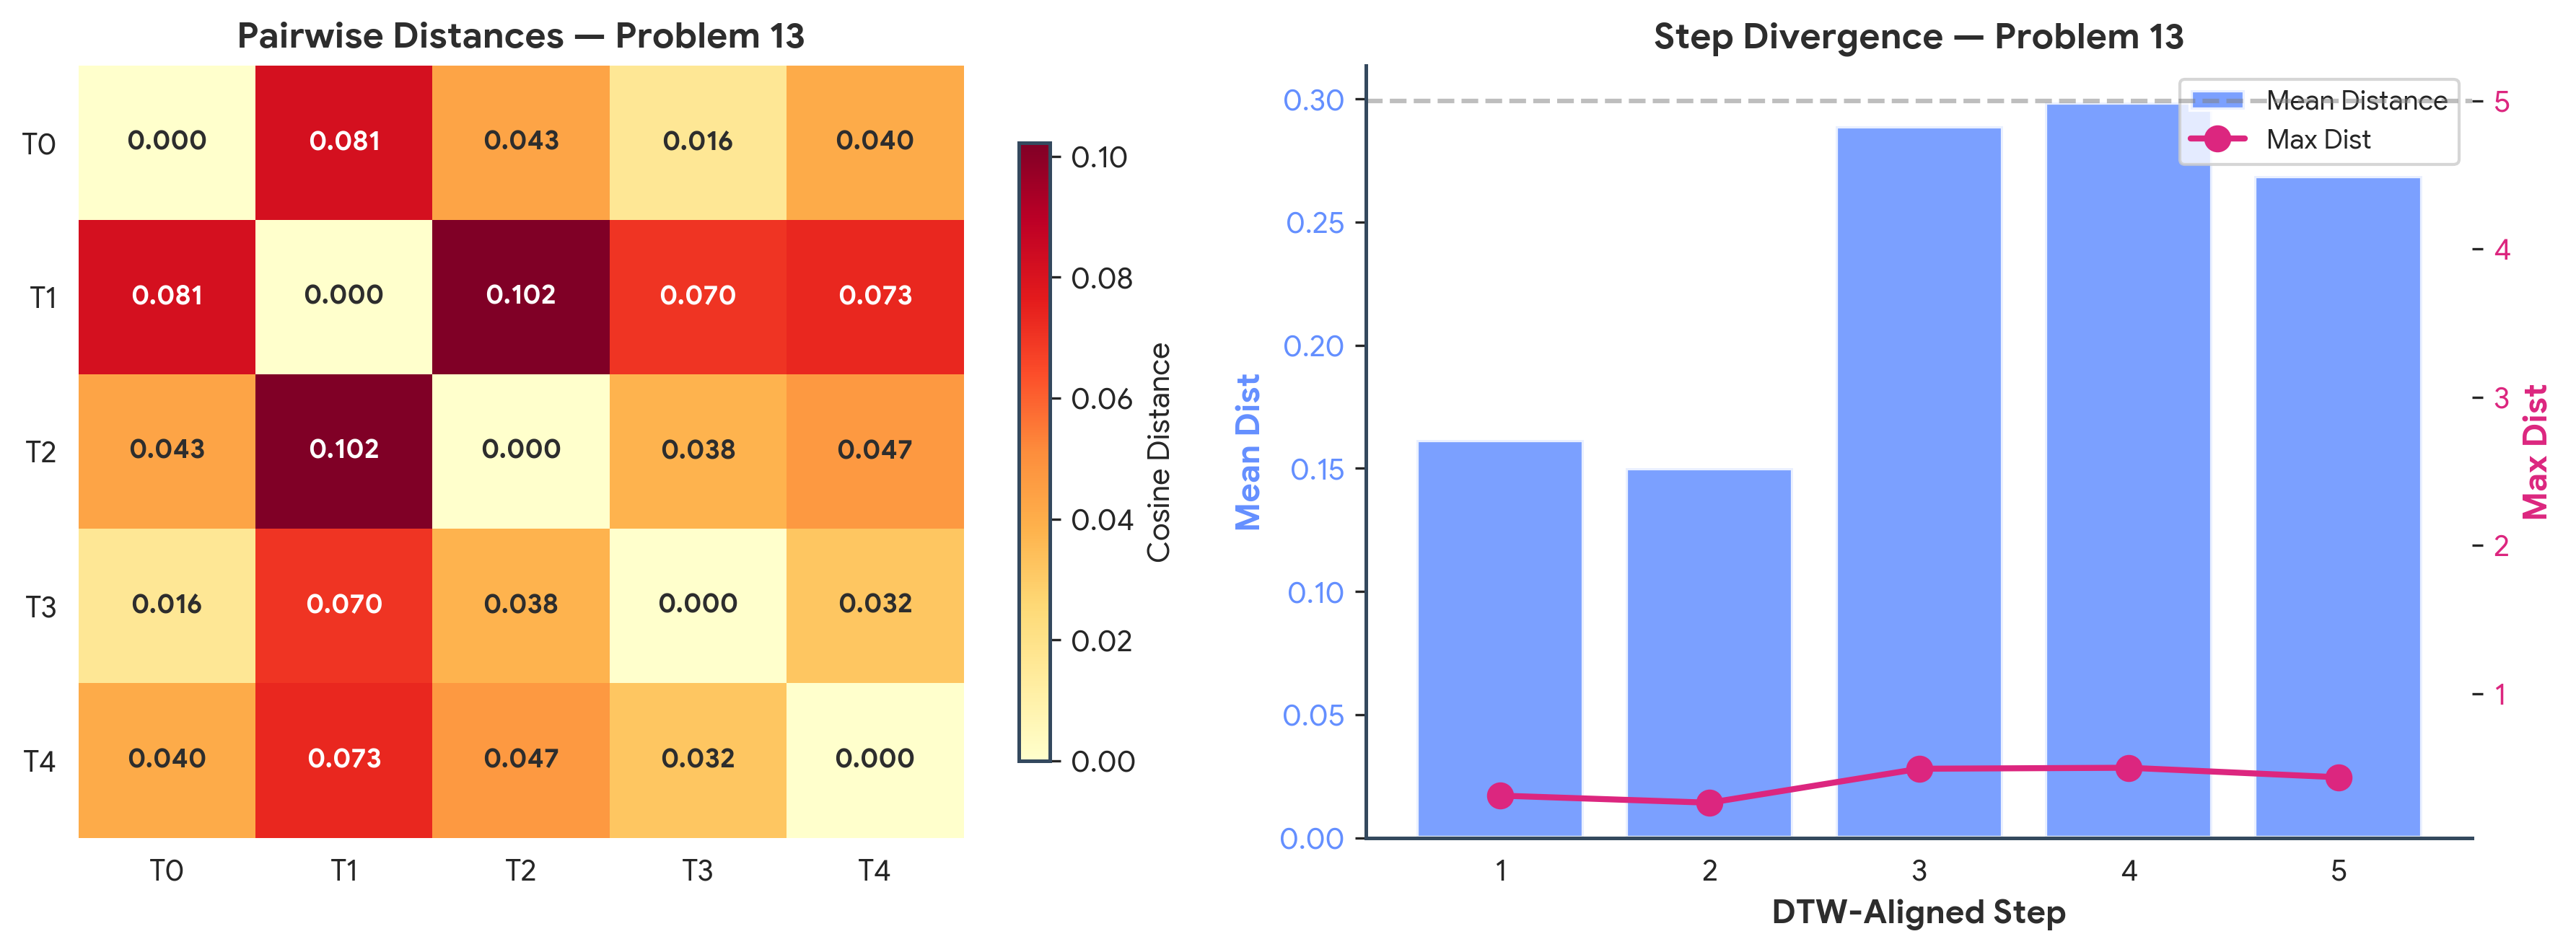

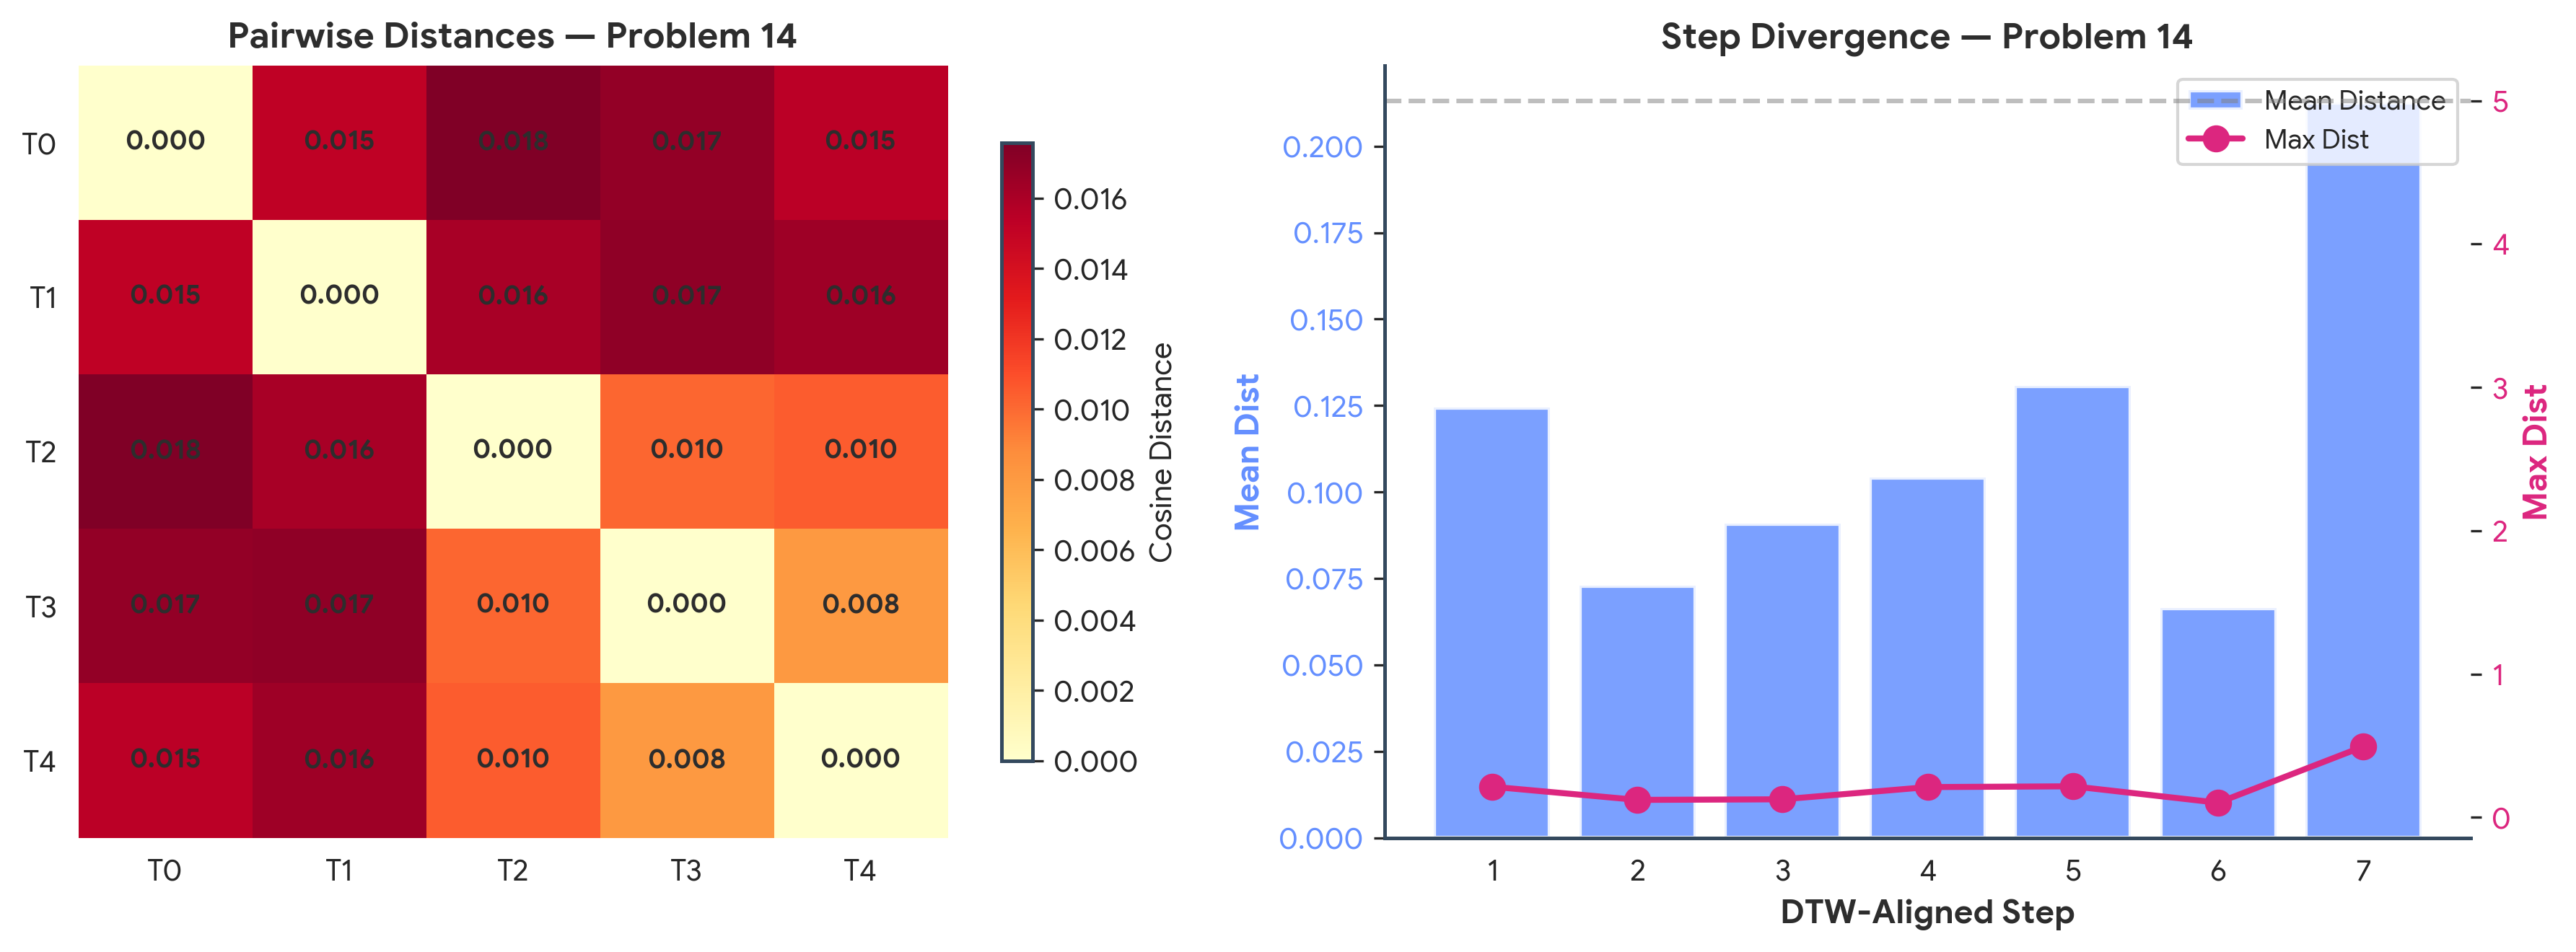

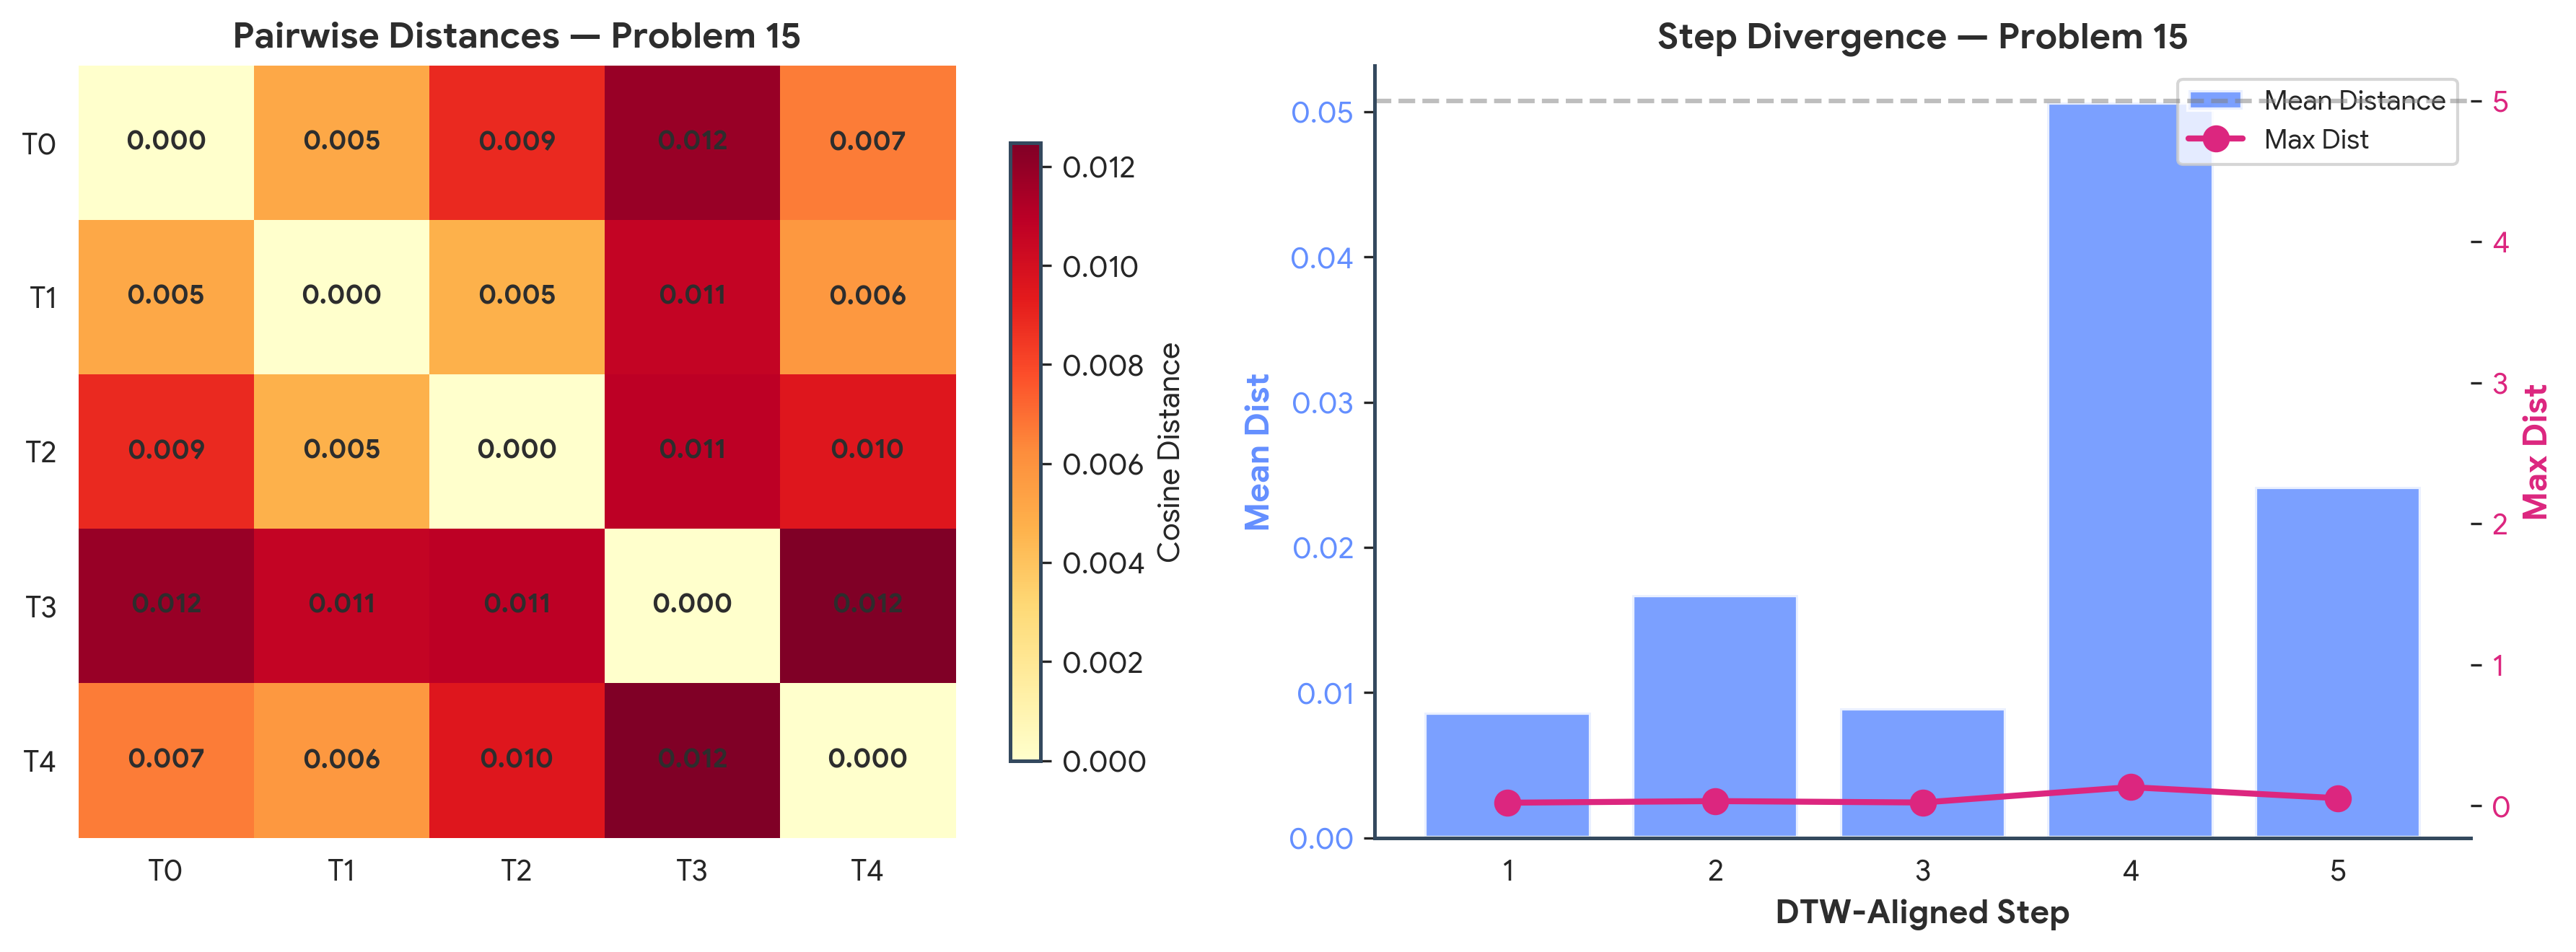

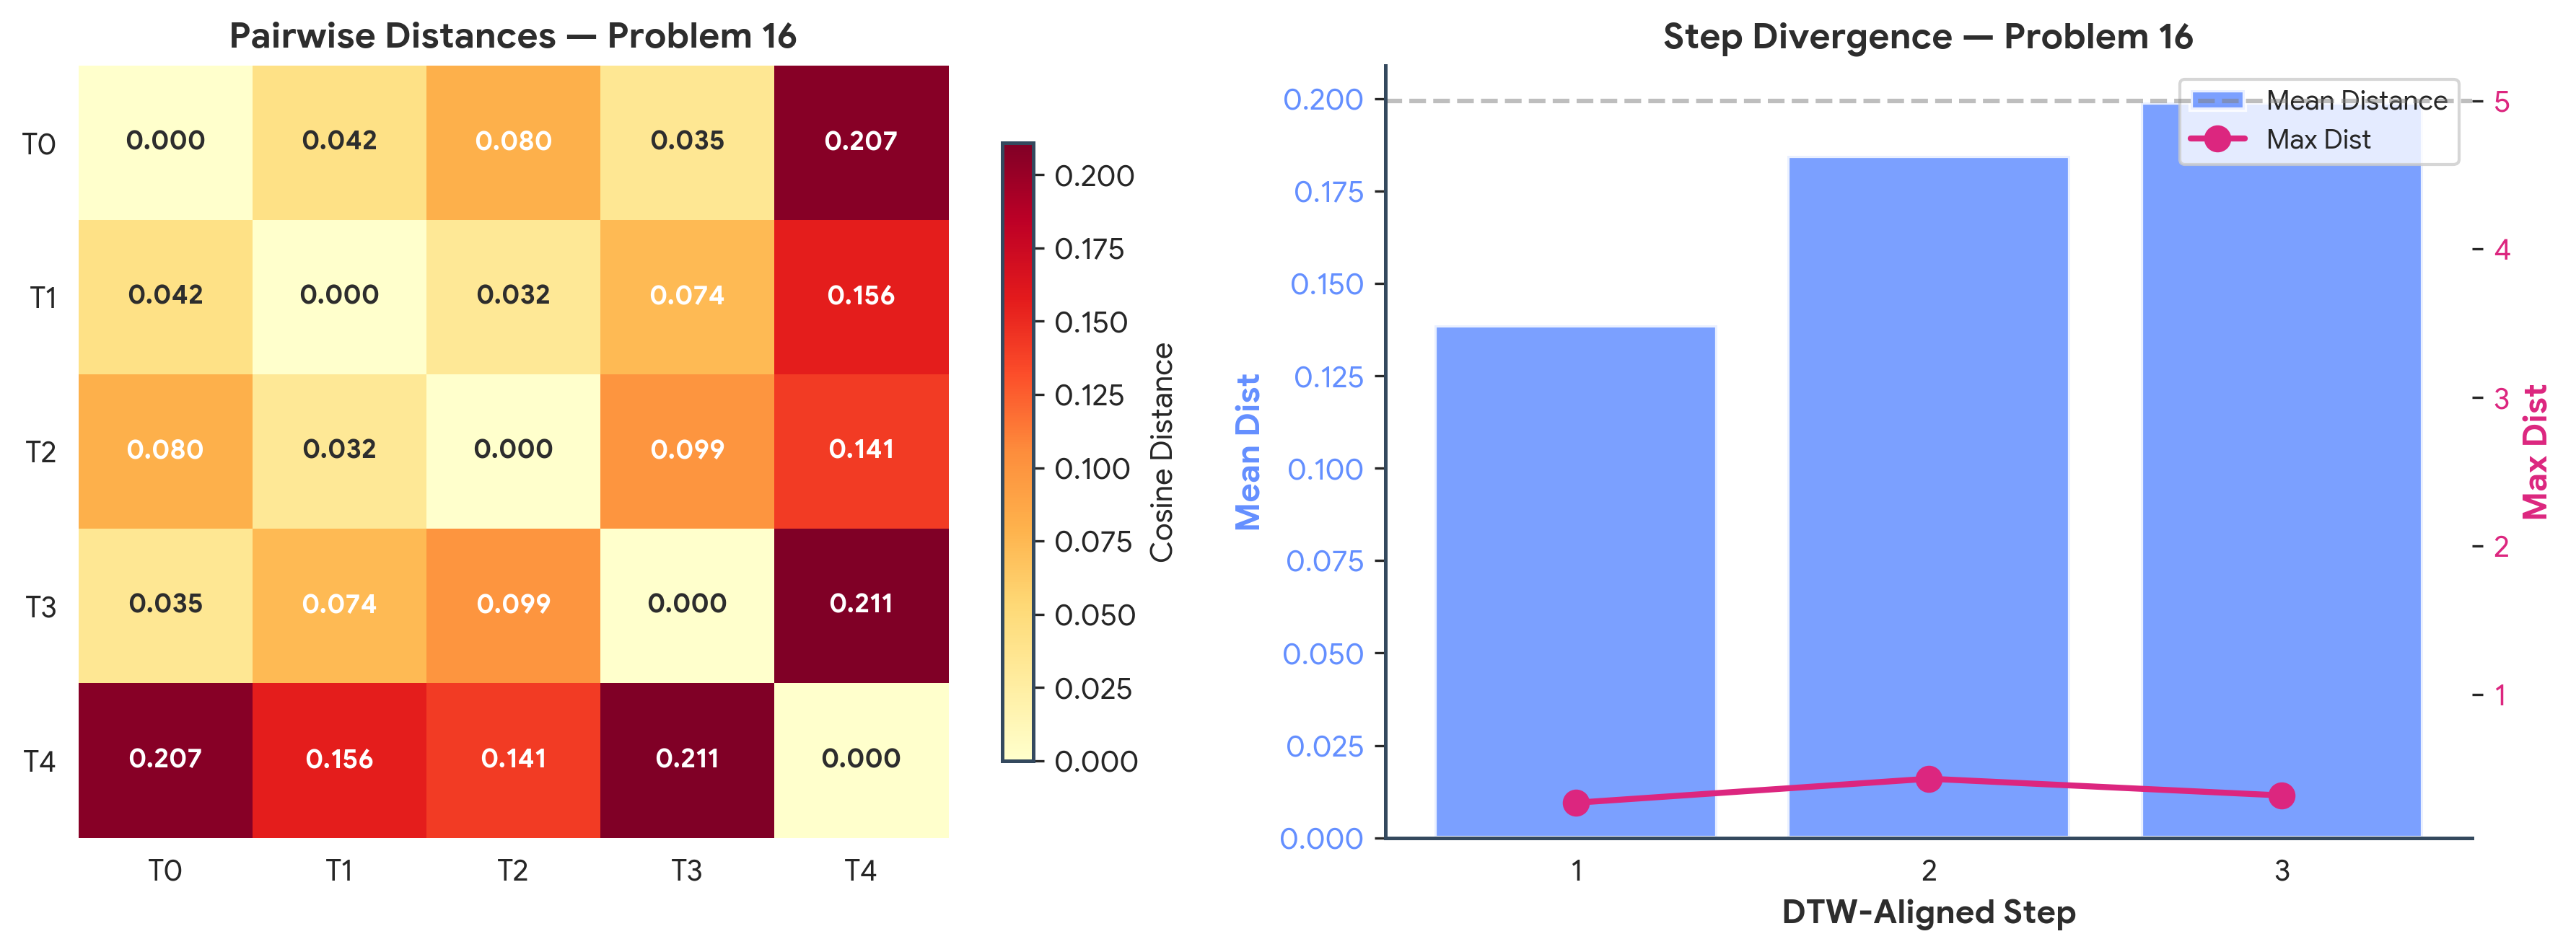

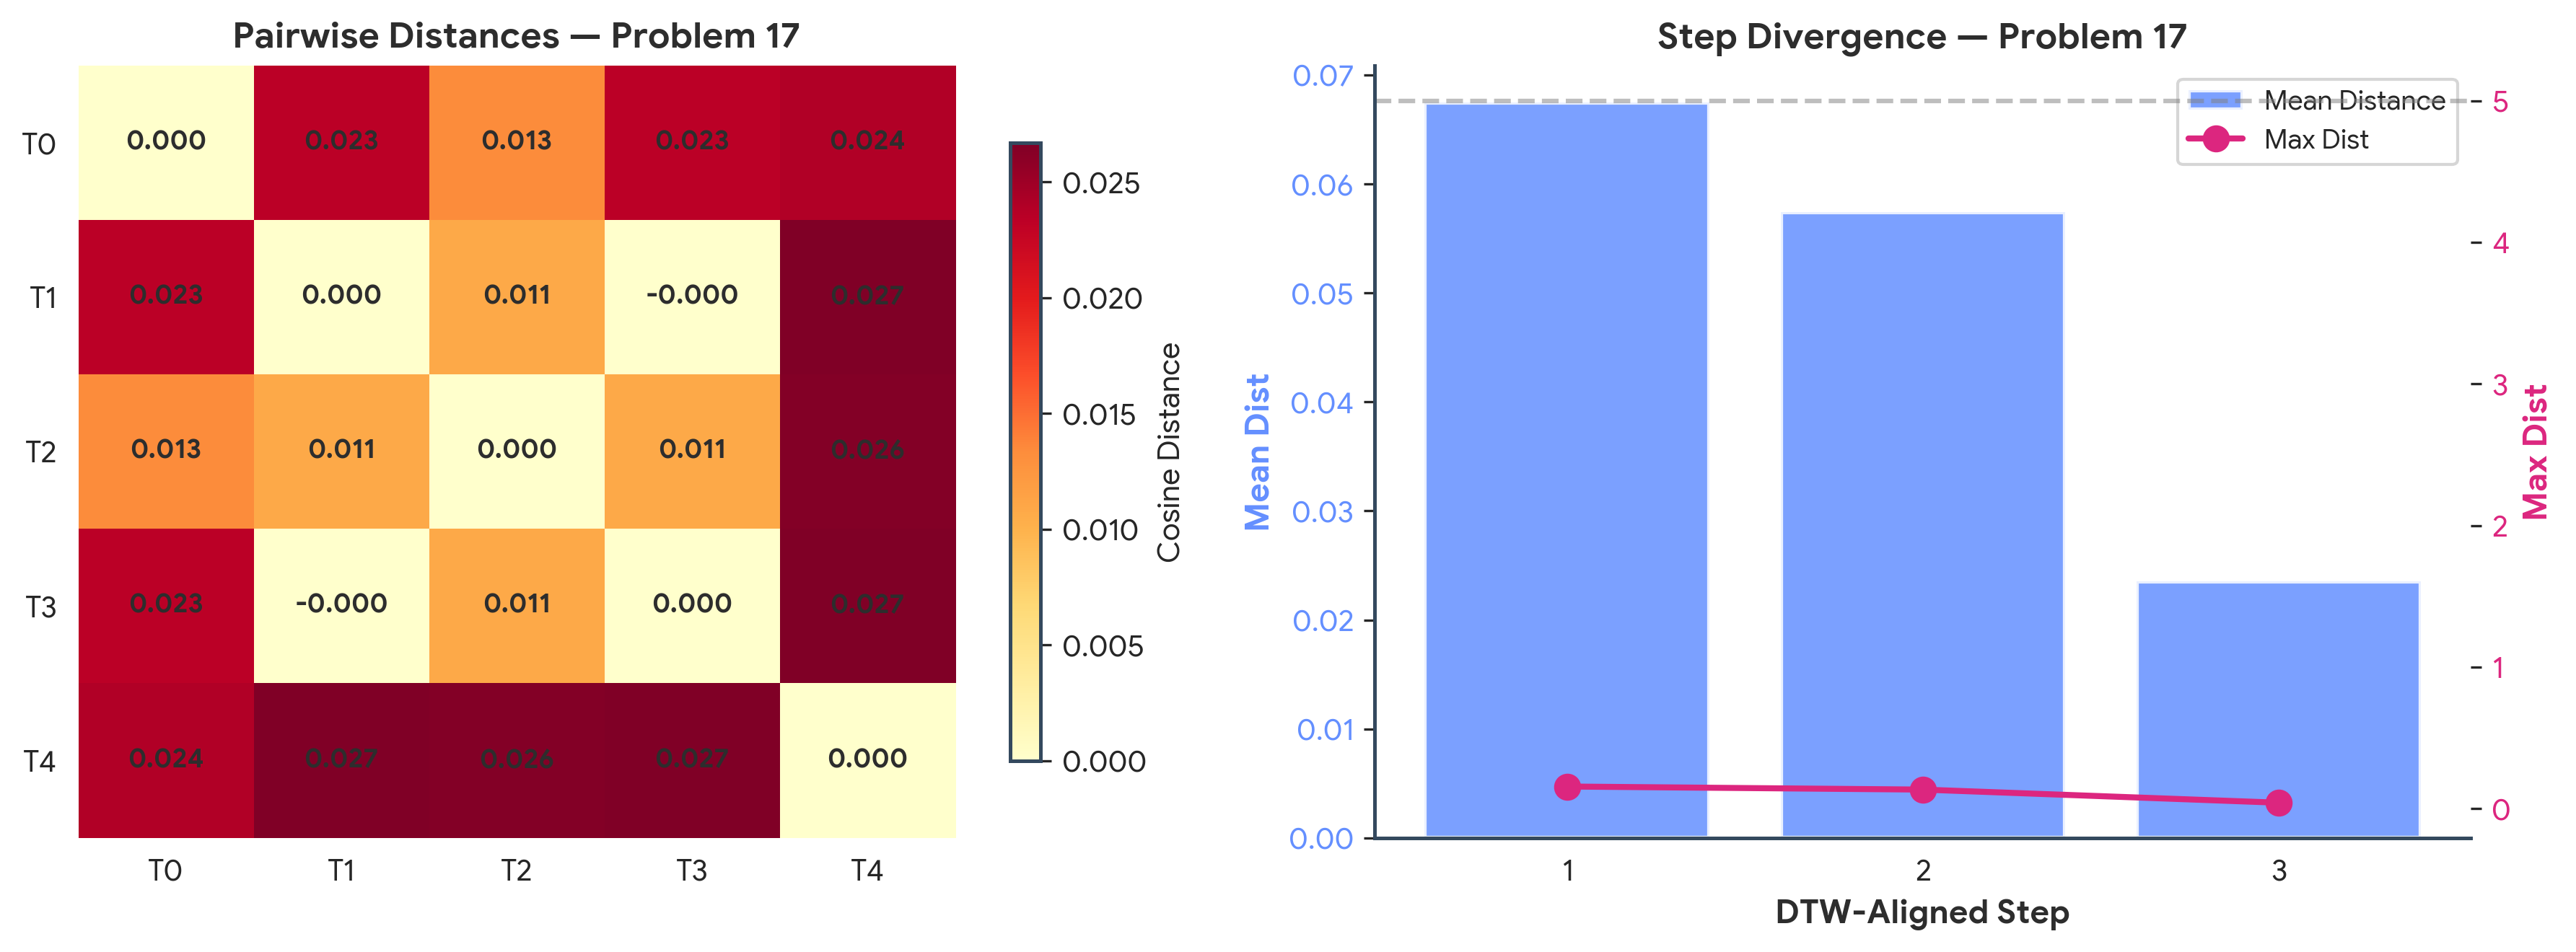

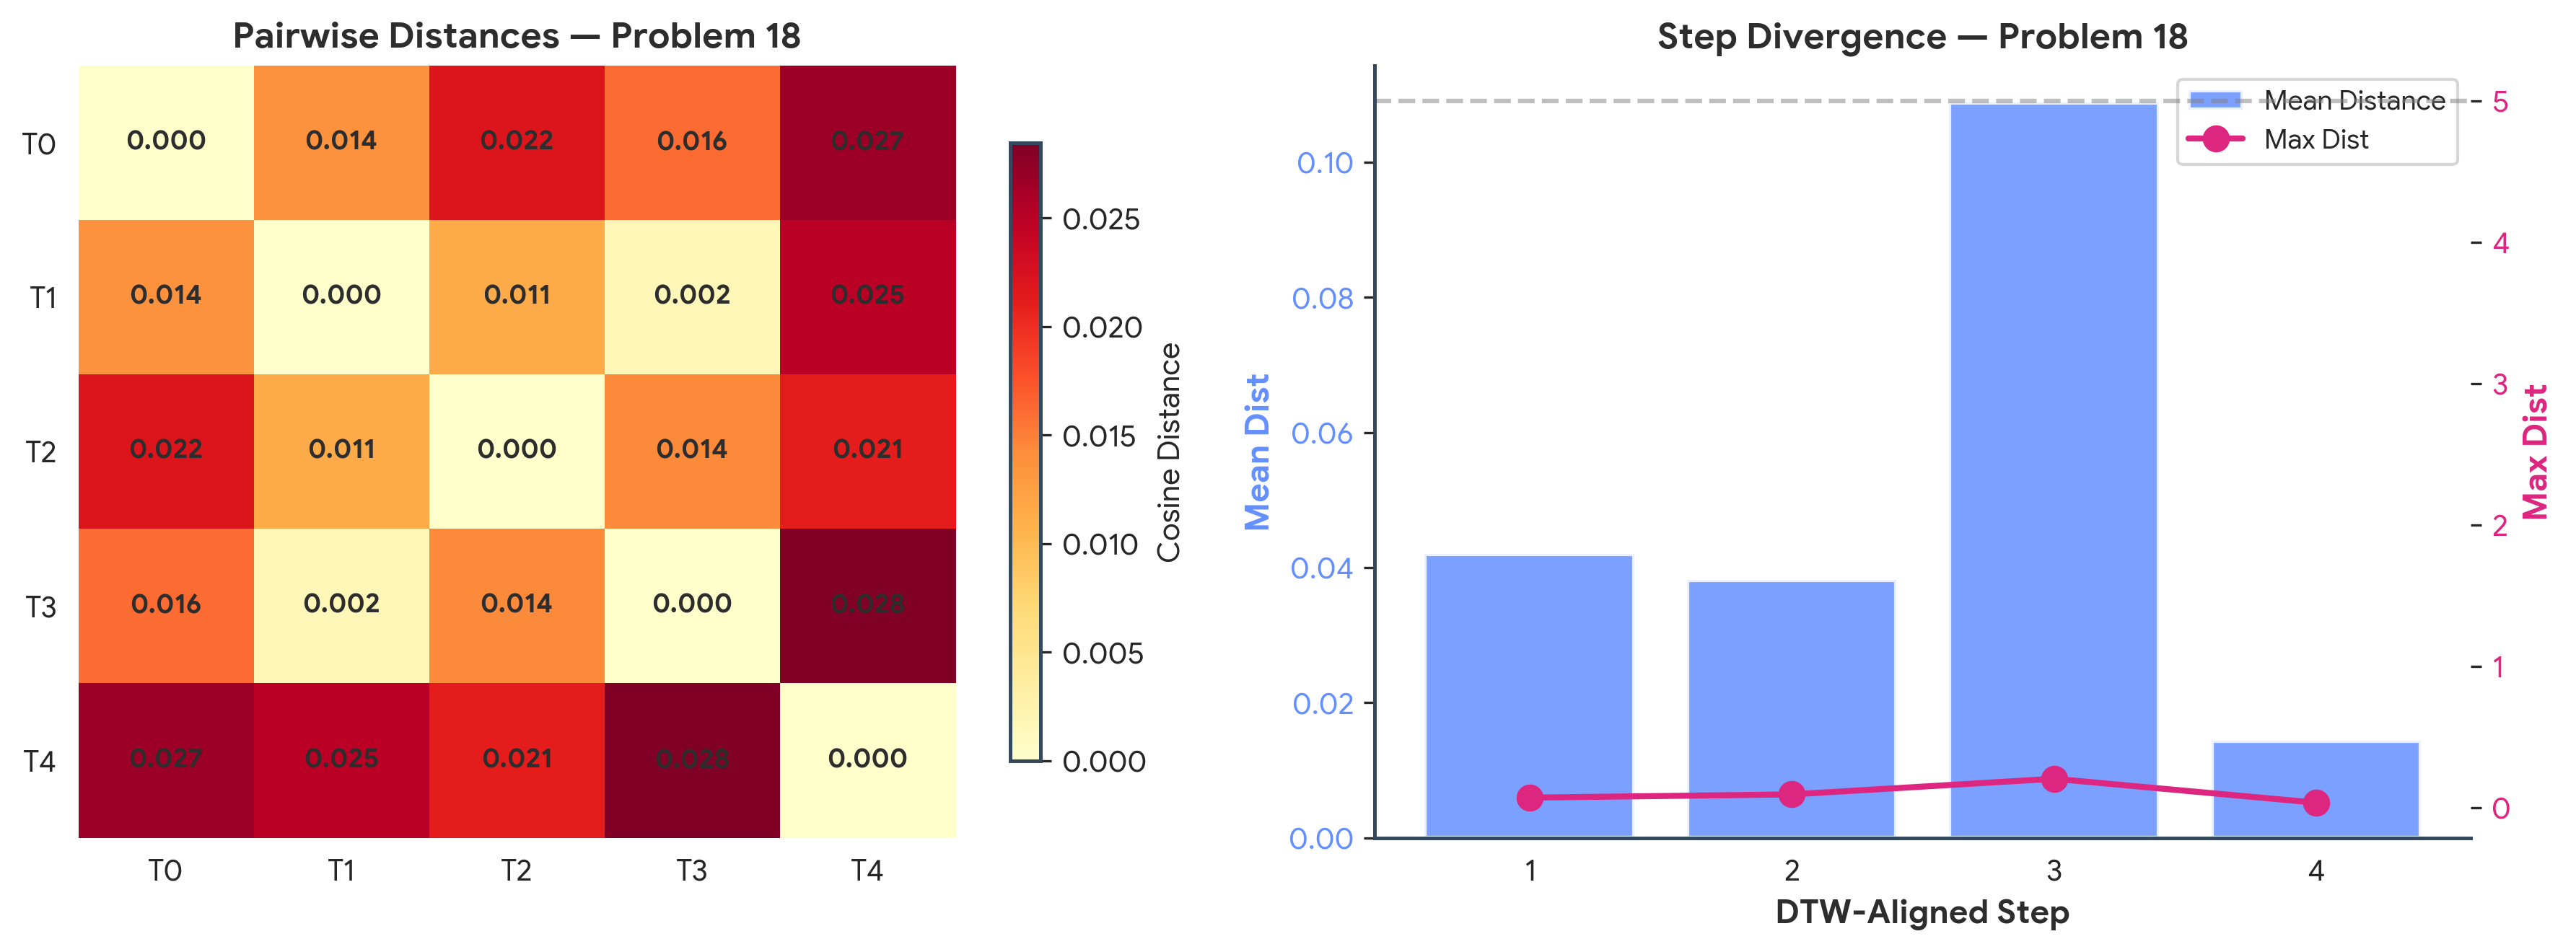

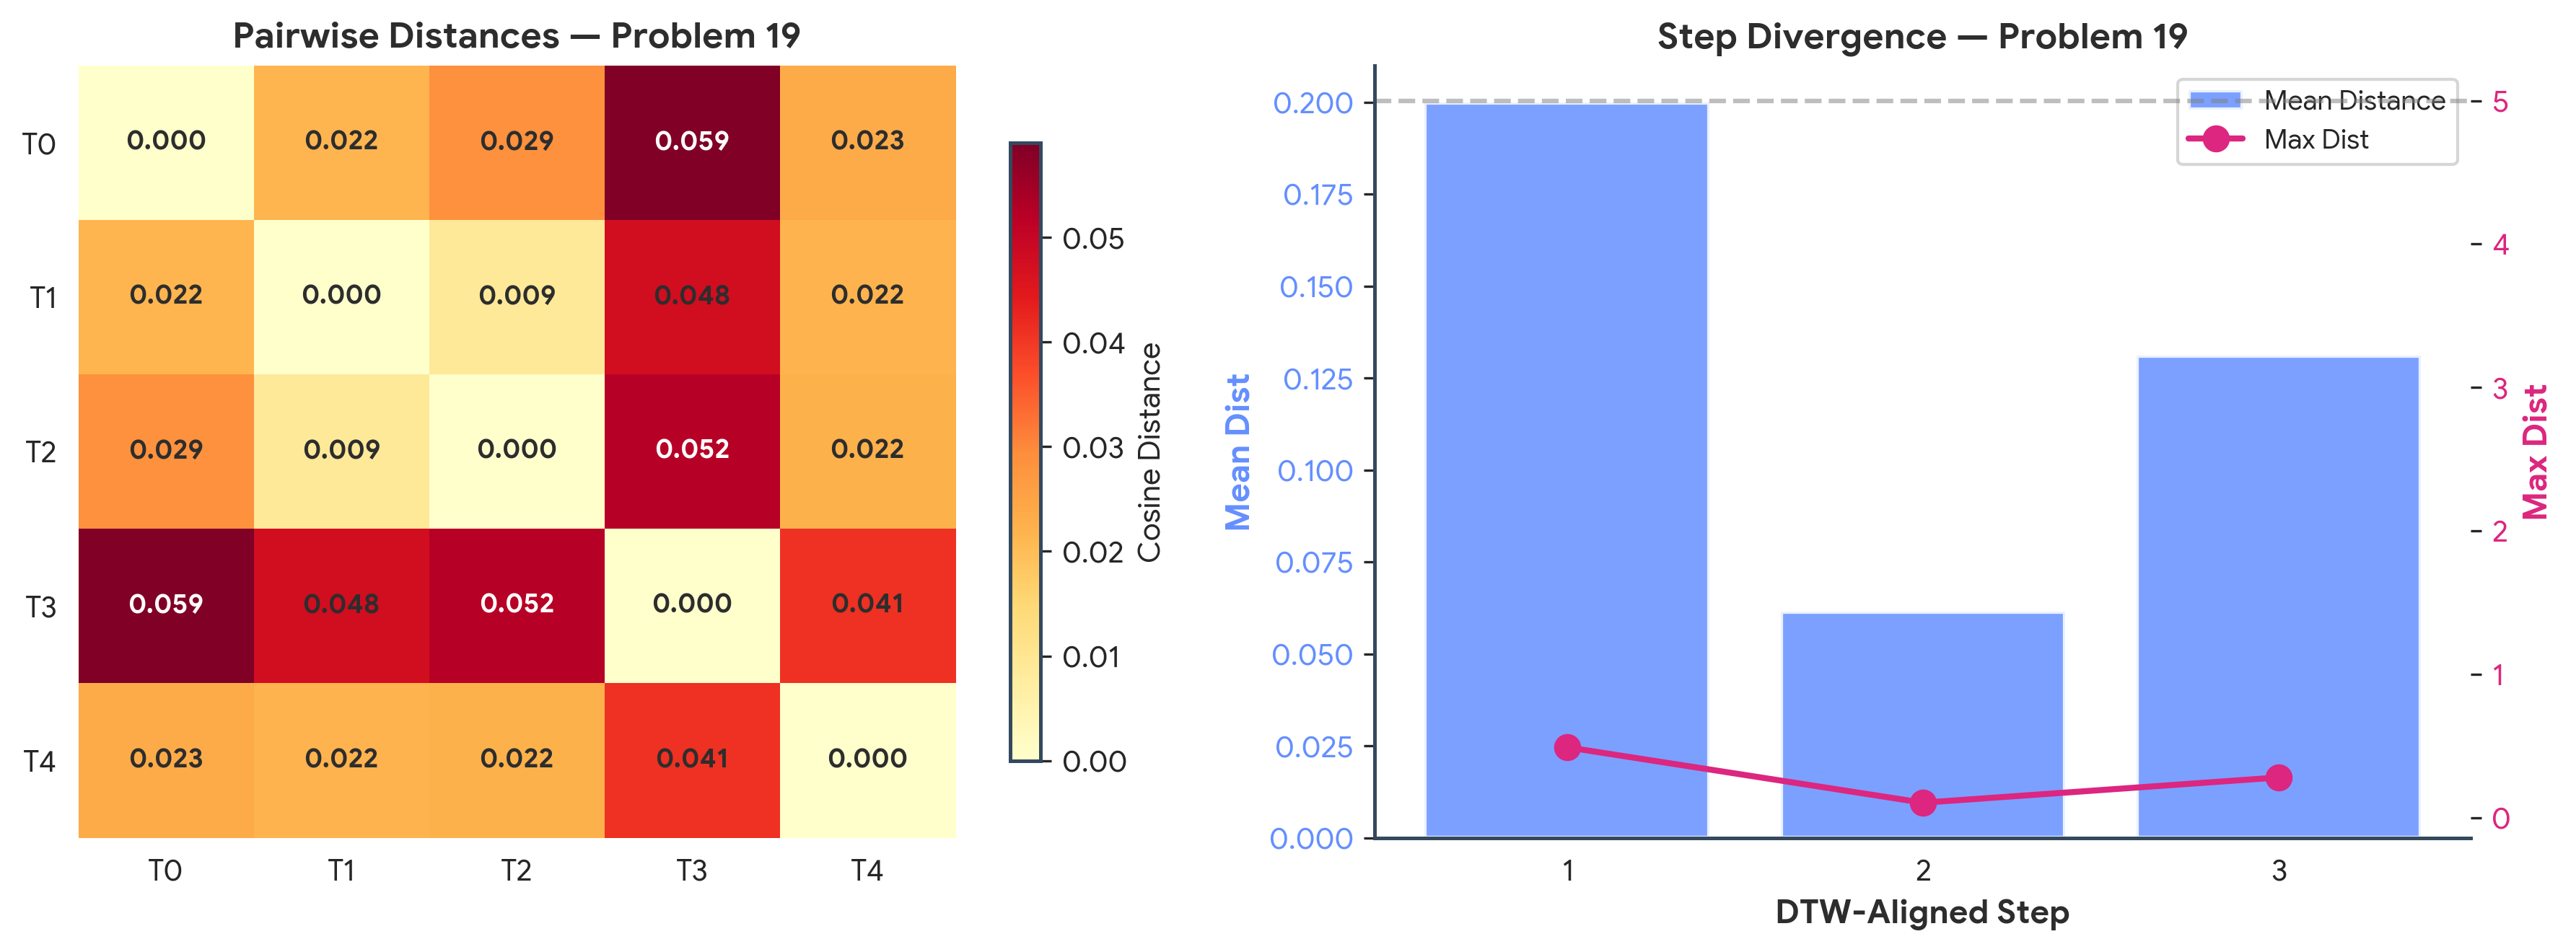

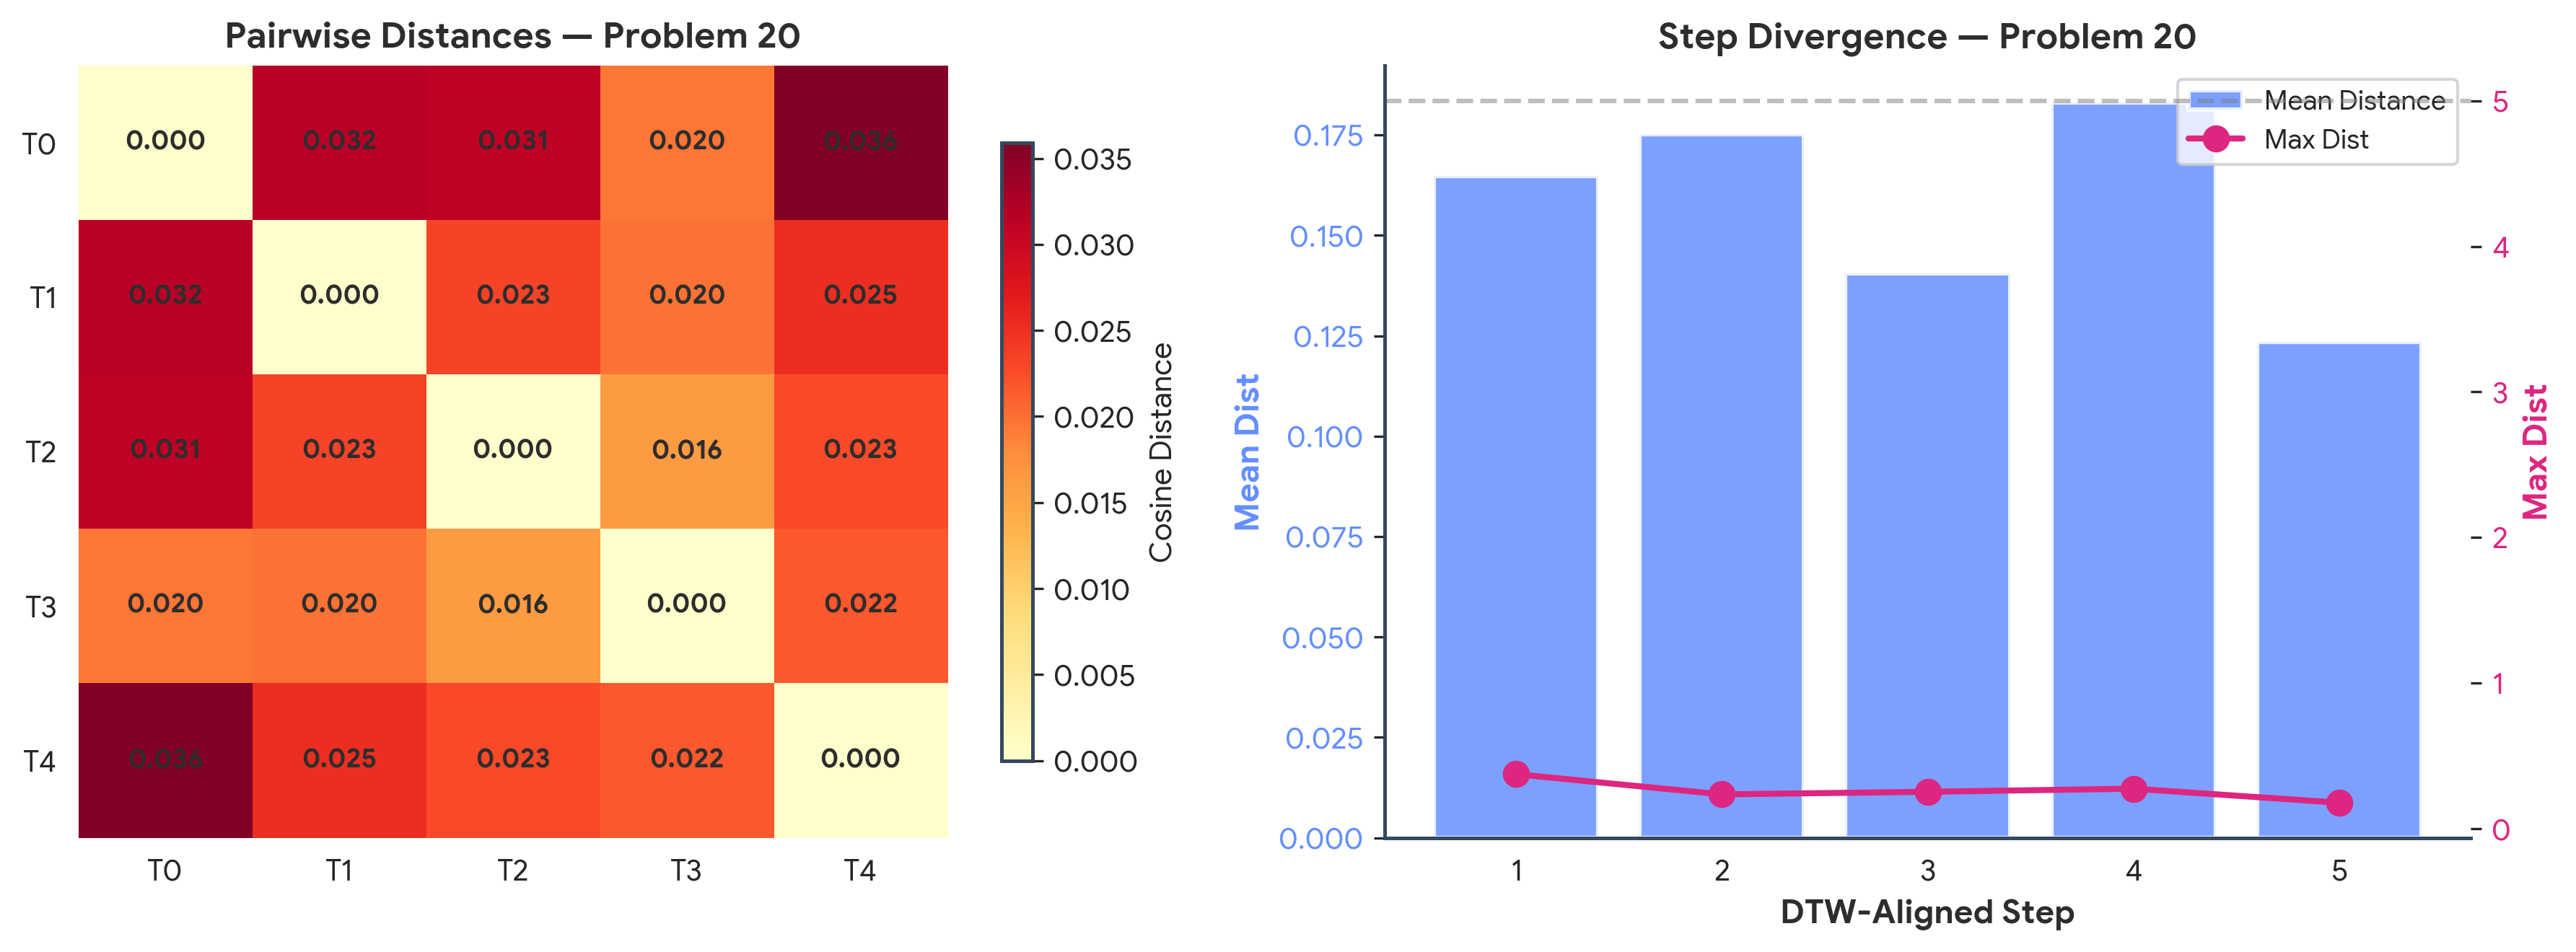

In [21]:
# =============================================================================
# DETAILED STEP ANALYSIS (OPTIONAL)
# =============================================================================
# This cell provides more detailed step-by-step analysis for deep-dives.
# The main paper figures are in the cells above.

def detailed_step_analysis(result, problem_idx):
    """
    Detailed view combining heatmap with step entropy and cluster count.
    Use for appendix or supplementary material.
    """
    emb = result.get('embedding_results')
    if emb is None:
        return None
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=300)
    
    # Left: Heatmap (smaller version)
    dist_matrix = emb.pairwise_distance_matrix
    if dist_matrix is not None:
        im = axes[0].imshow(dist_matrix, cmap=HEATMAP_CMAP, aspect='auto')
        n = len(dist_matrix)
        axes[0].set_xticks(range(n))
        axes[0].set_yticks(range(n))
        axes[0].set_xticklabels([f'T{i}' for i in range(n)], fontsize=10)
        axes[0].set_yticklabels([f'T{i}' for i in range(n)], fontsize=10)
        for i in range(n):
            for j in range(n):
                val = dist_matrix[i, j]
                color = 'white' if val > 0.05 else COLORS['dark_gray']
                axes[0].text(j, i, f'{val:.3f}', ha='center', va='center', 
                           color=color, fontsize=9, fontweight='bold')
        for spine in axes[0].spines.values():
            spine.set_visible(False)
        cbar = plt.colorbar(im, ax=axes[0], shrink=0.8)
        cbar.set_label('Cosine Distance', fontsize=10)
    axes[0].set_title(f'Pairwise Distances — Problem {problem_idx + 1}', 
                     fontsize=12, fontweight='bold', color=COLORS['dark_gray'])
    
    # Right: Mean Distance + Clusters dual axis
    ax2 = axes[1]
    steps = list(range(1, len(emb.step_mean_distances) + 1))
    
    bars = ax2.bar(steps, emb.step_mean_distances, color=COLORS['blue'], alpha=0.85,
                   edgecolor='white', linewidth=1.5, label='Mean Distance')
    ax2.set_xlabel('DTW-Aligned Step', fontsize=11, fontweight='bold', color=COLORS['dark_gray'])
    ax2.set_ylabel('Mean Dist', fontsize=11, fontweight='bold', color=COLORS['blue'])
    ax2.tick_params(axis='y', labelcolor=COLORS['blue'])
    
    # Secondary axis for clusters
    ax2_twin = ax2.twinx()
    ax2_twin.plot(steps, emb.step_max_distances, 'o-', color=COLORS['magenta'], 
                  linewidth=2, markersize=8, label='Max Dist')
    ax2_twin.set_ylabel('Max Dist', fontsize=11, fontweight='bold', color=COLORS['magenta'])
    ax2_twin.tick_params(axis='y', labelcolor=COLORS['magenta'])
    ax2_twin.axhline(y=len(result['trajectories']), color=COLORS['medium_gray'], 
                     linestyle='--', alpha=0.5)
    
    ax2.set_title(f'Step Divergence — Problem {problem_idx + 1}', 
                 fontsize=12, fontweight='bold', color=COLORS['dark_gray'])
    ax2.set_xticks(steps)
    
    # Combined legend
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
    
    plt.tight_layout()
    return fig


# Generate detailed analysis for each problem (optional - can comment out)
print("\n" + "="*60)
print("  Detailed Step Analysis (Supplementary)")
print("="*60)
for idx in range(len(all_results)):
    result = all_results[idx]
    problem_idx = result.get('dataset_idx', idx)  # Use original dataset index
    fig = detailed_step_analysis(result, problem_idx)
    if fig:
        plt.show()


## 14. Cross-Pipeline Correlation Analysis

### Do the Pipelines Agree?

Compare uncertainty signals from both pipelines:
- **Embedding Distance vs LLM Divergence**: Do semantically different trajectories also have high LLM-assessed divergence?
- **Step Entropy vs Stage Divergence**: Does local embedding uncertainty match LLM stage assessments?
- **Distance vs Quality**: Do high-uncertainty problems have lower quality trajectories?

### Interpreting Correlation
- **Strong positive (r > 0.7)**: Pipelines agree on uncertainty
- **Weak (|r| < 0.4)**: Pipelines capture different uncertainty aspects
- **Negative**: Pipelines disagree (worth investigating why)

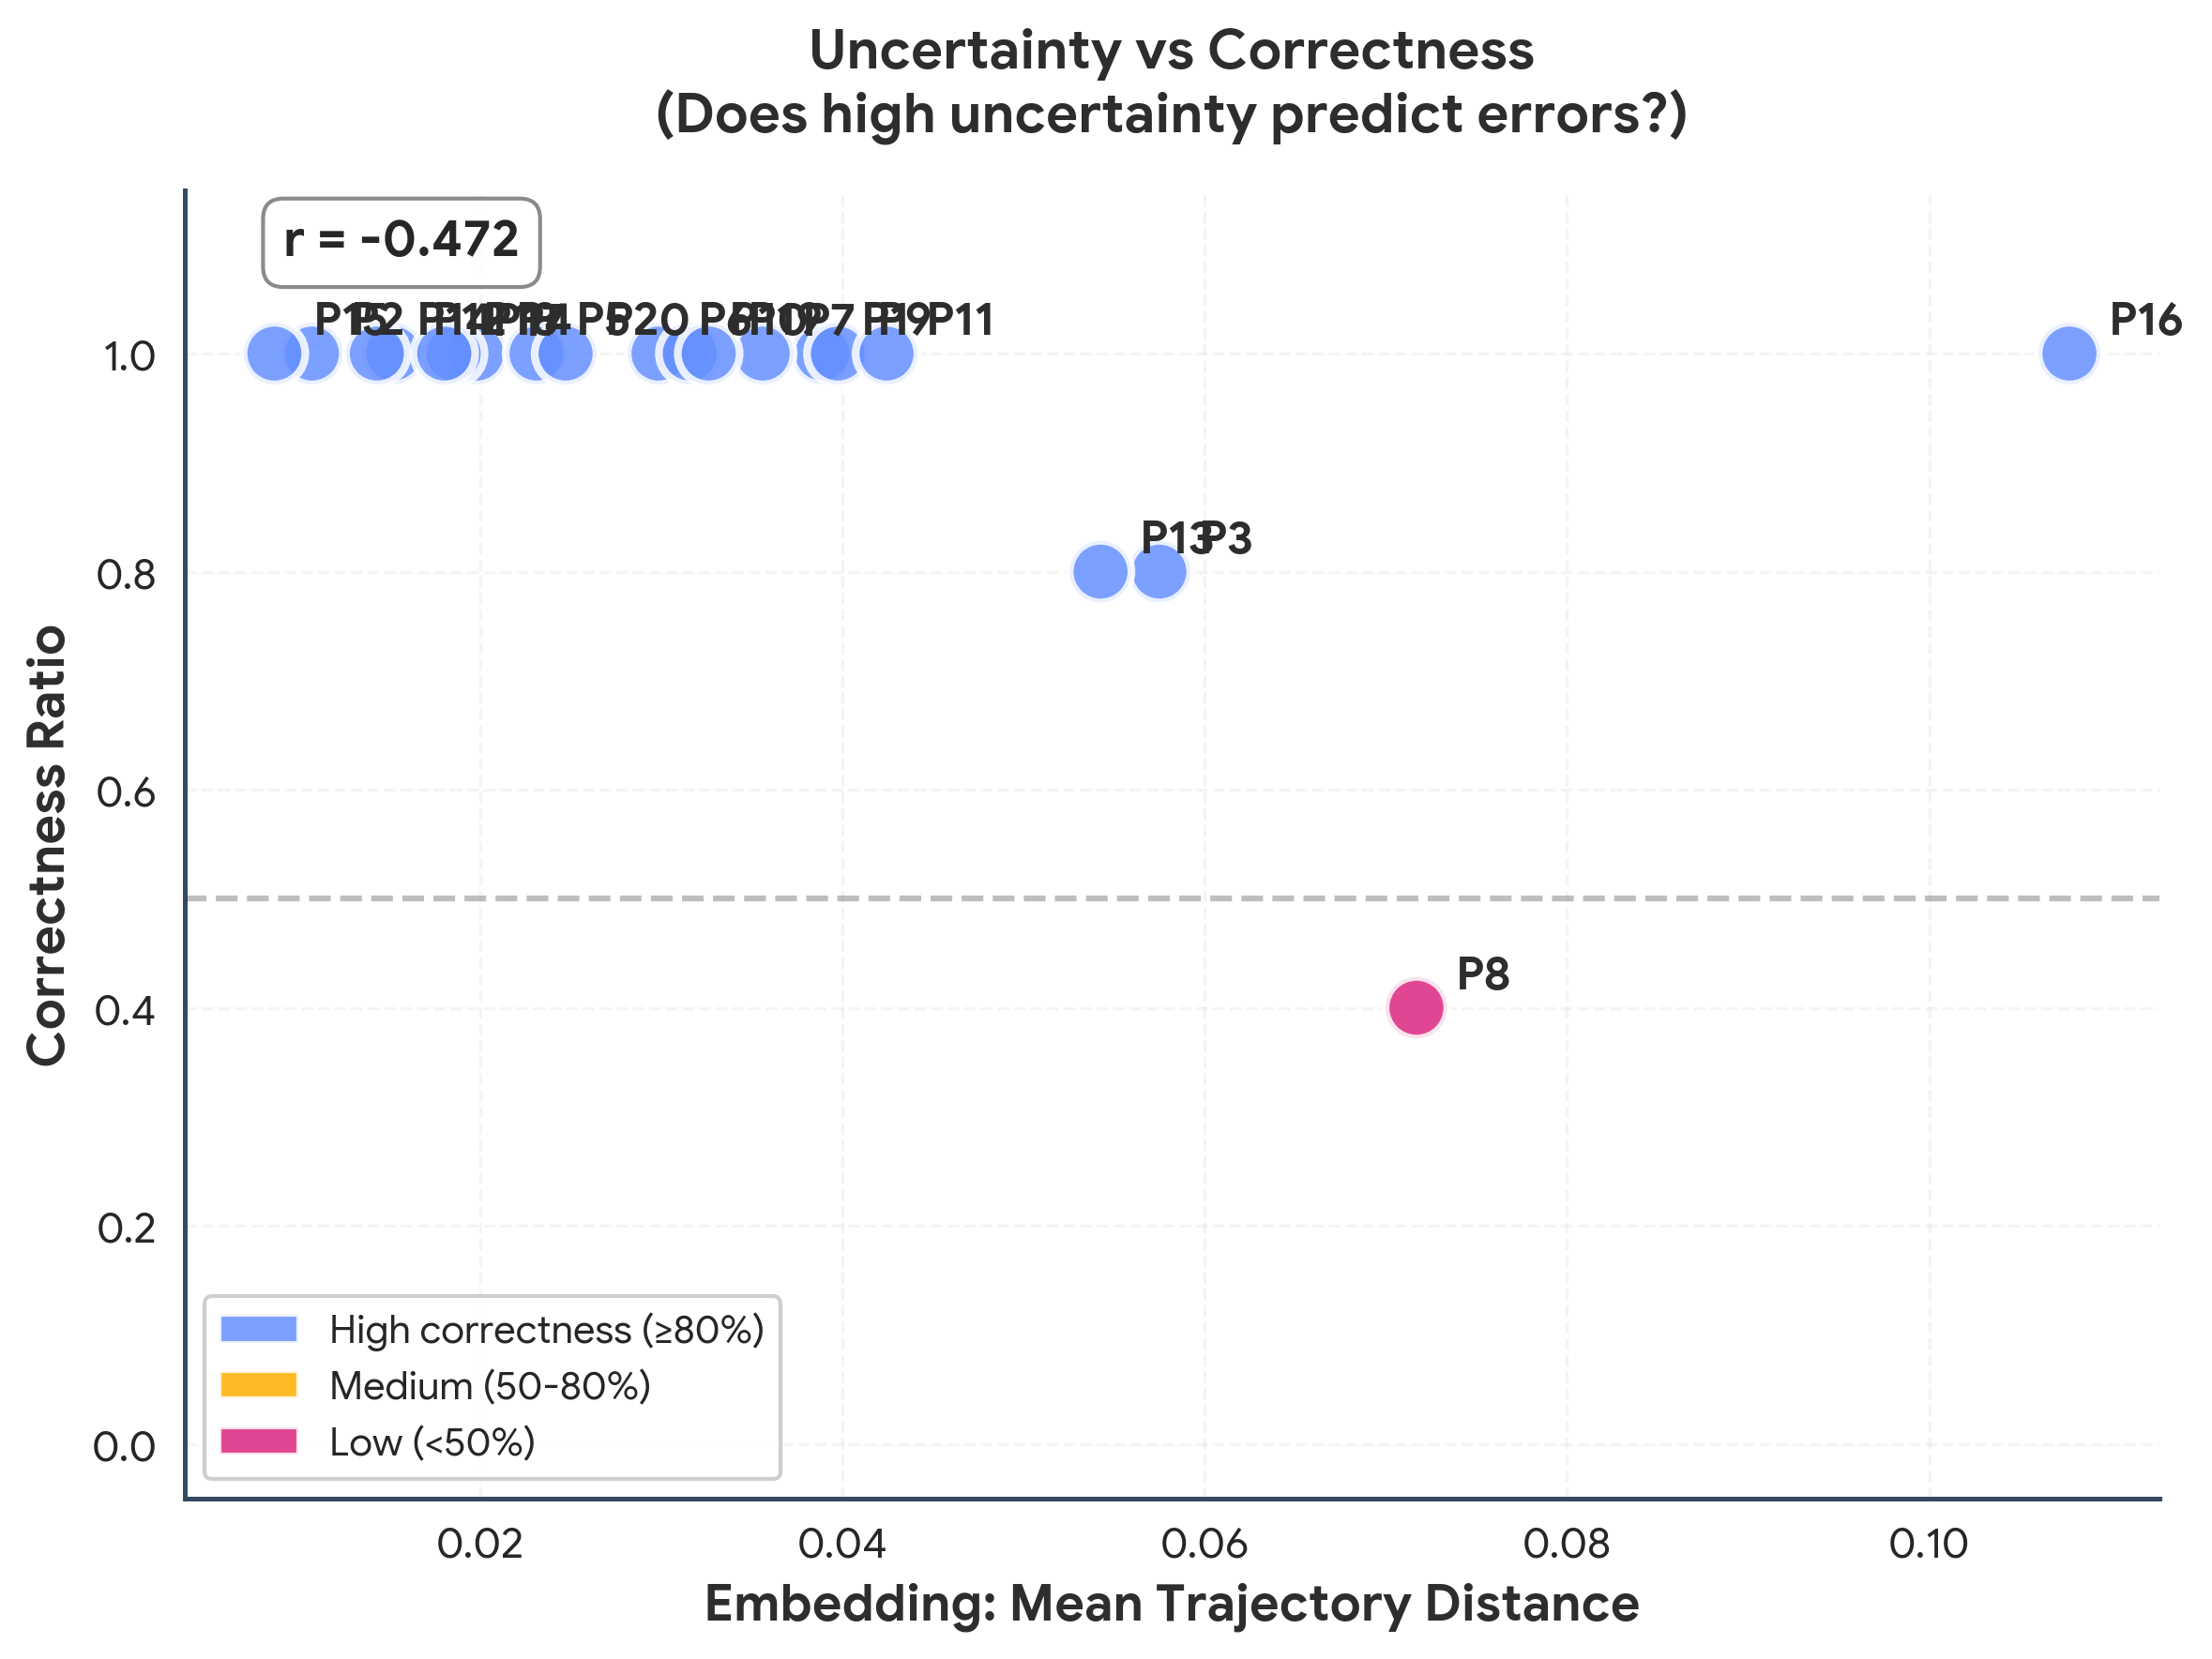

In [22]:
def plot_uncertainty_correlation(all_results):
    """
    Cross-pipeline correlation: Does higher embedding uncertainty correlate 
    with lower correctness? This is the key validation plot.
    
    Simplified to 1 panel showing the relationship between:
    - X: Embedding trajectory distance (semantic uncertainty)
    - Y: Correctness ratio (0-1)
    - Color: By problem
    """
    if len(all_results) < 2:
        print("Need at least 2 problems for correlation analysis")
        return None
    
    # Collect metrics
    emb_traj_dists = []
    correct_ratios = []
    problem_labels = []
    
    for idx, result in enumerate(all_results):
        emb = result.get('embedding_results')
        llm = result.get('llm_results')
        
        if emb is None or llm is None:
            continue
        
        emb_traj_dists.append(emb.traj_mean_distance)
        
        correct = sum(1 for e in llm.trajectory_evaluations.evaluations if e.reaches_correct_answer)
        total = len(llm.trajectory_evaluations.evaluations)
        correct_ratios.append(correct / total if total > 0 else 0)
        problem_labels.append(f'P{idx + 1}')
    
    if len(emb_traj_dists) < 2:
        print("Not enough valid results")
        return None
    
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    
    # Color by correctness ratio
    colors_list = []
    for cr in correct_ratios:
        if cr >= 0.8:
            colors_list.append(COLORS['correct'])  # High correctness = blue
        elif cr >= 0.5:
            colors_list.append(COLORS['yellow'])   # Medium = yellow
        else:
            colors_list.append(COLORS['incorrect']) # Low = magenta
    
    scatter = ax.scatter(emb_traj_dists, correct_ratios, 
                        c=colors_list, s=250, alpha=0.85, 
                        edgecolors='white', linewidth=2)
    
    # Add problem labels
    for i, label in enumerate(problem_labels):
        ax.annotate(label, (emb_traj_dists[i], correct_ratios[i]),
                   textcoords="offset points", xytext=(10, 5), fontsize=12,
                   fontweight='bold', color=COLORS['dark_gray'])
    
    # Add correlation coefficient if meaningful
    if len(emb_traj_dists) >= 3:
        corr = np.corrcoef(emb_traj_dists, correct_ratios)[0, 1]
        if not np.isnan(corr):
            ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, 
                   fontsize=13, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                            alpha=0.9, edgecolor=COLORS['medium_gray']))
    
    ax.set_xlabel('Embedding: Mean Trajectory Distance', fontsize=13, 
                 fontweight='bold', color=COLORS['dark_gray'])
    ax.set_ylabel('Correctness Ratio', fontsize=13, 
                 fontweight='bold', color=COLORS['dark_gray'])
    ax.set_title('Uncertainty vs Correctness\n(Does high uncertainty predict errors?)', 
                fontsize=14, fontweight='bold', color=COLORS['dark_gray'], pad=15)
    
    ax.set_ylim(-0.05, 1.15)
    ax.axhline(y=0.5, color=COLORS['medium_gray'], linestyle='--', 
               linewidth=1.5, alpha=0.5, label='50% correct')
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=COLORS['correct'], label='High correctness (≥80%)', alpha=0.85),
        Patch(facecolor=COLORS['yellow'], label='Medium (50-80%)', alpha=0.85),
        Patch(facecolor=COLORS['incorrect'], label='Low (<50%)', alpha=0.85),
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=10, framealpha=0.95)
    
    ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.8)
    ax.tick_params(axis='both', labelsize=11)
    
    plt.tight_layout()
    return fig


# Generate cross-pipeline comparison
if len(all_results) >= 2:
    fig = plot_uncertainty_correlation(all_results)
    if fig:
        plt.show()


## 14b. Baseline Comparison: Final Answer vs Trajectory-Level Uncertainty

### Why This Comparison Matters

Traditional **semantic entropy** approaches only look at the **final answers**:
1. Generate K responses
2. Extract final answers
3. Cluster by semantic similarity
4. Compute entropy

Our approach adds **trajectory-level** and **step-level** analysis:
- **Trajectory-level**: How different are the full reasoning paths?
- **Step-level**: Where exactly do trajectories diverge?

### Key Insight

The interesting cases are where these **disagree**:
- **High trajectory uncertainty, low final-answer uncertainty**: Different reasoning paths that converge to the same answer (robust!)
- **Low trajectory uncertainty, high final-answer uncertainty**: Similar reasoning that diverges at the end (fragile!)

This comparison validates whether looking at intermediate steps provides additional signal beyond just checking if final answers agree.


  Baseline Comparison: Final Answer vs Our Approach

  BASELINE COMPARISON: Final Answer vs Trajectory/Step Uncertainty
Problem    Final Ans    Trajectory   Max Step     Correct    Notes
--------------------------------------------------------------------------------
P1         0.0627       0.0389       0.2231       5/5        Final >> Traj (similar paths, diff answers?); Step divergence at specific point
P2         0.0844       0.0107       0.0973       5/5        Final >> Traj (similar paths, diff answers?); Step divergence at specific point
P3         0.1915       0.0575       0.1915       4/5        Final >> Traj (similar paths, diff answers?); Step divergence at specific point
P4         0.0223       0.0198       0.1698       5/5        Step divergence at specific point
P5         0.1086       0.0231       0.1086       5/5        Final >> Traj (similar paths, diff answers?); Step divergence at specific point
P6         0.2327       0.0299       0.2105       5/5        Final >> Tr

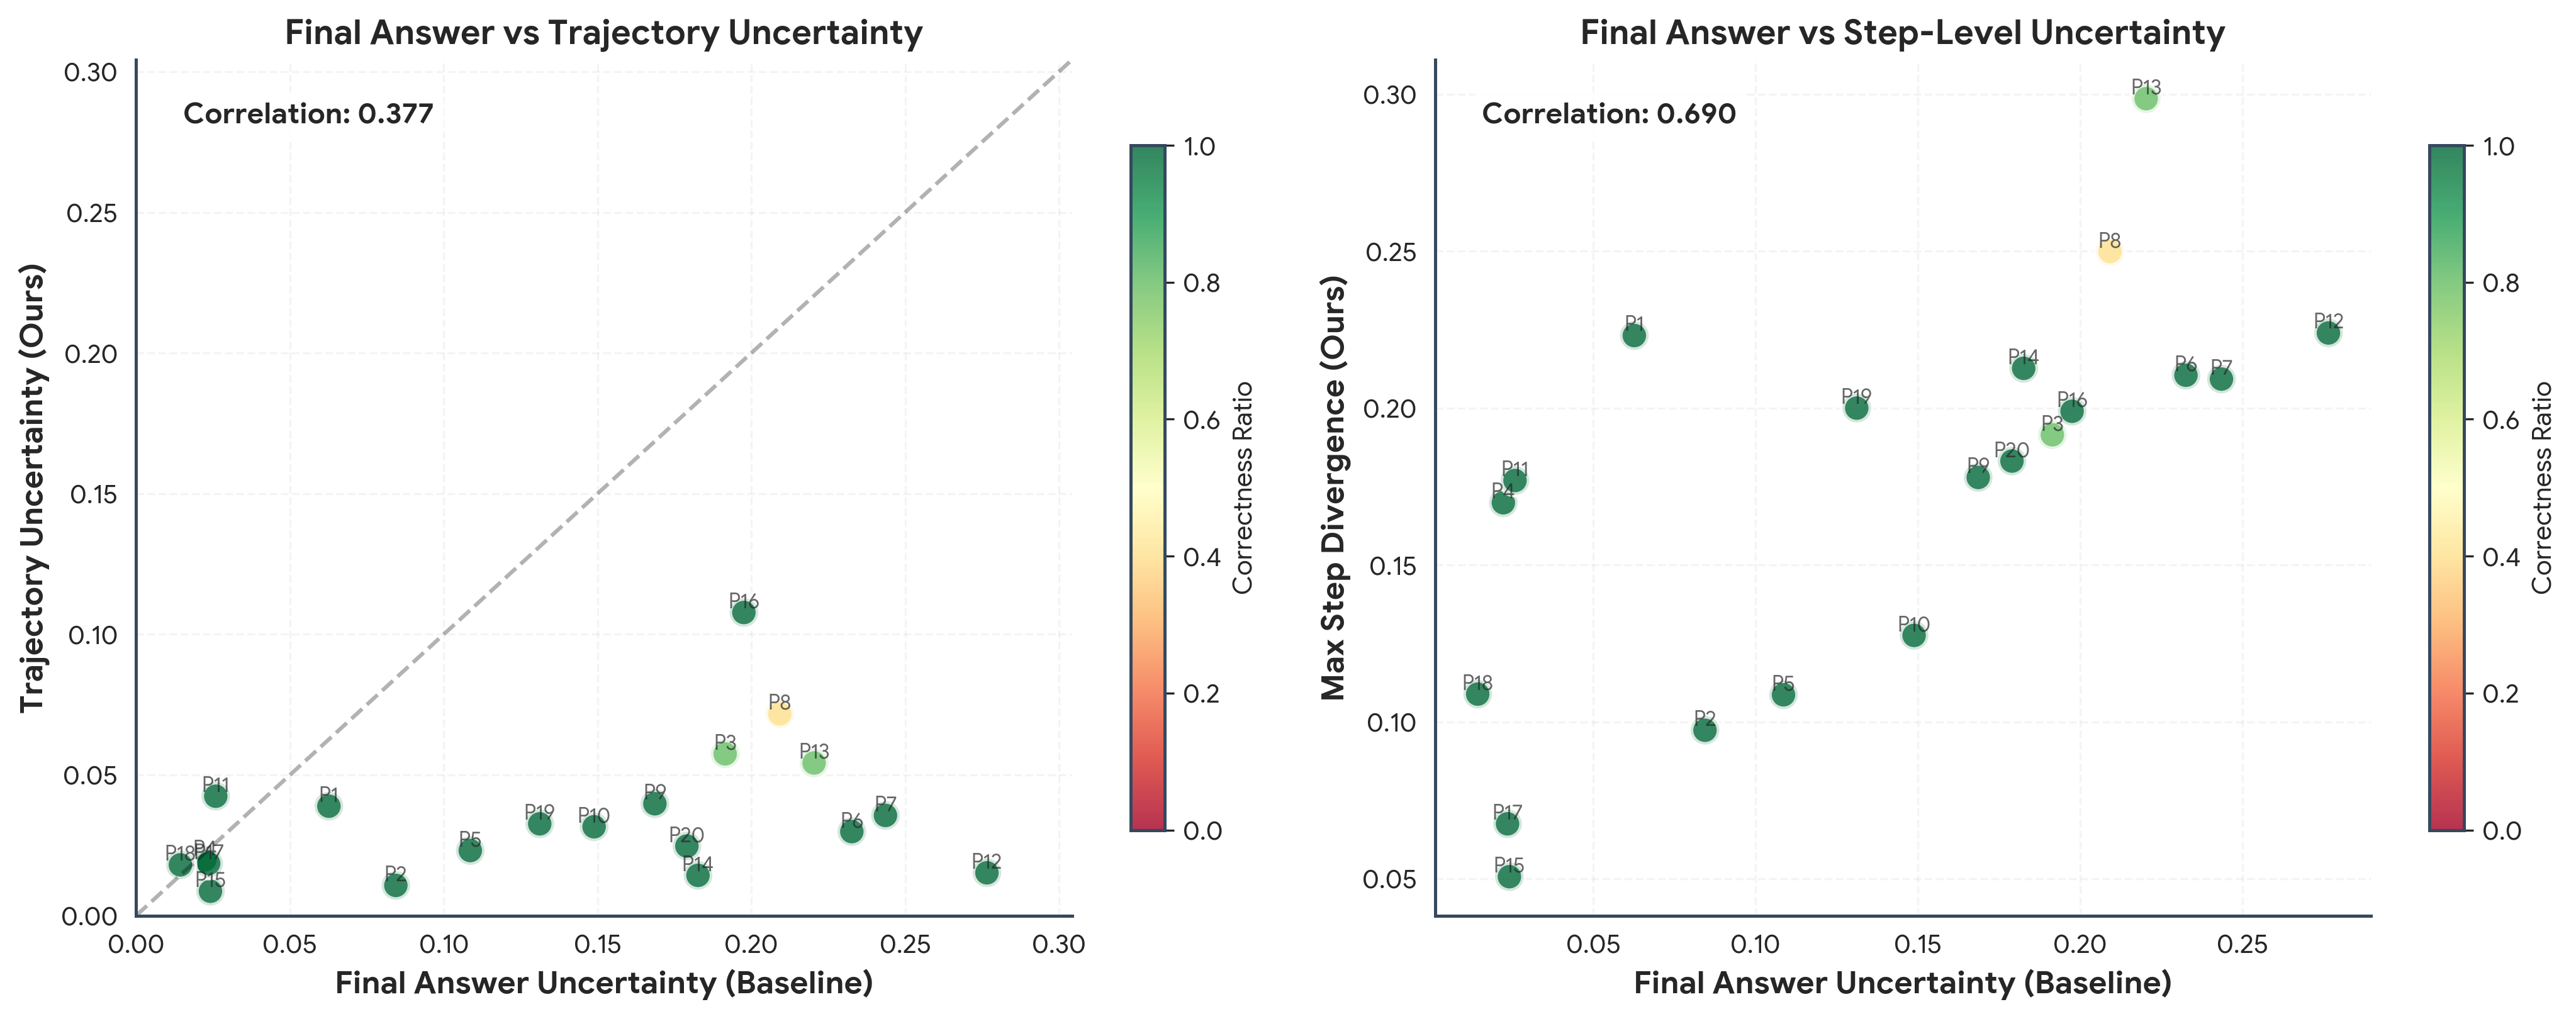

In [23]:
# =============================================================================
# BASELINE COMPARISON: Final Answer Entropy vs Trajectory/Step Uncertainty
# =============================================================================

def plot_baseline_comparison(all_results):
    """
    Compare traditional final-answer semantic entropy with our approach.
    
    Shows:
    1. Scatter: trajectory uncertainty vs final-answer uncertainty
    2. Highlights cases where they disagree (most interesting!)
    3. Correlation coefficient
    """
    # Collect metrics
    traj_uncertainties = []
    final_answer_uncertainties = []
    max_step_divergences = []
    correct_ratios = []
    problem_ids = []
    
    for result in all_results:
        emb = result.get('embedding_results')
        llm = result.get('llm_results')
        if emb is None:
            continue
        
        traj_uncertainties.append(emb.traj_mean_distance)
        final_answer_uncertainties.append(emb.final_answer_mean_distance)
        max_step_divergences.append(max(emb.step_mean_distances) if emb.step_mean_distances else 0)
        
        # Get correctness ratio from LLM results
        if llm:
            correct = sum(1 for e in llm.trajectory_evaluations.evaluations if e.reaches_correct_answer)
            total = len(llm.trajectory_evaluations.evaluations)
            correct_ratios.append(correct / total if total > 0 else 0)
        else:
            correct_ratios.append(0.5)  # Unknown
        
        problem_ids.append(result.get('dataset_idx', len(problem_ids)))
    
    if len(traj_uncertainties) < 2:
        print("Not enough data for comparison plot")
        return None
    
    # Create figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=300)
    
    # --- Plot 1: Trajectory vs Final Answer Uncertainty ---
    ax1 = axes[0]
    
    # Color by correctness ratio
    scatter = ax1.scatter(final_answer_uncertainties, traj_uncertainties, 
                         c=correct_ratios, cmap='RdYlGn', 
                         s=120, alpha=0.8, edgecolors='white', linewidth=2,
                         vmin=0, vmax=1)
    
    # Add problem labels
    for i, pid in enumerate(problem_ids):
        ax1.annotate(f'P{pid+1}', (final_answer_uncertainties[i], traj_uncertainties[i]),
                    fontsize=8, ha='center', va='bottom', alpha=0.7)
    
    # Diagonal line (y=x) for reference
    max_val = max(max(traj_uncertainties), max(final_answer_uncertainties)) * 1.1
    ax1.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='y=x')
    
    # Compute correlation
    if len(set(final_answer_uncertainties)) > 1 and len(set(traj_uncertainties)) > 1:
        corr = np.corrcoef(final_answer_uncertainties, traj_uncertainties)[0, 1]
        ax1.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax1.transAxes,
                fontsize=11, fontweight='bold', va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    ax1.set_xlabel('Final Answer Uncertainty (Baseline)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Trajectory Uncertainty (Ours)', fontsize=12, fontweight='bold')
    ax1.set_title('Final Answer vs Trajectory Uncertainty', fontsize=13, fontweight='bold')
    
    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax1, shrink=0.8)
    cbar.set_label('Correctness Ratio', fontsize=10)
    
    ax1.grid(True, alpha=0.2, linestyle='--')
    ax1.set_xlim(0, max_val)
    ax1.set_ylim(0, max_val)
    
    # --- Plot 2: Max Step Divergence vs Final Answer Uncertainty ---
    ax2 = axes[1]
    
    scatter2 = ax2.scatter(final_answer_uncertainties, max_step_divergences,
                          c=correct_ratios, cmap='RdYlGn',
                          s=120, alpha=0.8, edgecolors='white', linewidth=2,
                          vmin=0, vmax=1)
    
    for i, pid in enumerate(problem_ids):
        ax2.annotate(f'P{pid+1}', (final_answer_uncertainties[i], max_step_divergences[i]),
                    fontsize=8, ha='center', va='bottom', alpha=0.7)
    
    # Correlation
    if len(set(final_answer_uncertainties)) > 1 and len(set(max_step_divergences)) > 1:
        corr2 = np.corrcoef(final_answer_uncertainties, max_step_divergences)[0, 1]
        ax2.text(0.05, 0.95, f'Correlation: {corr2:.3f}', transform=ax2.transAxes,
                fontsize=11, fontweight='bold', va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    ax2.set_xlabel('Final Answer Uncertainty (Baseline)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Max Step Divergence (Ours)', fontsize=12, fontweight='bold')
    ax2.set_title('Final Answer vs Step-Level Uncertainty', fontsize=13, fontweight='bold')
    
    cbar2 = plt.colorbar(scatter2, ax=ax2, shrink=0.8)
    cbar2.set_label('Correctness Ratio', fontsize=10)
    
    ax2.grid(True, alpha=0.2, linestyle='--')
    
    plt.tight_layout()
    return fig


def print_baseline_comparison_table(all_results):
    """
    Print a table comparing baseline vs our approach.
    Highlights cases where they disagree.
    """
    print("\n" + "="*80)
    print("  BASELINE COMPARISON: Final Answer vs Trajectory/Step Uncertainty")
    print("="*80)
    print(f"{'Problem':<10} {'Final Ans':<12} {'Trajectory':<12} {'Max Step':<12} {'Correct':<10} {'Notes'}")
    print("-"*80)
    
    for result in all_results:
        emb = result.get('embedding_results')
        llm = result.get('llm_results')
        if emb is None:
            continue
        
        pid = result.get('dataset_idx', 0) + 1
        final_unc = emb.final_answer_mean_distance
        traj_unc = emb.traj_mean_distance
        max_step = max(emb.step_mean_distances) if emb.step_mean_distances else 0
        
        if llm:
            correct = sum(1 for e in llm.trajectory_evaluations.evaluations if e.reaches_correct_answer)
            total = len(llm.trajectory_evaluations.evaluations)
            correct_str = f"{correct}/{total}"
        else:
            correct_str = "N/A"
        
        # Determine if there's a notable disagreement
        notes = []
        if traj_unc > final_unc * 1.5:
            notes.append("Traj >> Final (diverse paths, same answer?)")
        if final_unc > traj_unc * 1.5:
            notes.append("Final >> Traj (similar paths, diff answers?)")
        if max_step > traj_unc * 1.3:
            notes.append(f"Step divergence at specific point")
        
        notes_str = "; ".join(notes) if notes else "—"
        
        print(f"P{pid:<9} {final_unc:<12.4f} {traj_unc:<12.4f} {max_step:<12.4f} {correct_str:<10} {notes_str}")
    
    print("="*80)
    print("")
    print("Interpretation Guide:")
    print("  • Final Ans: Traditional semantic entropy (just final answers)")
    print("  • Trajectory: Our approach (full reasoning path similarity)")
    print("  • Max Step: Highest divergence at any single DTW-aligned step")
    print("  • 'Traj >> Final': Trajectories differ but answers agree (robust?)")
    print("  • 'Final >> Traj': Trajectories similar but answers differ (fragile?)")
    print("")


# Run the comparison
print("\n" + "="*60)
print("  Baseline Comparison: Final Answer vs Our Approach")
print("="*60)

print_baseline_comparison_table(all_results)

fig = plot_baseline_comparison(all_results)
if fig:
    plt.show()


## 14c. Step-Level Divergence Location: The Actionable Signal

### What Final Answer Entropy Misses

Final answer semantic entropy tells you **IF** answers disagree, but not **WHERE** the reasoning diverged.

Two problems can have identical final answer uncertainty but:
- **Problem A**: Divergence at Step 1 (fundamental disagreement on problem setup)
- **Problem B**: Divergence at Step 5 (calculation error at the end)

These require **different interventions**:
- Early divergence → Re-examine problem understanding
- Late divergence → Check arithmetic/final calculation

This analysis shows the **location** of maximum divergence for each problem.


  Step-Level Divergence Location Analysis

  DIVERGENCE LOCATION ANALYSIS: What Final Answer Entropy Misses
Problem  Steps  Max Div    At Step  Position   Final?  Final Unc  Correct
-------------------------------------------------------------------------------------
P1       4      0.2231     3        late       no      0.0627     100%
P2       3      0.0973     2        middle     no      0.0844     100%
P3       3      0.1915     3        late       YES     0.1915     80%
P4       3      0.1698     1        early      no      0.0223     100%
P5       3      0.1086     3        late       YES     0.1086     100%
P6       4      0.2105     4        late       YES     0.2327     100%
P7       4      0.2092     4        late       YES     0.2436     100%
P8       3      0.2499     3        late       YES     0.2092     40%
P9       5      0.1779     3        middle     no      0.1686     100%
P10      5      0.1275     3        middle     no      0.1489     100%
P11      3      0.1769 

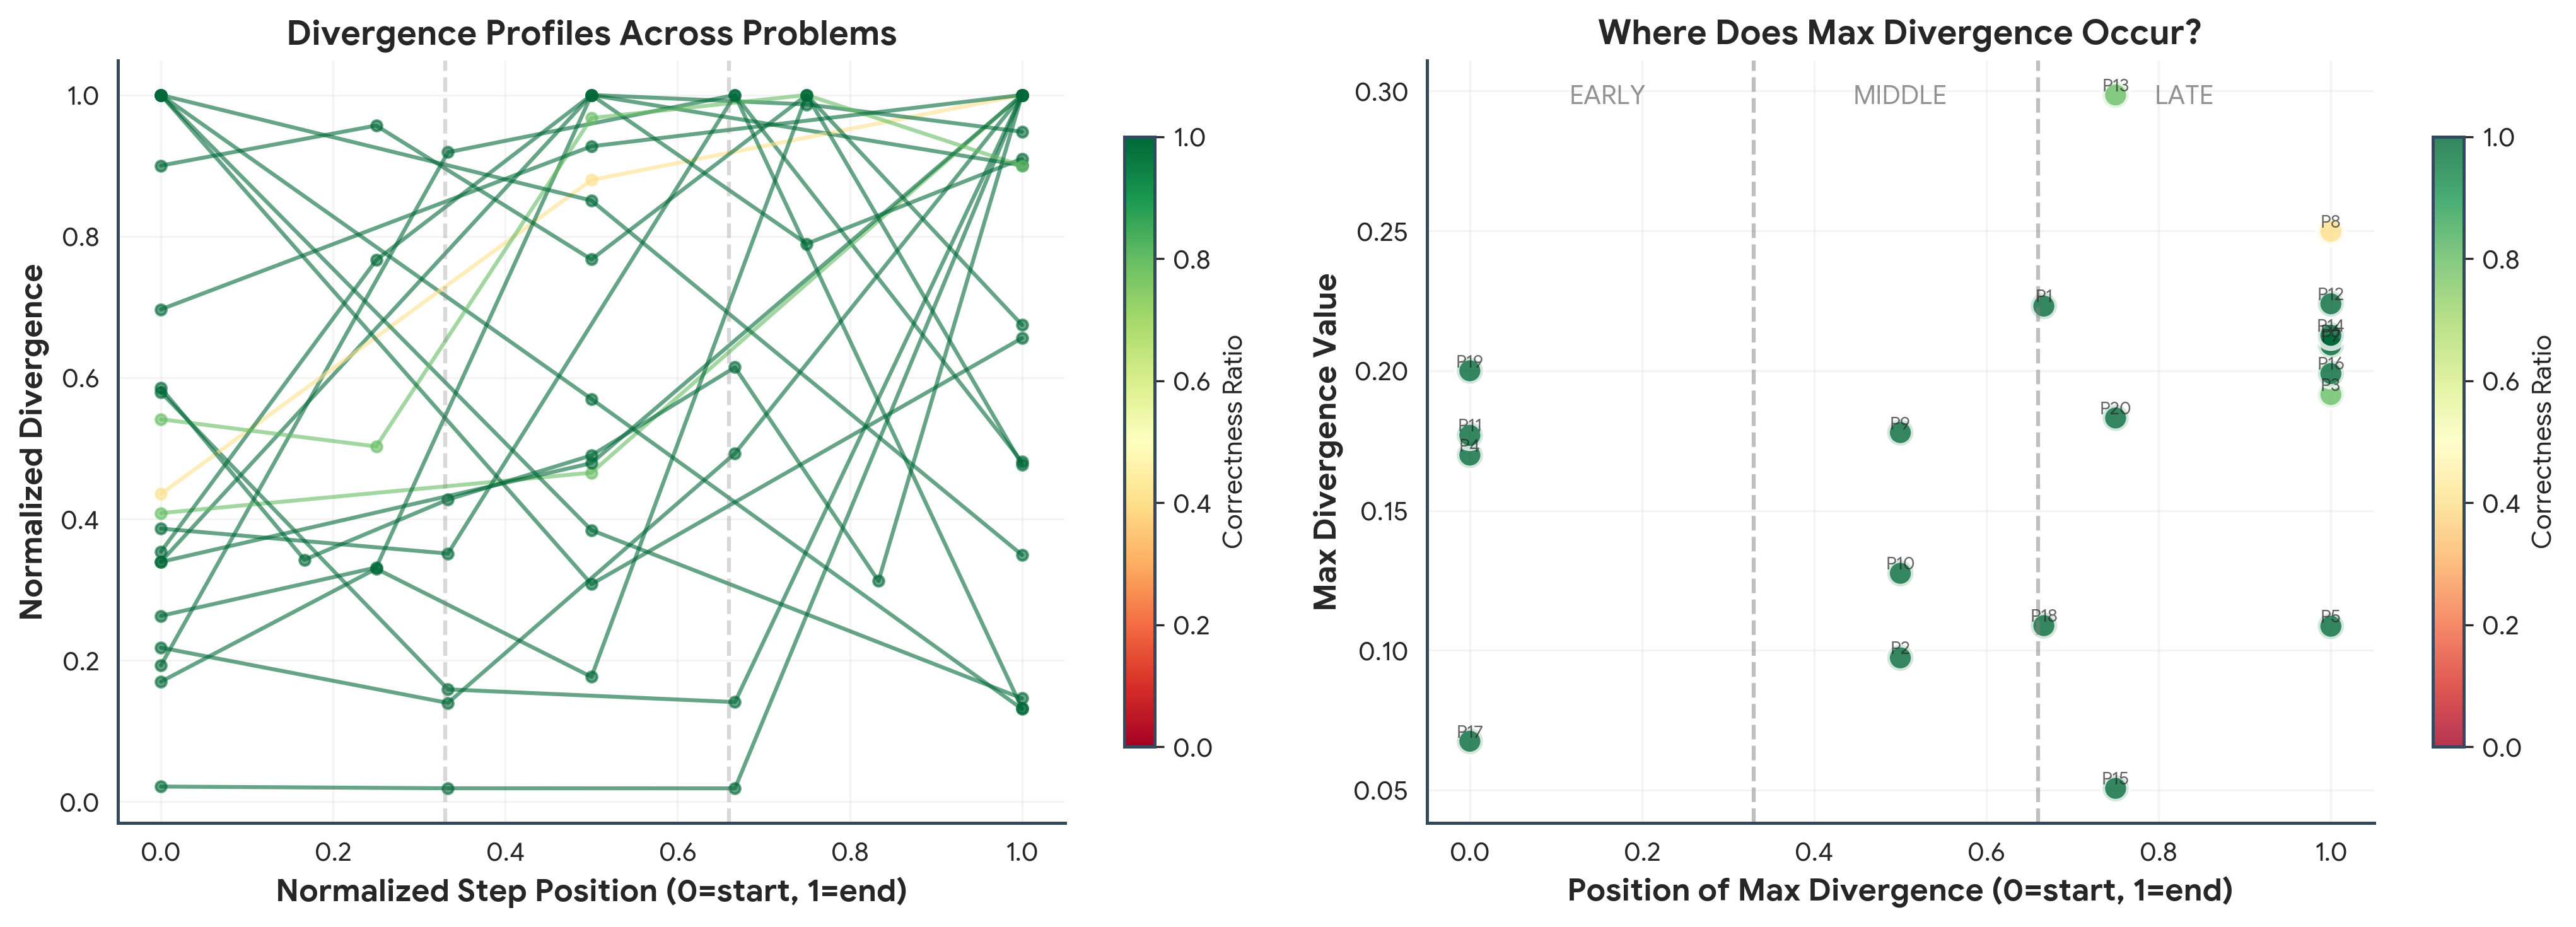

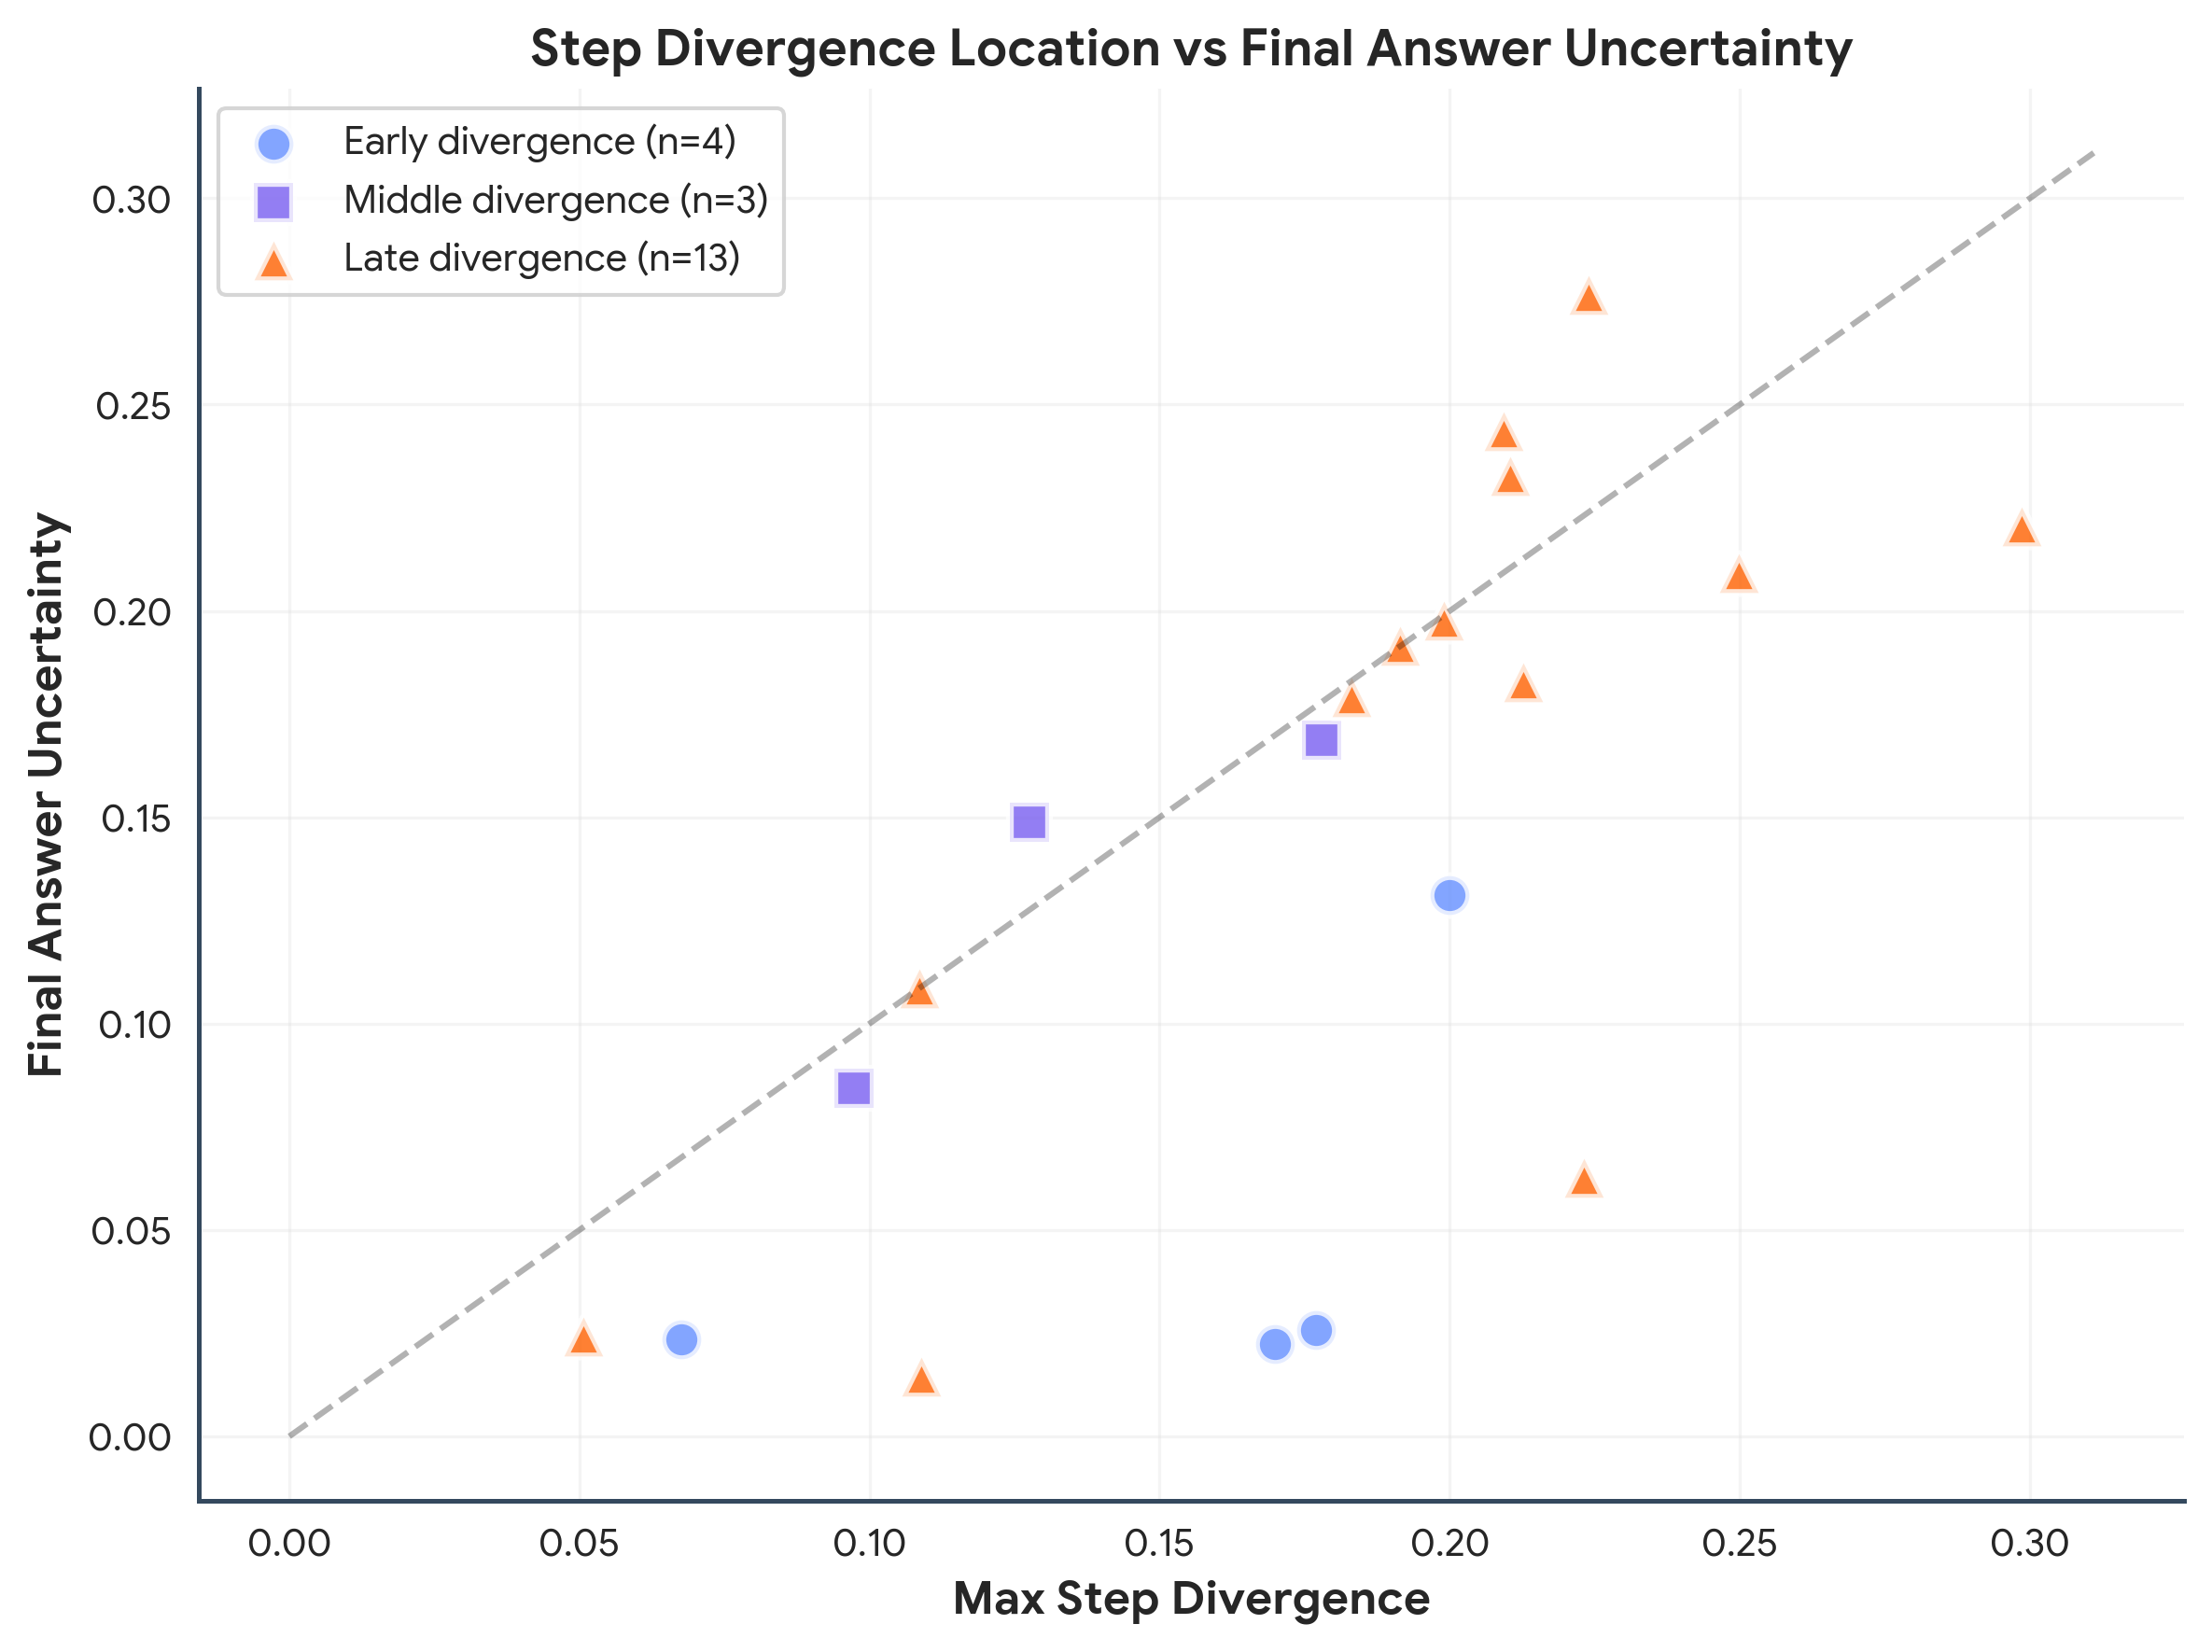

In [24]:
# =============================================================================
# STEP-LEVEL DIVERGENCE ANALYSIS: What Final Answer Entropy Misses
# =============================================================================

def analyze_divergence_location(all_results):
    """
    Analyze WHERE divergence occurs in each problem.
    
    Key insight: Two problems can have the SAME final answer uncertainty
    but diverge at DIFFERENT steps. This is actionable information that
    final-answer-only entropy misses.
    """
    analysis = []
    
    for result in all_results:
        emb = result.get('embedding_results')
        llm = result.get('llm_results')
        if emb is None:
            continue
        
        pid = result.get('dataset_idx', 0) + 1
        step_dists = emb.step_mean_distances
        num_steps = len(step_dists)
        
        if num_steps == 0:
            continue
        
        # Find max divergence location
        max_idx = np.argmax(step_dists)
        max_dist = step_dists[max_idx]
        
        # Categorize position: early (first 1/3), middle, late (last 1/3)
        position_ratio = max_idx / (num_steps - 1) if num_steps > 1 else 0.5
        if position_ratio <= 0.33:
            position_cat = 'early'
        elif position_ratio <= 0.66:
            position_cat = 'middle'
        else:
            position_cat = 'late'
        
        # Is max at the final step?
        is_final_step = (max_idx == num_steps - 1)
        
        # Get correctness
        if llm:
            correct = sum(1 for e in llm.trajectory_evaluations.evaluations if e.reaches_correct_answer)
            total = len(llm.trajectory_evaluations.evaluations)
            correct_ratio = correct / total if total > 0 else 0
        else:
            correct_ratio = None
        
        # Compute divergence profile (normalized)
        if max_dist > 0:
            normalized_profile = [d / max_dist for d in step_dists]
        else:
            normalized_profile = step_dists
        
        analysis.append({
            'problem_id': pid,
            'num_steps': num_steps,
            'max_div_step': max_idx + 1,  # 1-indexed
            'max_div_value': max_dist,
            'position_ratio': position_ratio,
            'position_cat': position_cat,
            'is_final_step': is_final_step,
            'final_answer_unc': emb.final_answer_mean_distance,
            'correct_ratio': correct_ratio,
            'step_profile': step_dists,
            'normalized_profile': normalized_profile,
        })
    
    return analysis


def print_divergence_location_analysis(analysis):
    """
    Print analysis showing WHERE divergence occurs.
    """
    print("\n" + "="*85)
    print("  DIVERGENCE LOCATION ANALYSIS: What Final Answer Entropy Misses")
    print("="*85)
    print(f"{'Problem':<8} {'Steps':<6} {'Max Div':<10} {'At Step':<8} {'Position':<10} {'Final?':<7} {'Final Unc':<10} {'Correct'}")
    print("-"*85)
    
    for a in analysis:
        correct_str = f"{a['correct_ratio']*100:.0f}%" if a['correct_ratio'] is not None else 'N/A'
        final_str = 'YES' if a['is_final_step'] else 'no'
        
        print(f"P{a['problem_id']:<7} {a['num_steps']:<6} {a['max_div_value']:<10.4f} {a['max_div_step']:<8} {a['position_cat']:<10} {final_str:<7} {a['final_answer_unc']:<10.4f} {correct_str}")
    
    # Summary statistics
    early = sum(1 for a in analysis if a['position_cat'] == 'early')
    middle = sum(1 for a in analysis if a['position_cat'] == 'middle')
    late = sum(1 for a in analysis if a['position_cat'] == 'late')
    at_final = sum(1 for a in analysis if a['is_final_step'])
    
    print("-"*85)
    print(f"\nDivergence Location Distribution:")
    print(f"  Early (first 1/3):  {early} problems ({early/len(analysis)*100:.0f}%)")
    print(f"  Middle (mid 1/3):   {middle} problems ({middle/len(analysis)*100:.0f}%)")
    print(f"  Late (last 1/3):    {late} problems ({late/len(analysis)*100:.0f}%)")
    print(f"  At Final Step:      {at_final} problems ({at_final/len(analysis)*100:.0f}%)")
    
    # Key insight: same final uncertainty, different divergence location
    print(f"\n" + "="*85)
    print("  KEY INSIGHT: Same Final Answer Uncertainty, Different Divergence Location")
    print("="*85)
    
    # Sort by final answer uncertainty and find pairs with similar final unc but different locations
    sorted_analysis = sorted(analysis, key=lambda x: x['final_answer_unc'])
    
    # Find interesting pairs
    for i in range(len(sorted_analysis)):
        for j in range(i+1, min(i+3, len(sorted_analysis))):  # Compare nearby items
            a1, a2 = sorted_analysis[i], sorted_analysis[j]
            final_diff = abs(a1['final_answer_unc'] - a2['final_answer_unc'])
            
            # Similar final uncertainty but different location
            if final_diff < 0.03 and a1['position_cat'] != a2['position_cat']:
                print(f"\n  P{a1['problem_id']} vs P{a2['problem_id']}:")
                print(f"    Final Answer Uncertainty: {a1['final_answer_unc']:.3f} vs {a2['final_answer_unc']:.3f} (similar!)")
                print(f"    Max Divergence Location:  Step {a1['max_div_step']} ({a1['position_cat']}) vs Step {a2['max_div_step']} ({a2['position_cat']})")
                print(f"    → Same uncertainty, but divergence at DIFFERENT reasoning stages!")
                print(f"    → This is actionable info that final-answer entropy misses.")
    
    print("\n" + "="*85 + "\n")


def plot_divergence_profiles(analysis):
    """
    Visualize step-by-step divergence profiles.
    Shows WHERE in the reasoning process uncertainty emerges.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=300)
    
    # --- Left: Divergence profiles for all problems ---
    ax1 = axes[0]
    
    # Normalize step positions to [0, 1] for comparison
    for a in analysis:
        num_steps = a['num_steps']
        x = np.linspace(0, 1, num_steps)  # Normalized position
        y = a['normalized_profile']
        
        # Color by correctness
        if a['correct_ratio'] is not None:
            color = plt.cm.RdYlGn(a['correct_ratio'])
        else:
            color = 'gray'
        
        ax1.plot(x, y, '-o', alpha=0.6, markersize=4, color=color, linewidth=1.5)
    
    ax1.set_xlabel('Normalized Step Position (0=start, 1=end)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Normalized Divergence', fontsize=12, fontweight='bold')
    ax1.set_title('Divergence Profiles Across Problems', fontsize=13, fontweight='bold')
    ax1.axvline(x=0.33, color='gray', linestyle='--', alpha=0.3, label='Early/Middle')
    ax1.axvline(x=0.66, color='gray', linestyle='--', alpha=0.3, label='Middle/Late')
    ax1.grid(True, alpha=0.2)
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0, 1))
    cbar = plt.colorbar(sm, ax=ax1, shrink=0.8)
    cbar.set_label('Correctness Ratio', fontsize=10)
    
    # --- Right: Where does max divergence occur? ---
    ax2 = axes[1]
    
    positions = [a['position_ratio'] for a in analysis]
    max_divs = [a['max_div_value'] for a in analysis]
    correct_ratios = [a['correct_ratio'] if a['correct_ratio'] is not None else 0.5 for a in analysis]
    
    scatter = ax2.scatter(positions, max_divs, c=correct_ratios, cmap='RdYlGn',
                         s=100, alpha=0.8, edgecolors='white', linewidth=2,
                         vmin=0, vmax=1)
    
    # Add problem labels
    for a in analysis:
        ax2.annotate(f"P{a['problem_id']}", (a['position_ratio'], a['max_div_value']),
                    fontsize=7, alpha=0.7, ha='center', va='bottom')
    
    ax2.axvline(x=0.33, color='gray', linestyle='--', alpha=0.5)
    ax2.axvline(x=0.66, color='gray', linestyle='--', alpha=0.5)
    ax2.text(0.16, ax2.get_ylim()[1]*0.95, 'EARLY', ha='center', fontsize=10, alpha=0.5)
    ax2.text(0.5, ax2.get_ylim()[1]*0.95, 'MIDDLE', ha='center', fontsize=10, alpha=0.5)
    ax2.text(0.83, ax2.get_ylim()[1]*0.95, 'LATE', ha='center', fontsize=10, alpha=0.5)
    
    ax2.set_xlabel('Position of Max Divergence (0=start, 1=end)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Max Divergence Value', fontsize=12, fontweight='bold')
    ax2.set_title('Where Does Max Divergence Occur?', fontsize=13, fontweight='bold')
    ax2.set_xlim(-0.05, 1.05)
    ax2.grid(True, alpha=0.2)
    
    cbar2 = plt.colorbar(scatter, ax=ax2, shrink=0.8)
    cbar2.set_label('Correctness Ratio', fontsize=10)
    
    plt.tight_layout()
    return fig


def plot_step_vs_final_correlation(analysis):
    """
    Compare: Does divergence at different positions correlate differently with final answer uncertainty?
    """
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    
    early = [a for a in analysis if a['position_cat'] == 'early']
    middle = [a for a in analysis if a['position_cat'] == 'middle']
    late = [a for a in analysis if a['position_cat'] == 'late']
    
    # Plot each category
    for data, label, color, marker in [
        (early, 'Early divergence', COLORS['blue'], 'o'),
        (middle, 'Middle divergence', COLORS['purple'], 's'),
        (late, 'Late divergence', COLORS['orange'], '^')
    ]:
        if data:
            x = [a['max_div_value'] for a in data]
            y = [a['final_answer_unc'] for a in data]
            ax.scatter(x, y, label=f'{label} (n={len(data)})', 
                      color=color, marker=marker, s=100, alpha=0.8,
                      edgecolors='white', linewidth=2)
    
    ax.set_xlabel('Max Step Divergence', fontsize=12, fontweight='bold')
    ax.set_ylabel('Final Answer Uncertainty', fontsize=12, fontweight='bold')
    ax.set_title('Step Divergence Location vs Final Answer Uncertainty', fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.2)
    
    # Add diagonal
    max_val = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3)
    
    plt.tight_layout()
    return fig


# Run the analysis
print("\n" + "="*60)
print("  Step-Level Divergence Location Analysis")
print("="*60)

divergence_analysis = analyze_divergence_location(all_results)
print_divergence_location_analysis(divergence_analysis)

fig1 = plot_divergence_profiles(divergence_analysis)
plt.show()

fig2 = plot_step_vs_final_correlation(divergence_analysis)
plt.show()


#### Interpretation of Step-Level Divergence Analysis

### Key Finding #1: Late Divergence Dominates

| Location | Count | Percentage |
|----------|-------|------------|
| Early (first 1/3) | 4 | 20% |
| Middle (mid 1/3) | 3 | 15% |
| Late (last 1/3) | 13 | **65%** |
| At Final Step | 8 | 40% |

**Interpretation**: In GSM8K, uncertainty primarily manifests in the **final steps** of reasoning, not the problem setup. The model tends to agree
on approach but diverge on execution/calculation.

---

### Key Finding #2: Early Divergence is "Hidden" from Final Answer Entropy

| Divergence Location | Pattern in Plot | Meaning |
|---------------------|-----------------|---------|
| **Early** (blue circles) | BELOW diagonal | High step divergence, LOW final uncertainty |
| **Late** (orange triangles) | ON/ABOVE diagonal | Step divergence correlates with final uncertainty |

Problems with early divergence (P4, P11, P17, P19):
- High step divergence at step 1
- But LOW final answer uncertainty (~0.02)
- All 100% correct

**Insight**: The model takes **different reasoning approaches** at the start, but **converges to the same answer**. Final answer entropy would
completely MISS this divergence.

---

### Key Finding #3: Same Final Uncertainty ≠ Same Problem

P4 vs P15:
  Final Answer Uncertainty: 0.022 vs 0.024 (nearly identical!)
  Max Divergence Location:  Step 1 (early) vs Step 4 (late)

If you only looked at final answer entropy, these look identical. But:
- **P4**: Trajectories disagree on how to START, then converge → **robust**
- **P15**: Trajectories agree until the END, then diverge → **fragile**

---

### Key Finding #4: Late Divergence Predicts Errors

P8 stands out as the warning case:
- **40% correct** (lowest in dataset)
- **Late divergence** (step 3 of 3)
- **High magnitude** (0.25)
- Max divergence occurs at the final step

**Pattern**: High late-stage divergence + final step = likely incorrect answers.

---

### Summary for Paper

> Final answer semantic entropy tells you the *magnitude* of uncertainty, but step-level analysis reveals the *location*. We find that 65% of
divergence occurs in late steps, but critically, problems with early divergence show high step-level uncertainty while having low final answer
uncertainty—a signal that traditional methods completely miss. This location information is actionable: early divergence suggests robust multi-path
  reasoning, while late divergence (especially at the final step) predicts errors.

#### Interpretation of Baseline Comparison Results (n=20)

## Key Finding: "Final >> Traj" Dominance

**15 out of 20 problems** show `Final Answer Uncertainty > Trajectory Uncertainty`

This reveals something important: **The LLM follows similar reasoning paths but diverges at the final answer.**

---

## Interpreting the Correlations

| Metric Comparison | Correlation | Interpretation |
|-------------------|-------------|----------------|
| Trajectory vs Final Answer | 0.377 (weak) | Trajectory-level analysis provides **different** signal than final answer uncertainty |
| Max Step vs Final Answer | 0.690 (moderate) | Step-level analysis captures more of what final answer uncertainty measures |

---

## Pattern Analysis

### Pattern 1: "Final >> Traj" (15/20 problems)

**Example — P12:**
Final Ans: 0.277 | Trajectory: 0.015 | Max Step: 0.224

- Trajectories are nearly identical
- But final answers diverge significantly
- **Interpretation**: The model reasons consistently but makes different numerical conclusions
- **Implication**: This is a *fragile* pattern — uncertainty is hidden until the very end

### Pattern 2: "Traj >> Final" (1/20 problems)

**Example — P11:**
Final Ans: 0.026 | Trajectory: 0.042 | Max Step: 0.177

- Different reasoning paths converge to the same answer
- **Interpretation**: Multiple valid solution approaches exist
- **Implication**: This is a *robust* pattern — the answer is reliable even though reasoning paths differ

### Pattern 3: High Uncertainty + Low Correctness

**Example — P8:**
Final Ans: 0.209 | Trajectory: 0.072 | Max Step: 0.250 | Correct: 2/5

- High uncertainty across all metrics
- Lowest correctness in the dataset
- **Interpretation**: Uncertainty metrics correctly predict unreliable outputs

---

## Visual Interpretation

### Left Panel (Trajectory vs Final Answer, r=0.377)

- Most points fall **below** the diagonal (y=x line)
- Meaning: Trajectories are more similar than final answers
- **Implication**: Traditional semantic entropy on full trajectories would **underestimate** true uncertainty

### Right Panel (Max Step vs Final Answer, r=0.690)

- Points cluster closer to the diagonal
- Meaning: Max step divergence aligns better with final answer disagreement
- **Implication**: Step-level analysis is a **better predictor** of output uncertainty than trajectory-level analysis

---

## Conclusions for Paper

1. **Trajectory-level analysis alone is insufficient** — it misses uncertainty that concentrates at the final step

2. **Step-level analysis provides complementary signal** — max divergence captures where reasoning actually diverges

3. **The weak correlation (0.377) validates our approach** — trajectory/step analysis provides information that final-answer-only semantic entropy
misses

4. **Uncertainty in GSM8K localizes to answer formulation** — the reasoning process is consistent, but converting reasoning to a final numerical
answer introduces divergence

---

## Summary Table

| Insight | Evidence | Implication |
|---------|----------|-------------|
| Trajectories more similar than answers | 15/20 "Final >> Traj" | Trajectory-level metrics underestimate uncertainty |
| Step divergence predicts answer divergence | r=0.690 vs r=0.377 | Step-level analysis more informative |
| High uncertainty → low correctness | P8: 2/5 correct, highest Max Step | Metrics have predictive validity |
| Multiple valid paths possible | P11: "Traj >> Final" | Diverse reasoning can still be reliable |

## 15. Key Findings & Interpretation

### Understanding the Two Pipelines

**Pipeline 1 (Embedding-Based)** captures **semantic surface similarity**:
- High trajectory distance → Different wording, different intermediate calculations
- High step entropy → Multiple distinct approaches at that reasoning stage
- Fast and deterministic, but may miss logical equivalence

**Pipeline 2 (LLM-Based)** captures **logical and correctness properties**:
- High divergence → LLM sees fundamentally different reasoning strategies
- Low quality scores → Logical errors, inconsistencies, or wrong answers
- Slower but more semantically aware

### Pipeline Agreement vs. Disagreement

| Scenario | Embedding | LLM | Interpretation |
|----------|-----------|-----|----------------|
| **Both Low** | Low distance | Low divergence | High confidence, consistent reasoning |
| **Both High** | High distance | High divergence | True uncertainty, model exploring alternatives |
| **Emb High, LLM Low** | High distance | Low divergence | Surface differences, logically equivalent |
| **Emb Low, LLM High** | Low distance | High divergence | Similar wording hides logical differences |

### What to Look For

1. **Correct answers with high uncertainty**: Model got lucky—consider these unreliable
2. **Wrong answers with low uncertainty**: Confident errors—most dangerous for deployment
3. **Step-level spikes**: Specific reasoning choices that cause divergence
4. **Quality variance > 0**: LLM found meaningful differences between trajectories

## 16. Export Results

Save results for downstream analysis or paper figures:
- **JSON**: Complete results including trajectories, both pipeline outputs, and all metrics
- **CSV**: Summary table for quick comparison across problems

The exported data preserves:
- Original questions and ground truth answers
- All K trajectories (text)
- Embedding pipeline: distances, entropies, aligned step groups
- LLM pipeline: alignments, divergences, quality evaluations

In [18]:
# Export results to JSON for further analysis
import json

def export_results(all_results, filename='uncertainty_results.json'):
    """
    Export results from both pipelines in JSON format.
    """
    export_data = []
    
    for idx, result in enumerate(all_results):
        emb = result.get('embedding_results')
        llm = result.get('llm_results')
        
        if emb is None or llm is None:
            continue
        
        problem_data = {
            'problem_id': result.get('dataset_idx', idx),
            'question': result['question'],
            'ground_truth': result.get('ground_truth', ''),  # Include correct answer
            'num_trajectories': len(result['trajectories']),
            'trajectories': result['trajectories'],
            
            # Pipeline 1: Embedding-based results
            'embedding_pipeline': {
                'trajectory_level': {
                    'mean_distance': emb.traj_mean_distance,
                    'std_distance': emb.traj_std_distance,
                    'max_distance': emb.traj_max_distance,
                    'final_answer_mean_distance': emb.final_answer_mean_distance,
                    'final_answer_std_distance': emb.final_answer_std_distance,
                    'final_answer_max_distance': emb.final_answer_max_distance,
                },
                'step_level': {
                    'num_aligned_steps': emb.num_aligned_steps,
                    'entropies': emb.step_mean_distances,
                    'dispersions': emb.step_dispersions,
                    'step_max_distances': emb.step_max_distances,
                    'avg_entropy': float(np.mean(emb.step_mean_distances)),
                    'max_entropy': float(np.max(emb.step_mean_distances)),
                }
            },
            
            # Pipeline 2: LLM-based results
            'llm_pipeline': {
                'alignment': {
                    'num_stages': llm.alignment.num_stages_identified,
                    'overall_quality': llm.alignment.overall_alignment_quality,
                    'summary': llm.alignment.summary,
                    'stages': [
                        {
                            'name': s.stage_name,
                            'description': s.stage_description,
                            'trajectory_ids': s.trajectory_ids_present
                        }
                        for s in llm.alignment.stages
                    ],
                    'divergence_assessments': [
                        {
                            'stage': d.stage_name,
                            'score': d.divergence_score,
                            'explanation': d.divergence_explanation,
                            'is_critical': d.is_critical_divergence
                        }
                        for d in llm.alignment.divergence_assessments
                    ]
                },
                'divergence_metrics': {
                    'avg_divergence': llm.avg_divergence,
                    'max_divergence': llm.max_divergence,
                    'num_critical': llm.num_critical_divergences,
                },
                'trajectory_evaluations': {
                    'best_trajectory_id': llm.best_trajectory_id,
                    'worst_trajectory_id': llm.worst_trajectory_id,
                    'avg_quality': llm.avg_quality,
                    'quality_variance': llm.quality_variance,
                    'confidence_in_best': llm.trajectory_evaluations.confidence_in_best,
                    'agreement_summary': llm.trajectory_evaluations.agreement_summary,
                    'evaluations': [
                        {
                            'trajectory_id': e.trajectory_id,
                            'overall_quality': e.overall_quality,
                            'reaches_correct_answer': e.reaches_correct_answer,
                            'critical_issues': e.critical_issues,
                            'step_scores': [
                                {
                                    'step': s.step_number,
                                    'validity': s.validity,
                                    'consistency': s.consistency,
                                    'alignment': s.alignment,
                                    'progress': s.progress
                                }
                                for s in e.step_scores
                            ]
                        }
                        for e in llm.trajectory_evaluations.evaluations
                    ]
                }
            }
        }
        
        export_data.append(problem_data)
    
    with open(filename, 'w') as f:
        json.dump(export_data, f, indent=2)
    
    print(f"Results exported to {filename}")
    return export_data

# Export
exported = export_results(all_results)

# Also save summary dataframe
summary_df.to_csv('uncertainty_summary.csv', index=False)
print("Summary exported to uncertainty_summary.csv")

# Print sample of exported data structure
if len(exported) > 0:
    print("\nSample export structure (Problem 1):")
    print(json.dumps({k: v for k, v in exported[0].items() if k != 'trajectories'}, indent=2) + "...")

Results exported to uncertainty_results.json
Summary exported to uncertainty_summary.csv

Sample export structure (Problem 1):
{
  "problem_id": 0,
  "question": "Janet\u2019s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?",
  "ground_truth": "Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.\nShe makes 9 * 2 = $<<9*2=18>>18 every day at the farmer\u2019s market.\n#### 18",
  "num_trajectories": 5,
  "embedding_pipeline": {
    "trajectory_level": {
      "mean_distance": 0.03889099508523941,
      "std_distance": 0.028172126039862633,
      "max_distance": 0.08295810222625732,
      "final_answer_mean_distance": 0.06265243142843246,
      "final_answer_std_distance": 0.0550801083445549,
      "final_answer_max_distance": 0.16987282037734985
    },
    "step

## 17. Conclusion & Contribution

### Summary: Trajectory-Level Uncertainty Quantification

This notebook introduces a **trajectory-level uncertainty quantification framework** that extends final-outcome semantic entropy to multi-step reasoning:

**Key Contributions**:
1. **Two-dimensional analysis**: Trajectory vs. Step granularity × Embedding vs. LLM method
2. **DTW alignment**: Meaningful step-level comparison across variable-length trajectories
3. **Dual-pipeline architecture**: Independent semantic and metacognitive uncertainty signals
4. **Ground-truth integration**: LLM evaluation informed by correct answers

### Relationship to Final-Outcome Semantic Entropy

This work **complements** final-outcome SE by providing:
- **Temporal resolution**: See *where* in reasoning uncertainty arises
- **Process visibility**: Understand *why* the model is uncertain
- **Error localization**: Identify *which step* caused a wrong answer
- **Richer signals**: Quality, validity, and consistency beyond semantic clustering

### Limitations & Future Work

**Current Limitations**:
- LLM-based pipeline is slow and costly (requires GPT-4o calls)
- Easy problems (GSM8K) may not show meaningful uncertainty
- Ground truth required for LLM quality assessment

**Future Directions**:
- Test on harder datasets (MATH, competition problems)
- Correlate trajectory uncertainty with final-outcome SE
- Use uncertainty signals for selective verification or retry
- Train lightweight models to approximate LLM-based pipeline